# 🎙️ Deepfake Audio Detection Pipeline

A deep learning pipeline for detecting AI-generated/synthetic audio using multiple model architectures.

## 📋 Overview

| Feature      | Description                                      |
| ------------ | ------------------------------------------------ |
| **Datasets** | ASVspoof2019, Fake-or-Real, SceneFake            |
| **Task**     | Binary classification (Real vs Fake audio)       |
| **Features** | Raw waveform, Mel-spectrogram, LFCC, MFCC, CQT   |
| **Models**   | EfficientNet-B2, SEResNet, LCNN, RawNet3, AASIST |
| **Metrics**  | EER (Equal Error Rate), Accuracy, t-DCF          |


## 🔧 Step 1: Setup Environment

Clone the repository and navigate to the project directory.


In [2]:
# %cd /content
# !git clone  https://github.com/gkibria121/ai-pipeline.git
# %cd ai-pipeline
!git pull

Already up to date.


## 📦 Step 2: Install Dependencies

Install all required Python packages.


In [3]:
# !pip install -r requirements.txt

## 📖 Available Options

### Models (`--config`)

| Config File                            | Model                       | Parameters | Input Type   |
| -------------------------------------- | --------------------------- | ---------- | ------------ |
| `config/LCNN.conf`                     | LCNN                        | ~0.5M      | Spectrogram  |
| `config/LCNN_Large.conf`               | LCNN Large                  | ~1M        | Spectrogram  |
| `config/SEResNet.conf`                 | SEResNet                    | ~12M       | Spectrogram  |
| `config/EfficientNetB2.conf`           | EfficientNet-B2             | ~9M        | Spectrogram  |
| `config/EfficientNetB2_Attention.conf` | EfficientNet-B2 + Attention | ~9M        | Spectrogram  |
| `config/RawNet3.conf`                  | RawNet3                     | ~2M        | Raw waveform |
| `config/AASIST.conf`                   | AASIST                      | ~0.3M      | Raw waveform |
| `config/AASIST-L.conf`                 | AASIST-L                    | ~0.6M      | Raw waveform |

### Datasets (`--dataset`)

| Flag | Dataset      | Description                                     |
| ---- | ------------ | ----------------------------------------------- |
| `1`  | ASVspoof2019 | Standard benchmark for audio spoofing detection |
| `2`  | Fake-or-Real | Binary classification for fake vs real audio    |
| `3`  | SceneFake    | Scene-aware fake audio detection                |

### Feature Types (`--feature_type`)

| Flag | Feature         | Description                                      |
| ---- | --------------- | ------------------------------------------------ |
| `0`  | Raw waveform    | Direct waveform processing (for RawNet3, AASIST) |
| `1`  | Mel-spectrogram | 128 mel bins                                     |
| `2`  | LFCC            | Linear Frequency Cepstral Coefficients           |
| `3`  | MFCC            | Mel-Frequency Cepstral Coefficients              |
| `4`  | CQT             | Constant-Q Transform                             |

### Command Line Arguments

```bash
python main.py \
    --config <config_file>      # Model configuration file
    --dataset <1|2|3>           # Dataset to use
    --feature_type <0-4>        # Audio feature representation
    --epochs <num>              # Number of training epochs
    --batch_size <num>          # Batch size (overrides config)
    --random_noise              # Enable data augmentation
    --weight_avg                # Enable Stochastic Weight Averaging (SWA)
    --eval_best                 # Evaluate on test set when best model is found
    --eval                      # Evaluation mode only
    --eval_model_weights <path> # Path to model weights for evaluation
    --data_subset <0.0-1.0>     # Use subset of data (for quick testing)
```

### Training Flags

| Flag             | Description                                                  |
| ---------------- | ------------------------------------------------------------ |
| `--random_noise` | Enable data augmentation (RIR, MUSAN, pitch shift, etc.)     |
| `--weight_avg`   | Enable Stochastic Weight Averaging for better generalization |
| `--eval_best`    | Evaluate on test set each time a new best model is found     |

### Augmentation Types (`--random_noise`)

When enabled, applies these augmentations randomly:

| Augmentation      | Description                                      |
| ----------------- | ------------------------------------------------ |
| RIR Simulation    | Room Impulse Response - simulates room acoustics |
| MUSAN-style Noise | Babble, music, and ambient noise                 |
| Gaussian Noise    | Additive white Gaussian noise (SNR: 10-25 dB)    |
| Reverberation     | Echo/reverb effects                              |
| Pitch Shift       | ±4 semitones                                     |
| Time Stretch      | 0.85x - 1.15x speed                              |
| Gain              | ±6 dB volume adjustment                          |
| Filters           | Low-pass and high-pass filtering                 |
| SpecAugment       | Frequency and time masking for spectrograms      |


## 📥 Step 3: Download Fake-or-Real Dataset

Download the Fake-or-Real dataset (2-second audio clips). This contains:

- **Training**: 13,956 samples (6,978 real + 6,978 fake)
- **Validation**: 2,826 samples (1,413 real + 1,413 fake)
- **Testing**: 1,088 samples (544 real + 544 fake)


In [4]:
# !python download_dataset.py --dataset 2

---

## 🚀 Step 4: Train Models

### LCNN



DATASET: Fake-or-Real (Type 2)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: 1 (MEL_SPECTROGRAM)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
CuDNN Benchmark: Enabled
no. model params:444835
Memory Format: channels_last (optimized for CNNs)

TRAINING CONFIGURATION SUMMARY
  Model:            LCNN
  Dataset:          Fake-or-Real (Type 2)
  Feature:          mel_spectrogram (Type 1)
  Augmentation:     ✅ ENABLED
  Weight Avg (SWA): ✅ ENABLED
  Epochs:           20
  Batch Size:       32


Dataset loaded from: fake_or_real\for-2sec\for-2seconds
Training s

Training: 100%|█████████████| 436/436 [05:17<00:00,  1.37batch/s, loss=0.26125]



Validating on development set...


Evaluation: 100%|███████████████████████████| 89/89 [00:54<00:00,  1.64batch/s]


Scores saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\dev_score.txt
DONE.
Loss:0.26125, dev_eer: 3.751, dev_acc: 96.21%

Start training epoch 2/20


...

Evaluation: 100%|██████████| 89/89 [00:15<00:00,  5.82batch/s]


Scores saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\dev_score.txt
DONE.
Loss:0.03131, dev_eer: 0.142, dev_acc: 99.82%
Saving epoch 20 for SWA (weight averaging - late epoch)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 14 model snapshots


Evaluation: 100%|██████████| 34/34 [00:06<00:00,  5.37batch/s]


Scores saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\eval_scores_using_best_dev_model.txt

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZATIONS

[INFO] Collecting predictions for visualization...

[INFO] Development Set:


[INFO] Dev EER threshold: -1.0452

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\confusion_matrix_dev.png


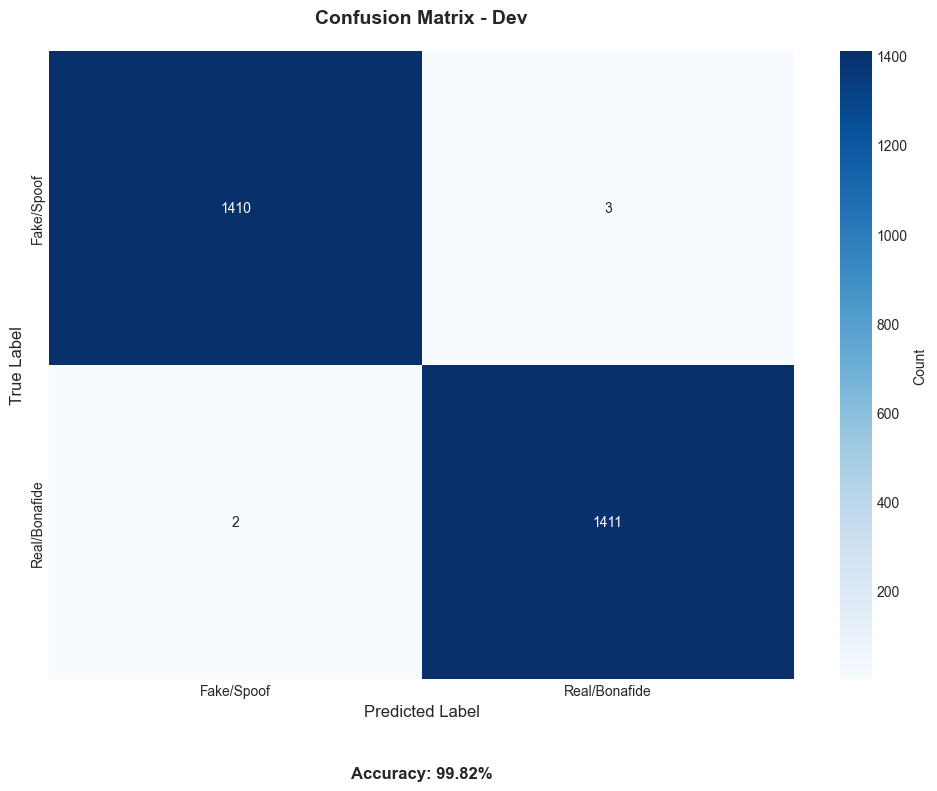

✓ ROC curve saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\roc_curve_dev.png


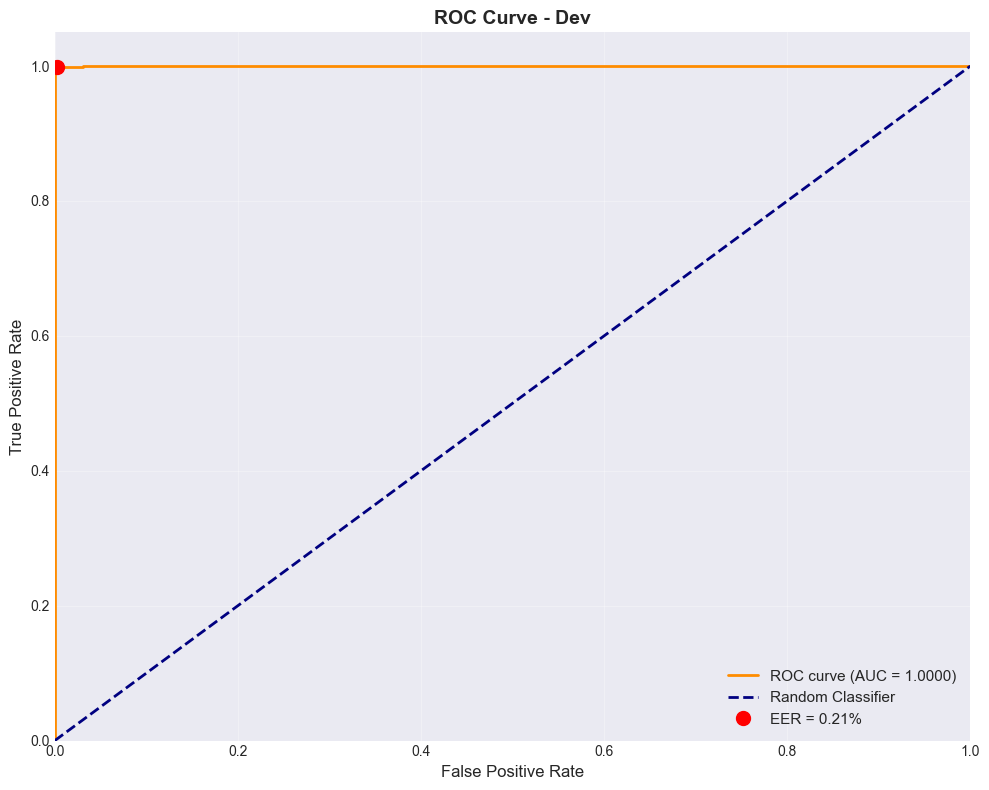


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9986    0.9979    0.9982      1413
Real/Bonafide     0.9979    0.9986    0.9982      1413

     accuracy                         0.9982      2826
    macro avg     0.9982    0.9982    0.9982      2826
 weighted avg     0.9982    0.9982    0.9982      2826

✓ Classification report saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 99.82%  |  ROC AUC: 1.0000  |  EER: 0.21%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1410            3
    Actual Real/Bonafide            2         1411

----------------------------------------------------------

[INFO] Eval EER threshold: 3.3240

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\confusion_matrix_eval.png


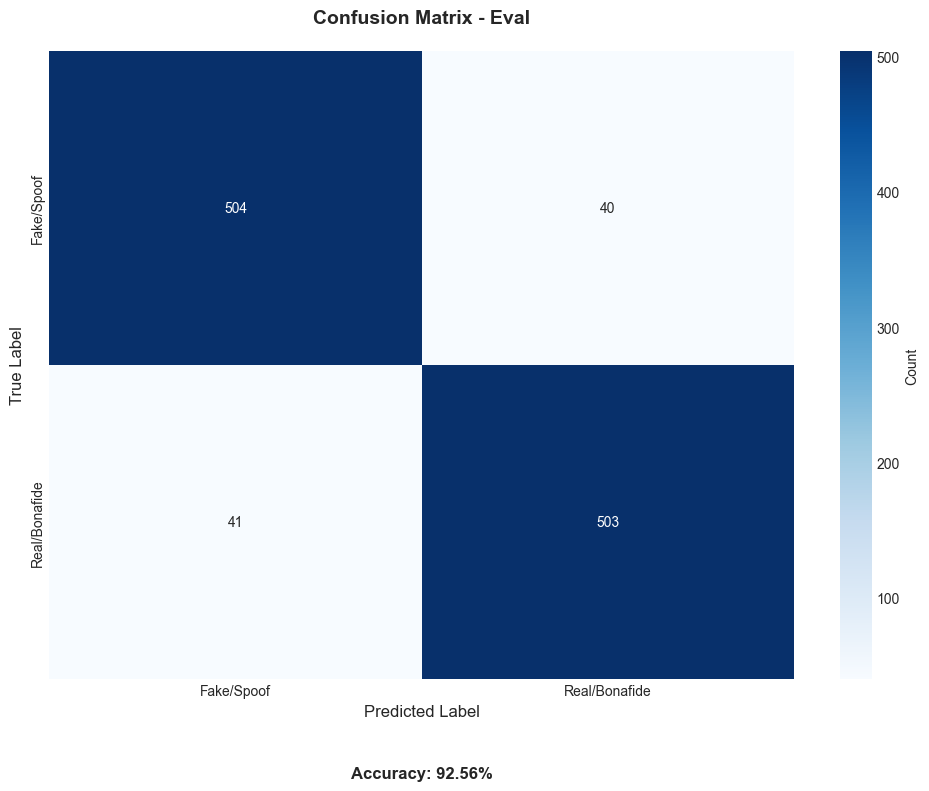

✓ ROC curve saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\roc_curve_eval.png


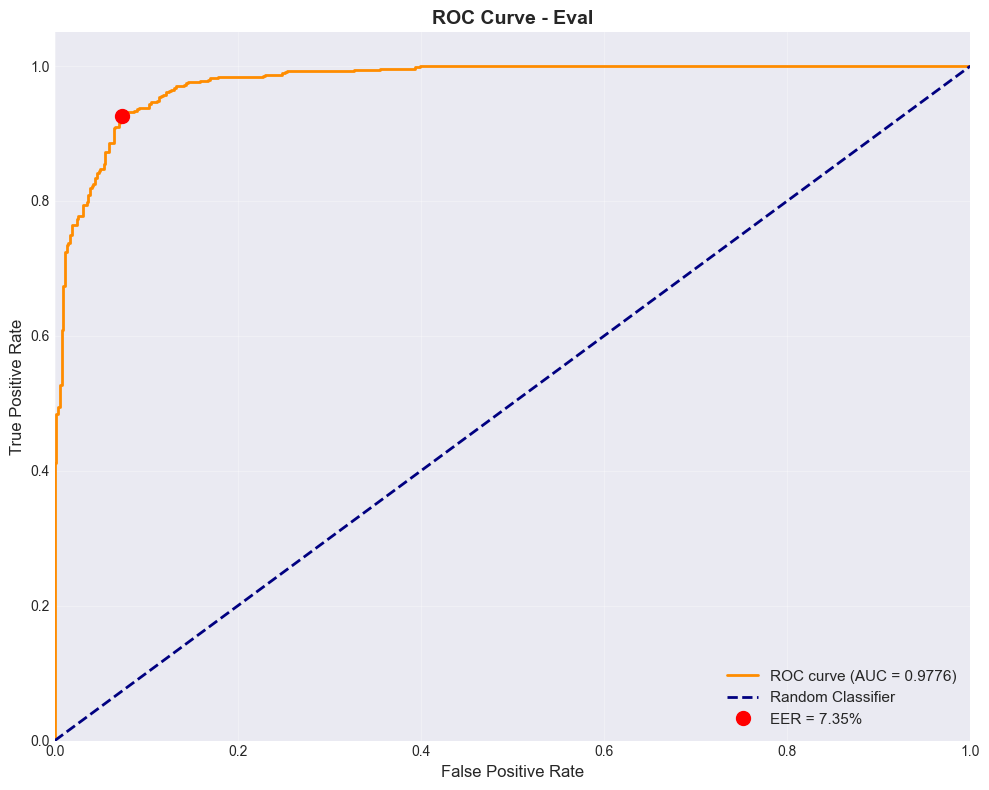


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9248    0.9265    0.9256       544
Real/Bonafide     0.9263    0.9246    0.9255       544

     accuracy                         0.9256      1088
    macro avg     0.9256    0.9256    0.9256      1088
 weighted avg     0.9256    0.9256    0.9256      1088

✓ Classification report saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 92.56%  |  ROC AUC: 0.9776  |  EER: 7.35%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          504           40
    Actual Real/Bonafide           41          503

--------------------------------------------------------

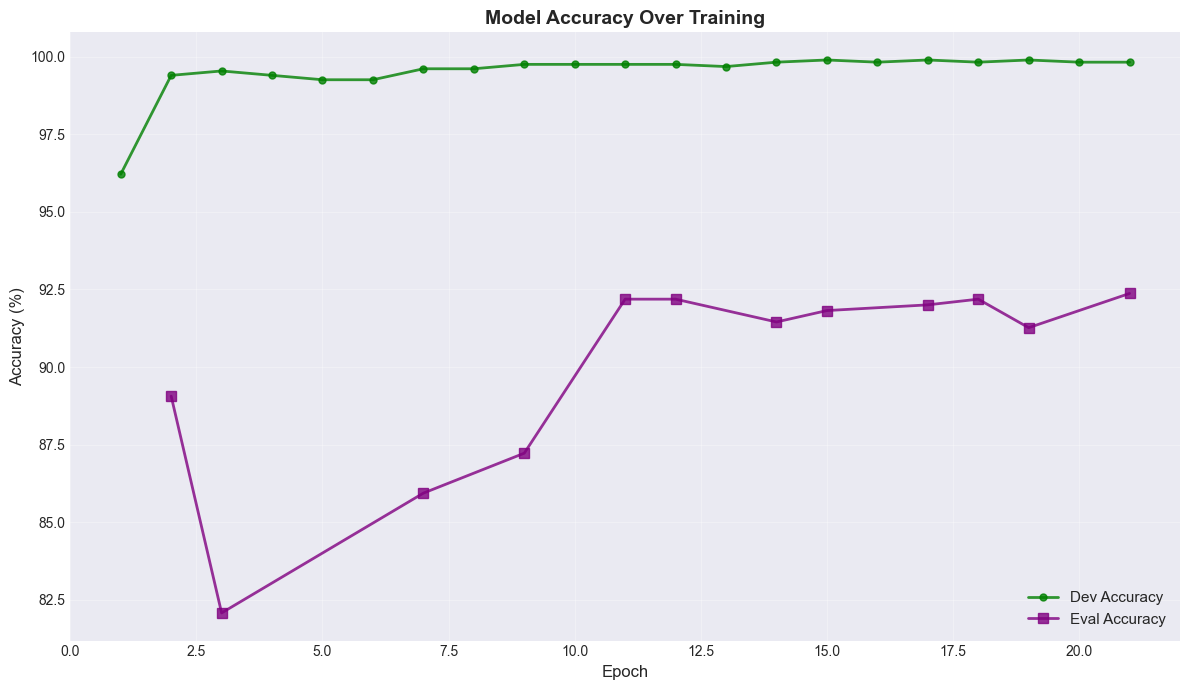


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.26125
  Final Loss:   0.03131
  Min Loss:     0.03131

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     0.0708%
  Best Dev Accuracy: 99.89%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       7.3529%
  ROC AUC:   0.9776
  Accuracy:  92.56%


[OK] Final summary saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 7.537, Accuracy: 92.56%


In [5]:
%run   main.py --config config/LCNN.conf --feature_type 1 --dataset 2 --epochs 20 --random_noise --weight_avg --eval_best  

### LCNN Large



DATASET: Fake-or-Real (Type 2)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: 1 (MEL_SPECTROGRAM)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
CuDNN Benchmark: Enabled
no. model params:1901635
Memory Format: channels_last (optimized for CNNs)

TRAINING CONFIGURATION SUMMARY
  Model:            LCNN
  Dataset:          Fake-or-Real (Type 2)
  Feature:          mel_spectrogram (Type 1)
  Augmentation:     ✅ ENABLED
  Weight Avg (SWA): ✅ ENABLED
  Epochs:           20
  Batch Size:       24


Dataset loaded from: fake_or_real\for-2sec\for-2seconds
Training 

Training: 100%|█| 581/581 [02:32<00:00,  3.81batch/s, loss=0.4



Validating on development set...


Evaluation: 100%|████████| 118/118 [00:21<00:00,  5.40batch/s]


Scores saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\dev_score.txt
DONE.
Loss:0.44941, dev_eer: 5.308, dev_acc: 94.73%

Start training epoch 2/20


...

Evaluation: 100%|██████████| 46/46 [00:07<00:00,  6.17batch/s]


Scores saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\eval_scores_using_best_dev_model.txt
epoch020, 
Saving epoch 20 for SWA (weight averaging - best model)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 14 model snapshots


Evaluation: 100%|██████████| 46/46 [00:07<00:00,  6.24batch/s]


Scores saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\eval_scores_using_best_dev_model.txt

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZATIONS

[INFO] Collecting predictions for visualization...

[INFO] Development Set:


[INFO] Dev EER threshold: -0.5237

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\confusion_matrix_dev.png


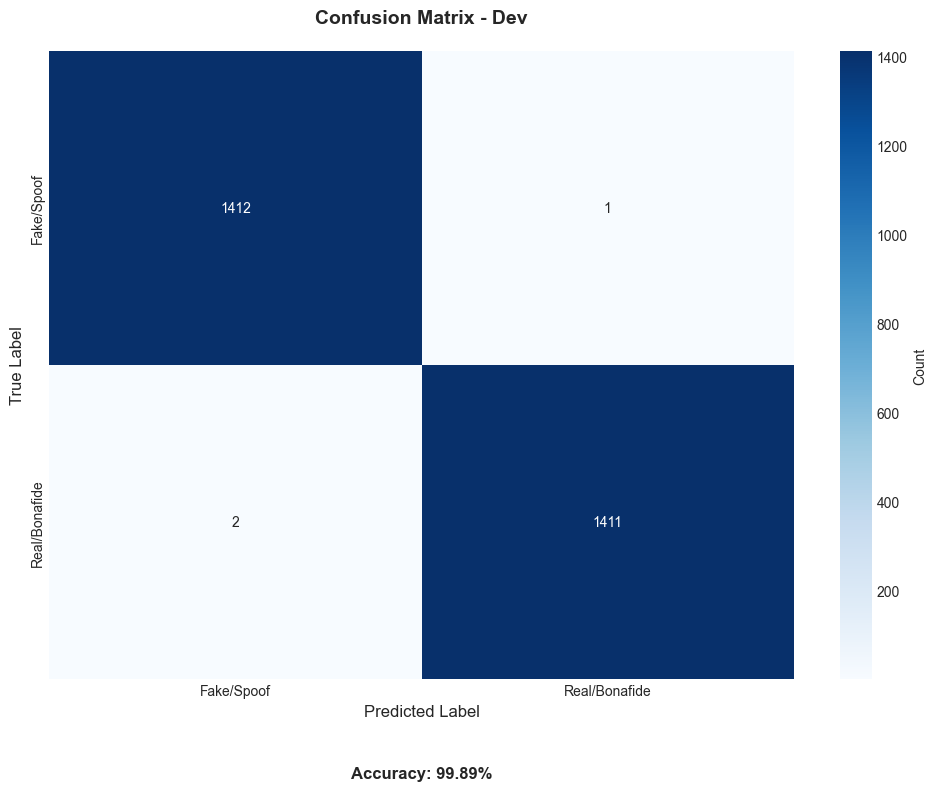

✓ ROC curve saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\roc_curve_dev.png


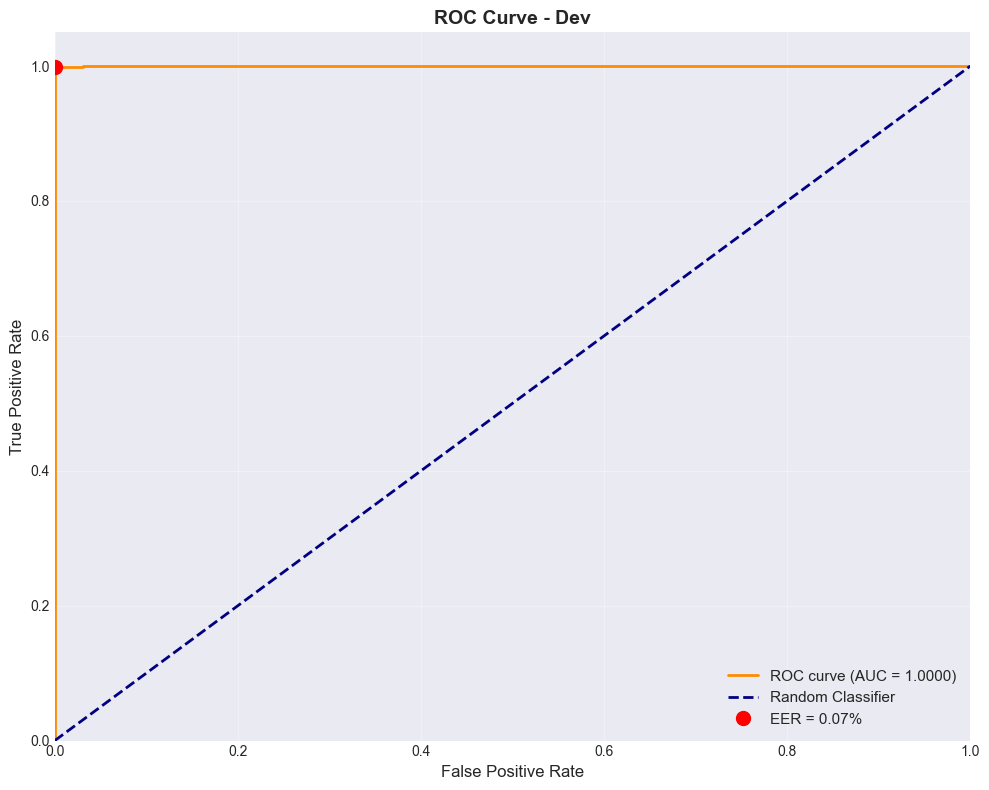


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9986    0.9993    0.9989      1413
Real/Bonafide     0.9993    0.9986    0.9989      1413

     accuracy                         0.9989      2826
    macro avg     0.9989    0.9989    0.9989      2826
 weighted avg     0.9989    0.9989    0.9989      2826

✓ Classification report saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 99.89%  |  ROC AUC: 1.0000  |  EER: 0.07%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1412            1
    Actual Real/Bonafide            2         1411

----------------------------------------------------

[INFO] Eval EER threshold: 1.9280

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\confusion_matrix_eval.png


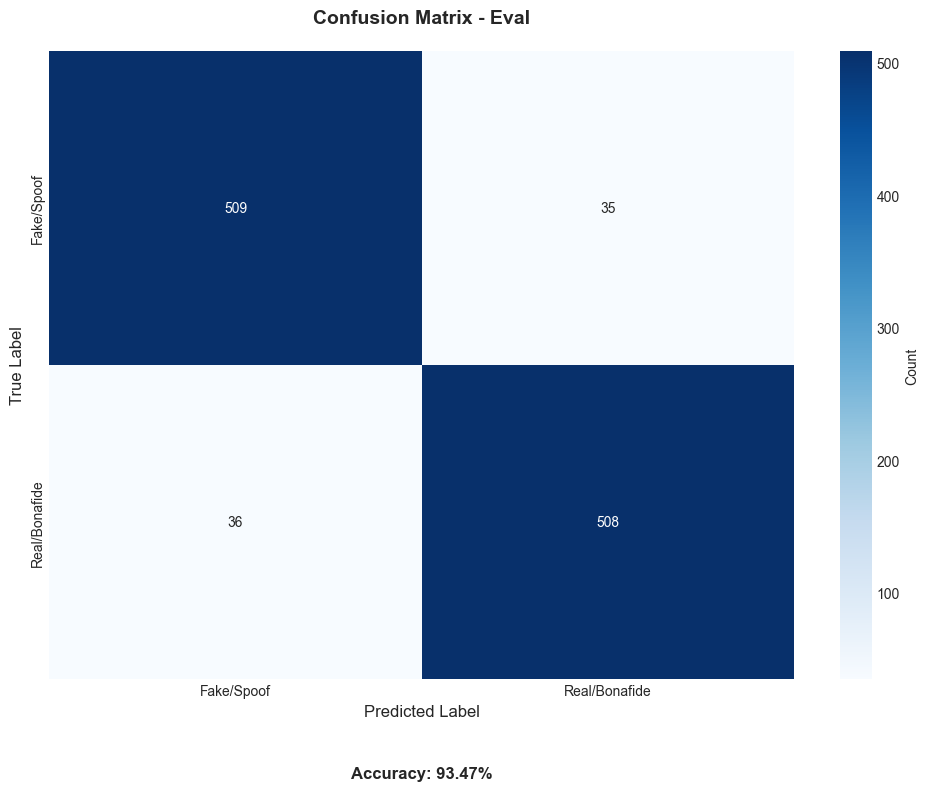

✓ ROC curve saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\roc_curve_eval.png


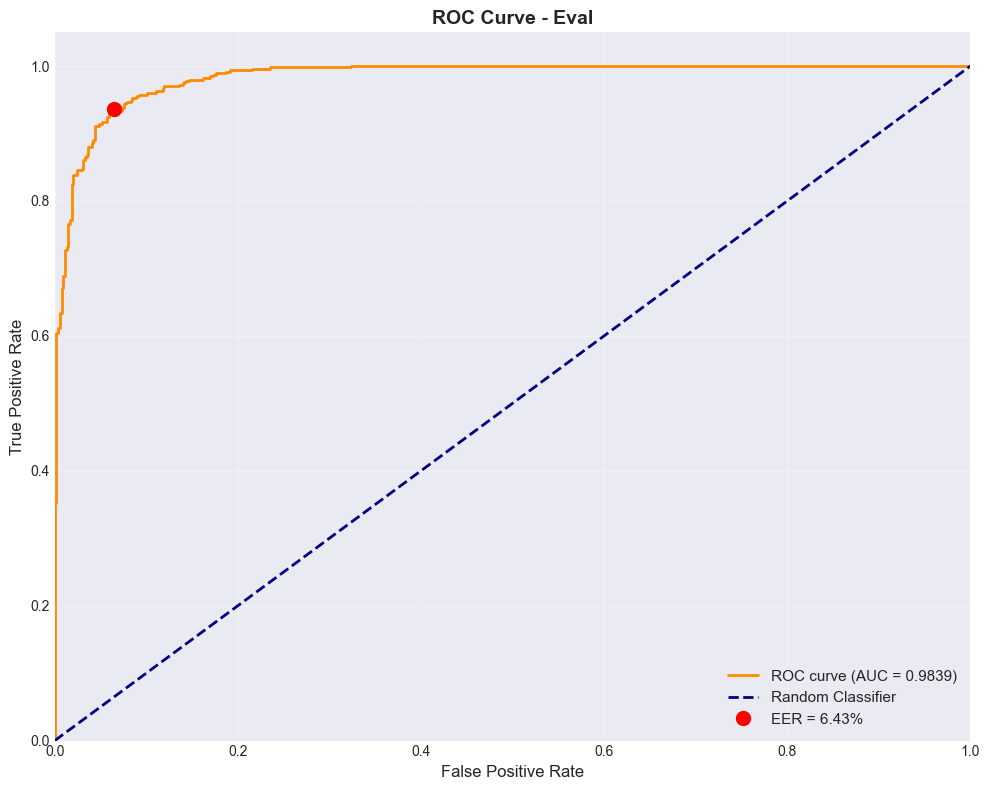


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9339    0.9357    0.9348       544
Real/Bonafide     0.9355    0.9338    0.9347       544

     accuracy                         0.9347      1088
    macro avg     0.9347    0.9347    0.9347      1088
 weighted avg     0.9347    0.9347    0.9347      1088

✓ Classification report saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 93.47%  |  ROC AUC: 0.9839  |  EER: 6.43%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          509           35
    Actual Real/Bonafide           36          508

--------------------------------------------------

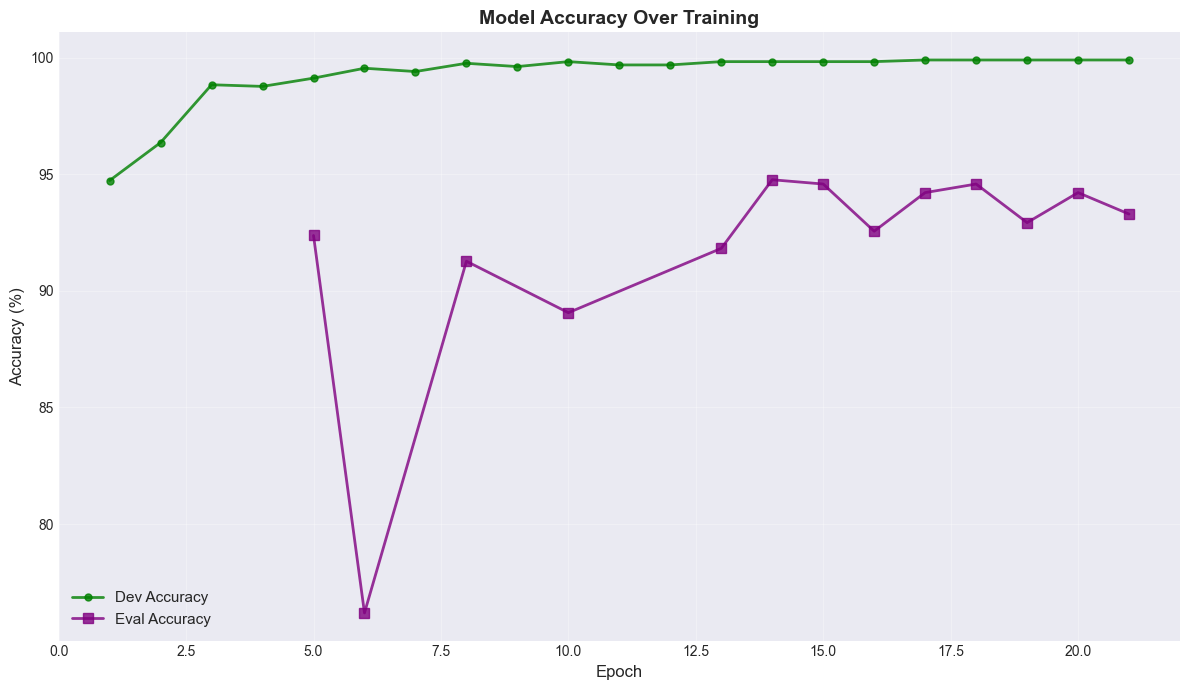


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.44941
  Final Loss:   0.03225
  Min Loss:     0.03212

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     0.0708%
  Best Dev Accuracy: 99.89%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       6.4338%
  ROC AUC:   0.9839
  Accuracy:  93.47%


[OK] Final summary saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 5.147, Accuracy: 93.47%


<Figure size 640x480 with 0 Axes>

In [6]:
%run  main.py --config config/LCNN_Large.conf --feature_type 1 --dataset 2 --epochs 20 --random_noise --weight_avg --eval_best  

### SEResNet



DATASET: Fake-or-Real (Type 2)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: 1 (MEL_SPECTROGRAM)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
CuDNN Benchmark: Enabled
no. model params:11981251
Memory Format: channels_last (optimized for CNNs)

TRAINING CONFIGURATION SUMMARY
  Model:            SEResNet
  Dataset:          Fake-or-Real (Type 2)
  Feature:          mel_spectrogram (Type 1)
  Augmentation:     ✅ ENABLED
  Weight Avg (SWA): ✅ ENABLED
  Epochs:           15
  Batch Size:       32


Dataset loaded from: fake_or_real\for-2sec\for-2seconds
Trai

Training: 100%|█| 436/436 [02:08<00:00,  3.41batch/s, loss=0.2



Validating on development set...


Evaluation: 100%|██████████| 89/89 [00:15<00:00,  5.66batch/s]


Scores saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\dev_score.txt
DONE.
Loss:0.24241, dev_eer: 34.749, dev_acc: 65.29%

Start training epoch 2/15


...

Evaluation: 100%|██████████| 34/34 [00:05<00:00,  5.71batch/s]


Scores saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\eval_scores_using_best_dev_model.txt
epoch015, 
Saving epoch 15 for SWA (weight averaging - best model)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 12 model snapshots


Evaluation: 100%|██████████| 34/34 [00:05<00:00,  6.24batch/s]


Scores saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\eval_scores_using_best_dev_model.txt

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZATIONS

[INFO] Collecting predictions for visualization...

[INFO] Development Set:


[INFO] Dev EER threshold: -0.4748

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\confusion_matrix_dev.png


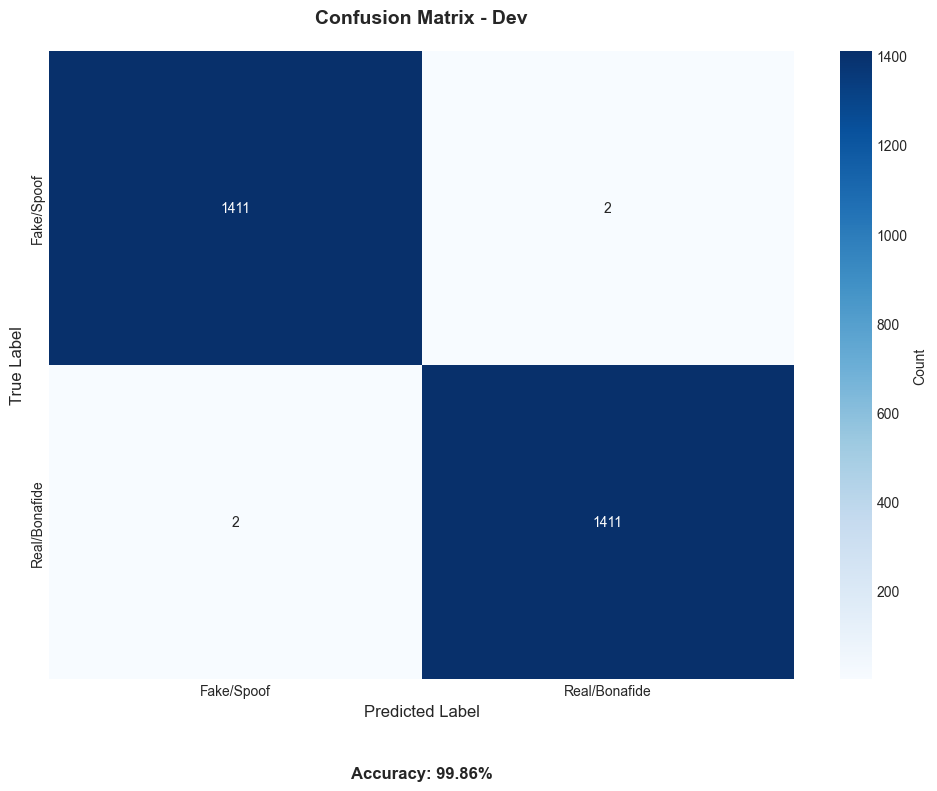

✓ ROC curve saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\roc_curve_dev.png


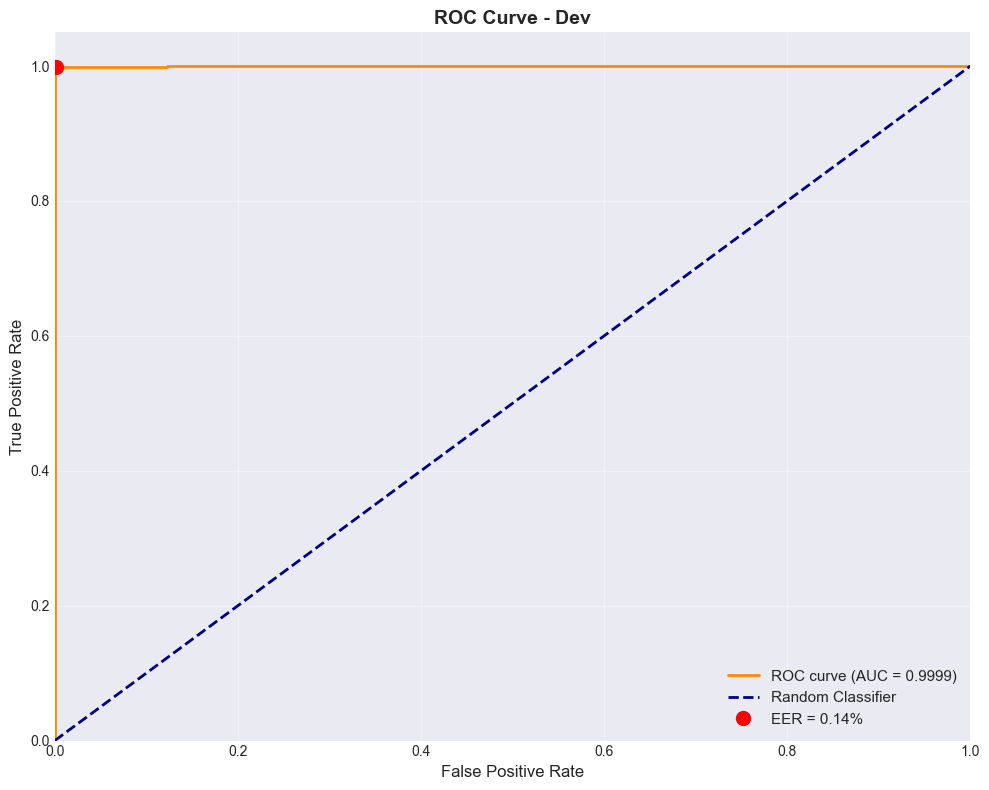


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9986    0.9986    0.9986      1413
Real/Bonafide     0.9986    0.9986    0.9986      1413

     accuracy                         0.9986      2826
    macro avg     0.9986    0.9986    0.9986      2826
 weighted avg     0.9986    0.9986    0.9986      2826

✓ Classification report saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 99.86%  |  ROC AUC: 0.9999  |  EER: 0.14%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1411            2
    Actual Real/Bonafide            2         1411

------------------------------------------------------

[INFO] Eval EER threshold: 3.4261

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\confusion_matrix_eval.png


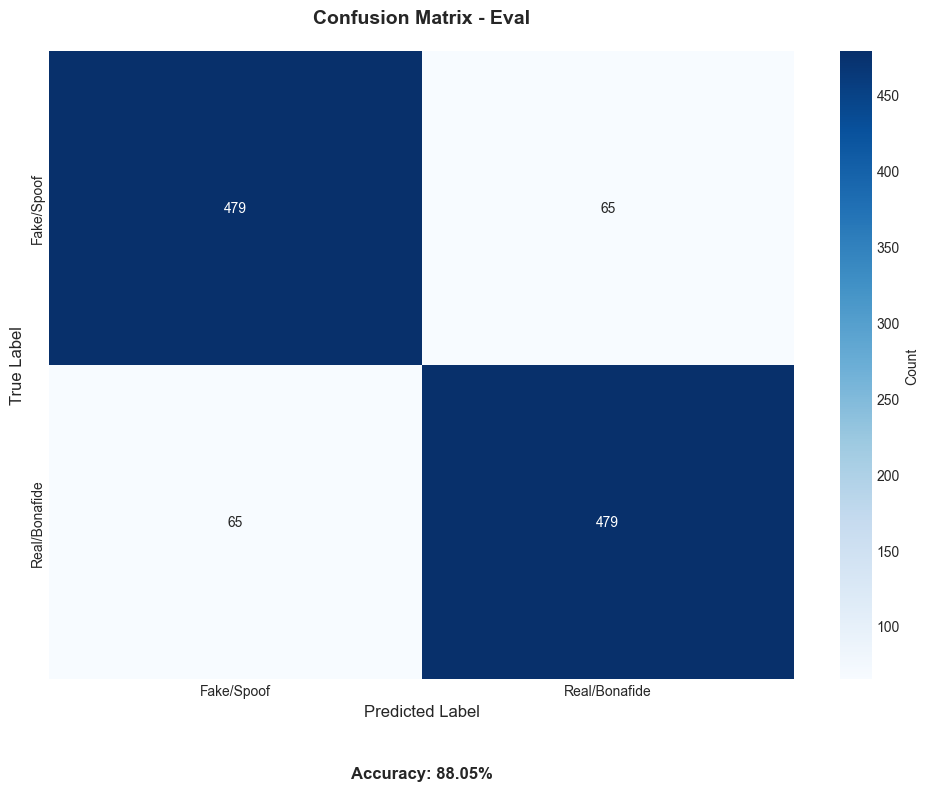

✓ ROC curve saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\roc_curve_eval.png


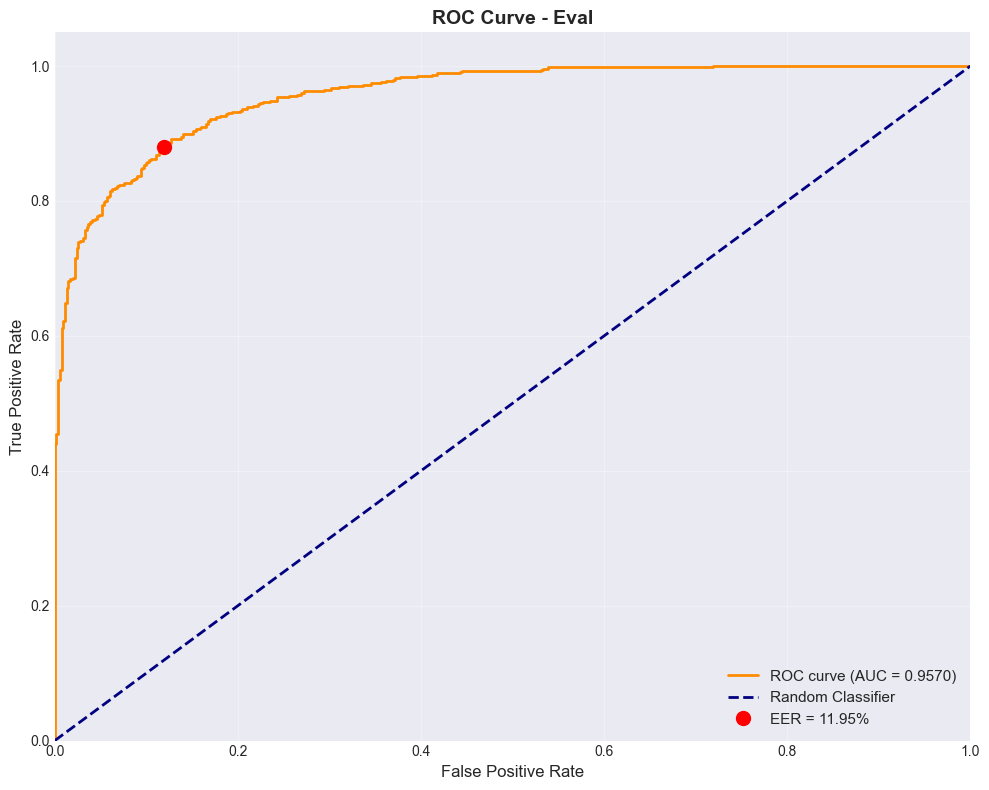


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.8805    0.8805    0.8805       544
Real/Bonafide     0.8805    0.8805    0.8805       544

     accuracy                         0.8805      1088
    macro avg     0.8805    0.8805    0.8805      1088
 weighted avg     0.8805    0.8805    0.8805      1088

✓ Classification report saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 88.05%  |  ROC AUC: 0.9570  |  EER: 11.95%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          479           65
    Actual Real/Bonafide           65          479

---------------------------------------------------

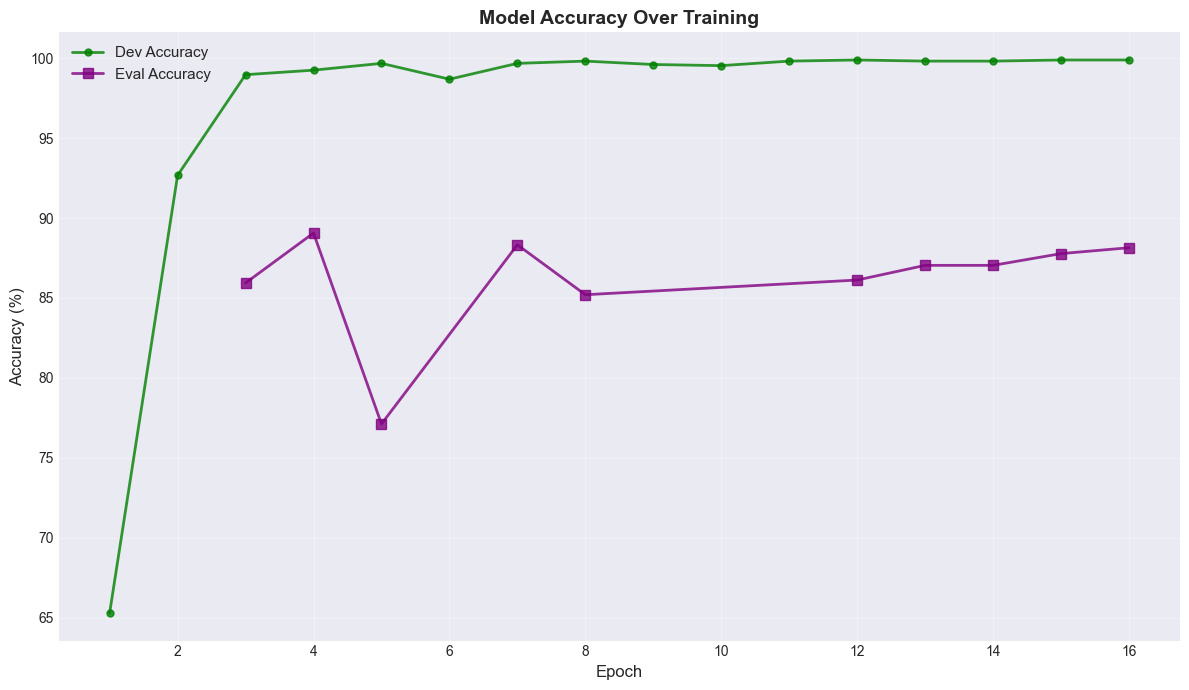


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.24241
  Final Loss:   0.02277
  Min Loss:     0.02277

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     0.0708%
  Best Dev Accuracy: 99.89%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       11.9485%
  ROC AUC:   0.9570
  Accuracy:  88.05%


[OK] Final summary saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 10.846, Accuracy: 88.05%


<Figure size 640x480 with 0 Axes>

In [7]:
%run   main.py --config config/SEResNet.conf --feature_type 1 --dataset 2 --epochs 15 --random_noise --weight_avg --eval_best  

### EfficientNet-B2 with Attention



DATASET: Fake-or-Real (Type 2)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: 1 (MEL_SPECTROGRAM)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
CuDNN Benchmark: Enabled
no. model params:10865581
Memory Format: channels_last (optimized for CNNs)

TRAINING CONFIGURATION SUMMARY
  Model:            EfficientNetB2
  Dataset:          Fake-or-Real (Type 2)
  Feature:          mel_spectrogram (Type 1)
  Augmentation:     ✅ ENABLED
  Weight Avg (SWA): ✅ ENABLED
  Epochs:           20
  Batch Size:       24


Dataset loaded from: fake_or_real\for-2sec\for-2second

Training: 100%|█| 581/581 [03:00<00:00,  3.22batch/s, loss=0.3



Validating on development set...


Evaluation: 100%|████████| 118/118 [00:24<00:00,  4.87batch/s]


Scores saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\dev_score.txt
DONE.
Loss:0.33515, dev_eer: 0.849, dev_acc: 99.19%
best model find at epoch 1


...

Evaluation: 100%|████████| 118/118 [00:15<00:00,  7.62batch/s]


Scores saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\dev_score.txt
DONE.
Loss:0.01398, dev_eer: 0.071, dev_acc: 99.96%
Saving epoch 20 for SWA (weight averaging - late epoch)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 17 model snapshots


Evaluation: 100%|██████████| 46/46 [00:05<00:00,  7.71batch/s]


Scores saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\eval_scores_using_best_dev_model.txt

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZATIONS

[INFO] Collecting predictions for visualization...

[INFO] Development Set:


[INFO] Dev EER threshold: -0.6637

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\confusion_matrix_dev.png


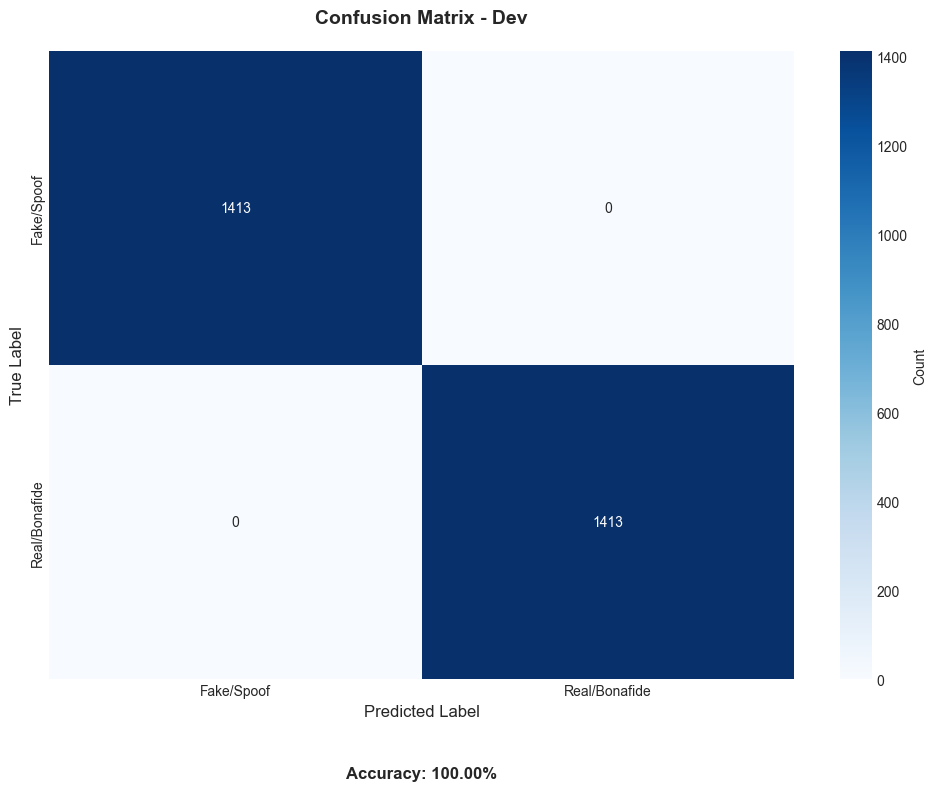

✓ ROC curve saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\roc_curve_dev.png


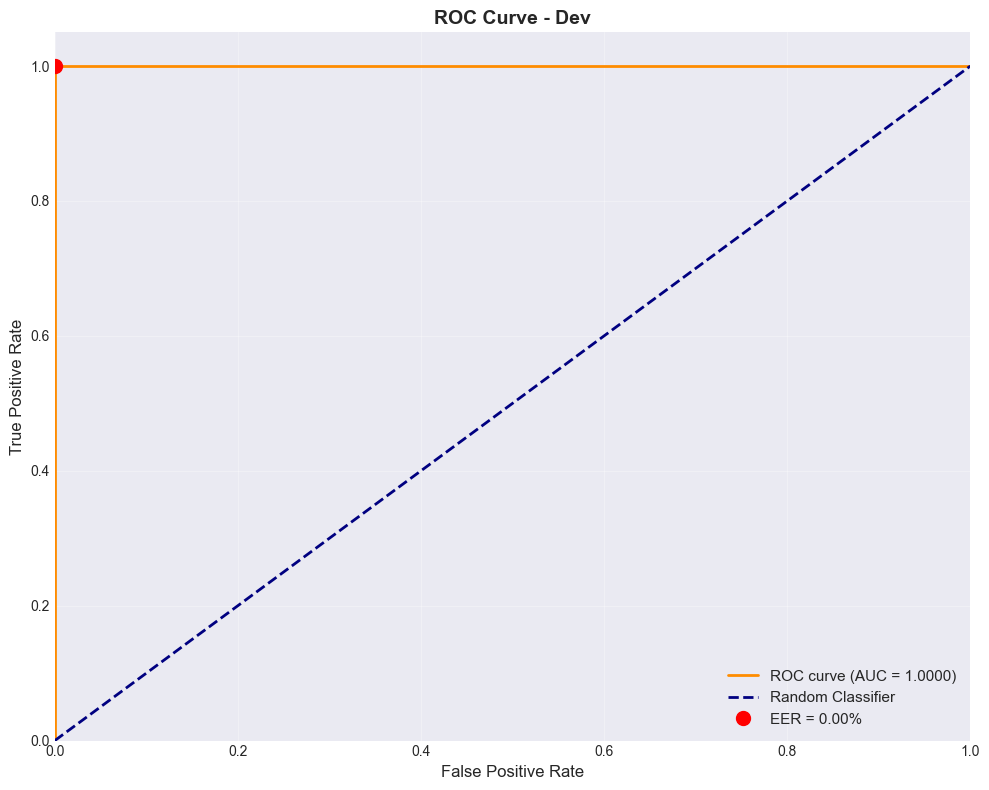


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     1.0000    1.0000    1.0000      1413
Real/Bonafide     1.0000    1.0000    1.0000      1413

     accuracy                         1.0000      2826
    macro avg     1.0000    1.0000    1.0000      2826
 weighted avg     1.0000    1.0000    1.0000      2826

✓ Classification report saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 100.00%  |  ROC AUC: 1.0000  |  EER: 0.00%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1413            0
    Actual Real/Bonafide            0         1413

-------------------------------------

[INFO] Eval EER threshold: 4.6540

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\confusion_matrix_eval.png


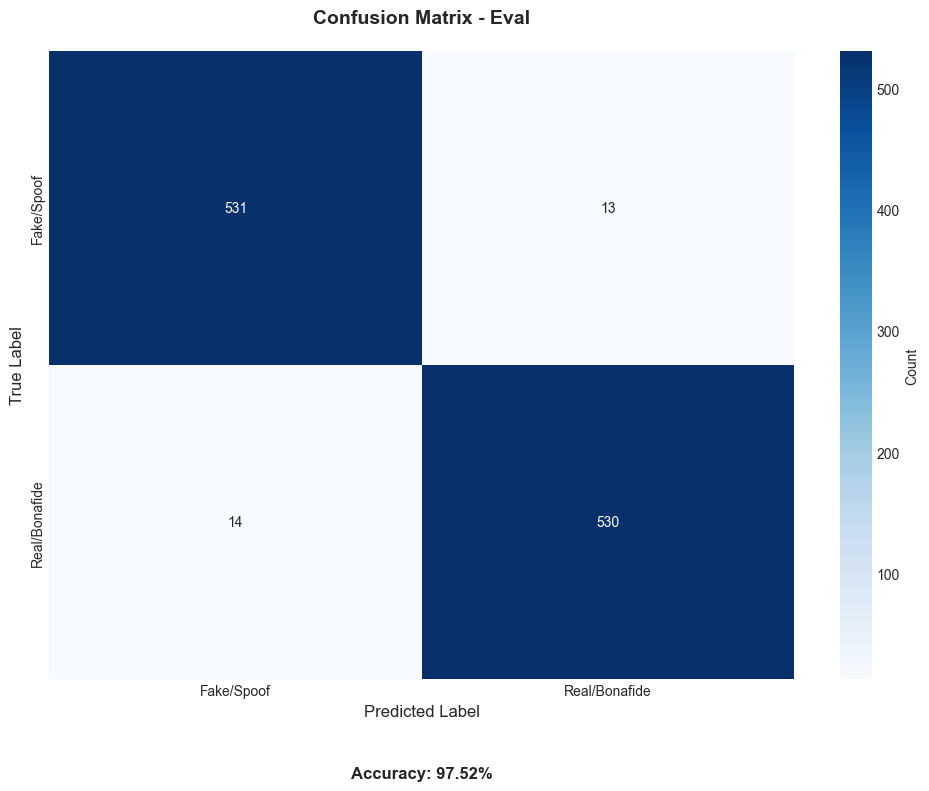

✓ ROC curve saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\roc_curve_eval.png


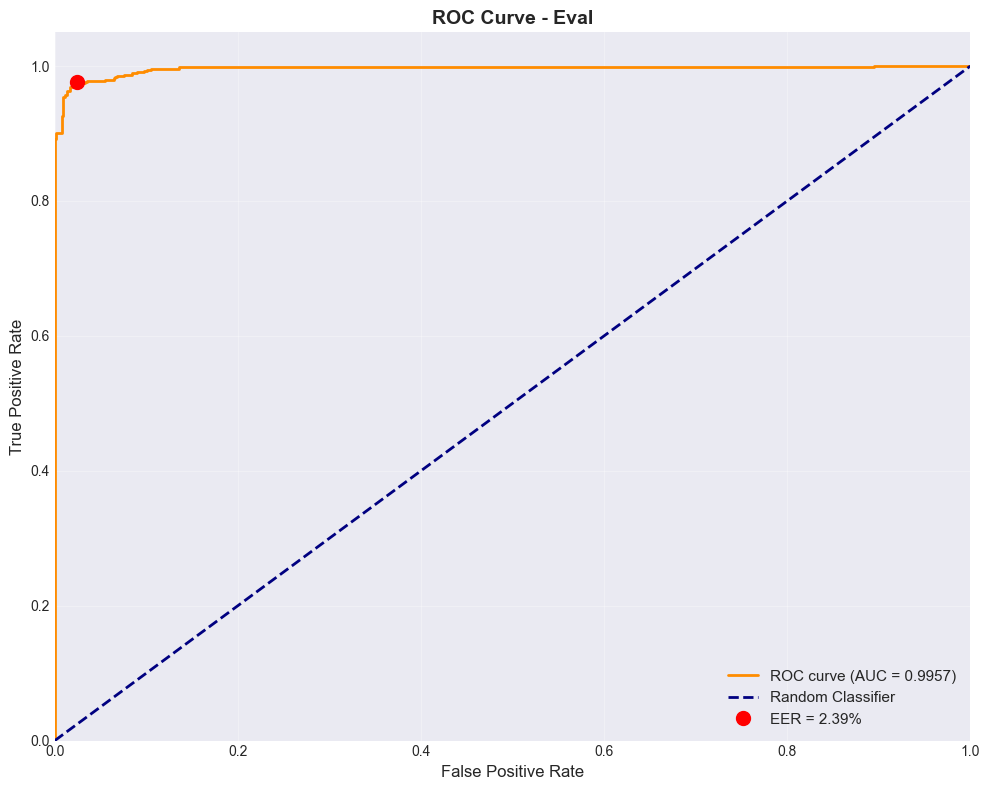


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9743    0.9761    0.9752       544
Real/Bonafide     0.9761    0.9743    0.9752       544

     accuracy                         0.9752      1088
    macro avg     0.9752    0.9752    0.9752      1088
 weighted avg     0.9752    0.9752    0.9752      1088

✓ Classification report saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 97.52%  |  ROC AUC: 0.9957  |  EER: 2.39%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          531           13
    Actual Real/Bonafide           14          530

------------------------------------

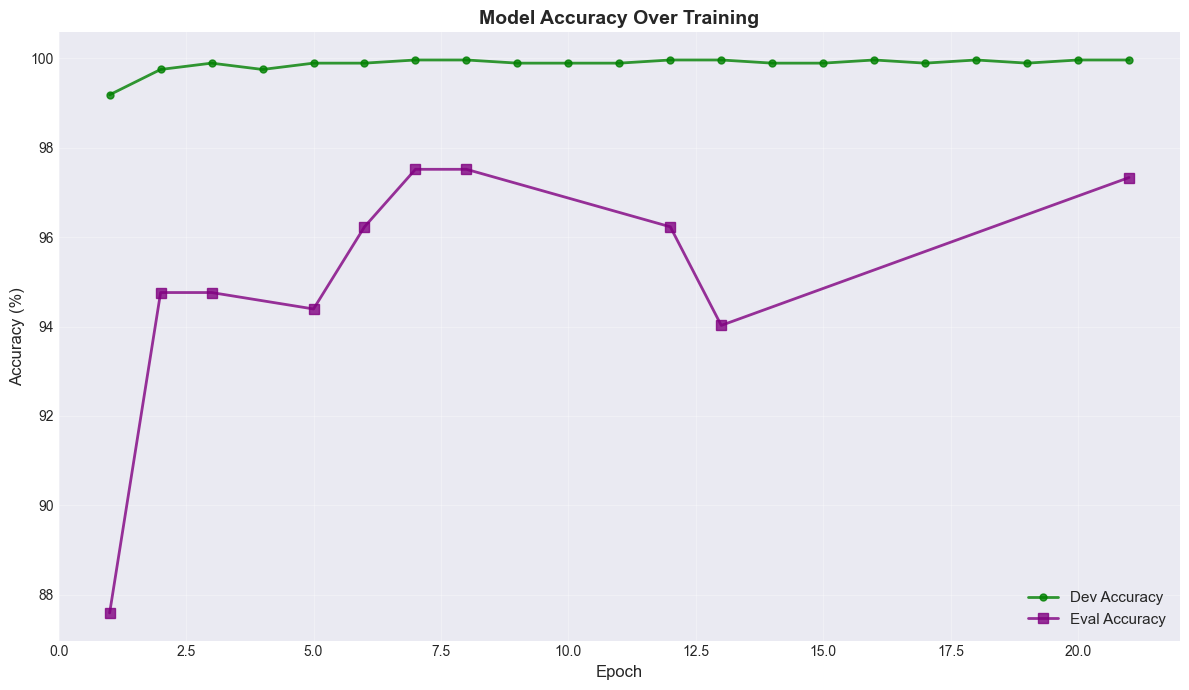


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.33515
  Final Loss:   0.01398
  Min Loss:     0.01254

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     0.0000%
  Best Dev Accuracy: 99.96%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       2.3897%
  ROC AUC:   0.9957
  Accuracy:  97.52%


[OK] Final summary saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 2.390, Accuracy: 97.52%


<Figure size 640x480 with 0 Axes>

In [8]:
%run    main.py --config config/EfficientNetB2_Attention.conf --feature_type 1 --dataset 2 --epochs 20 --random_noise --weight_avg --eval_best   

### RawNet3



DATASET: Fake-or-Real (Type 2)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: 0 (RAW)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
no. model params:1425570

TRAINING CONFIGURATION SUMMARY
  Model:            RawNet3
  Dataset:          Fake-or-Real (Type 2)
  Feature:          raw (Type 0)
  Augmentation:     ✅ ENABLED
  Weight Avg (SWA): ✅ ENABLED
  Epochs:           15
  Batch Size:       8


Dataset loaded from: fake_or_real\for-2sec\for-2seconds
Training samples: 13956 (Real: 6978, Fake: 6978)
Validation samples: 2826 (Real: 1413, Fake: 1413)
Testing

Training: 100%|█| 1744/1744 [07:26<00:00,  3.91batch/s, loss=0



Validating on development set...


Evaluation: 100%|████████| 354/354 [01:22<00:00,  4.31batch/s]


Scores saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\dev_score.txt
DONE.
Loss:0.25328, dev_eer: 6.865, dev_acc: 93.10%

Start training epoch 2/15


...

Evaluation: 100%|████████| 354/354 [01:18<00:00,  4.50batch/s]


Scores saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\dev_score.txt
DONE.
Loss:0.08528, dev_eer: 1.628, dev_acc: 98.34%
Saving epoch 15 for SWA (weight averaging - late epoch)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 8 model snapshots


Evaluation: 100%|████████| 136/136 [00:40<00:00,  3.38batch/s]


Scores saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\eval_scores_using_best_dev_model.txt

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZATIONS

[INFO] Collecting predictions for visualization...

[INFO] Development Set:


[INFO] Dev EER threshold: 0.7945

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\confusion_matrix_dev.png


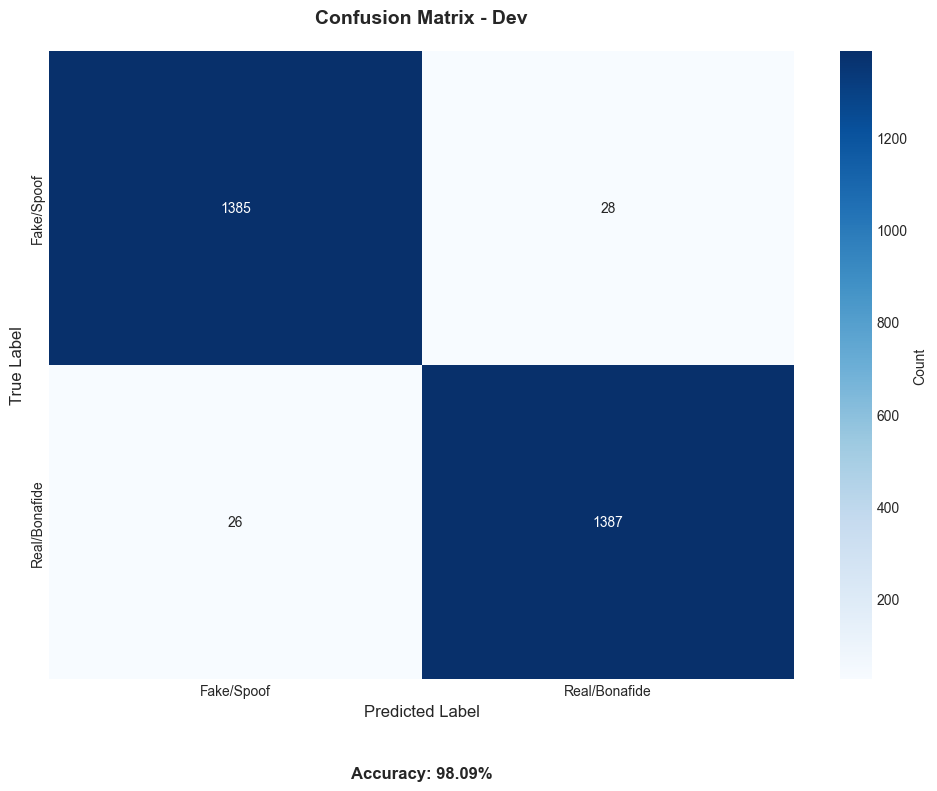

✓ ROC curve saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\roc_curve_dev.png


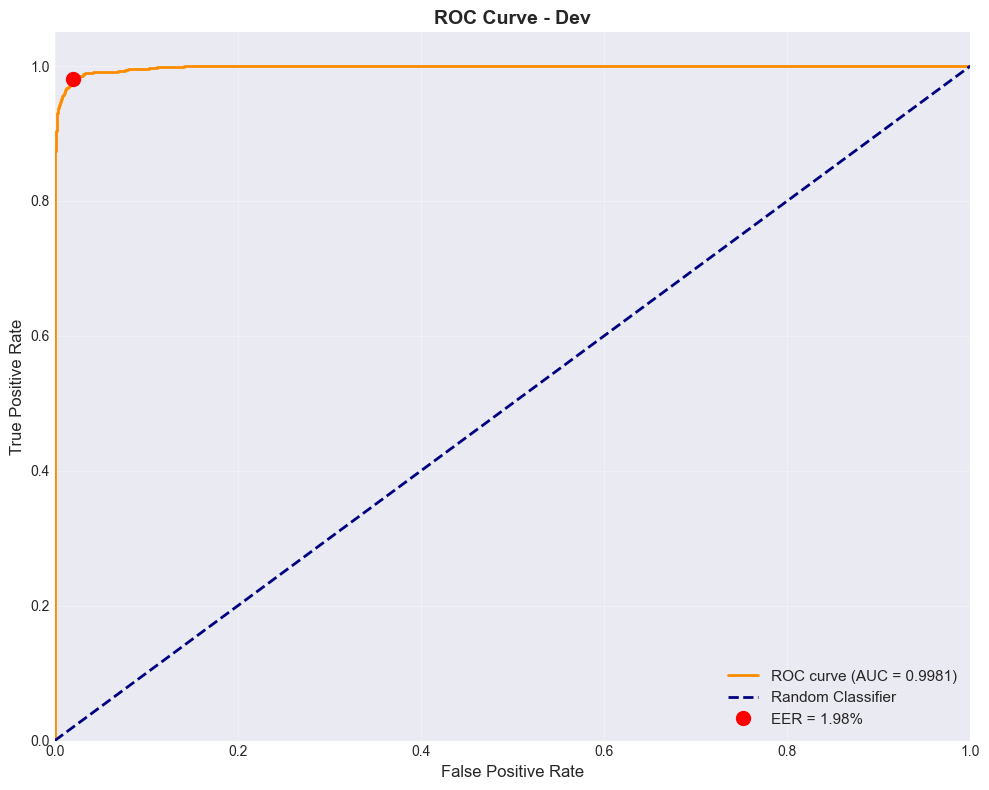


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9816    0.9802    0.9809      1413
Real/Bonafide     0.9802    0.9816    0.9809      1413

     accuracy                         0.9809      2826
    macro avg     0.9809    0.9809    0.9809      2826
 weighted avg     0.9809    0.9809    0.9809      2826

✓ Classification report saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 98.09%  |  ROC AUC: 0.9981  |  EER: 1.98%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1385           28
    Actual Real/Bonafide           26         1387

--------------------------------------------------------

[INFO] Eval EER threshold: 2.6104

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\confusion_matrix_eval.png


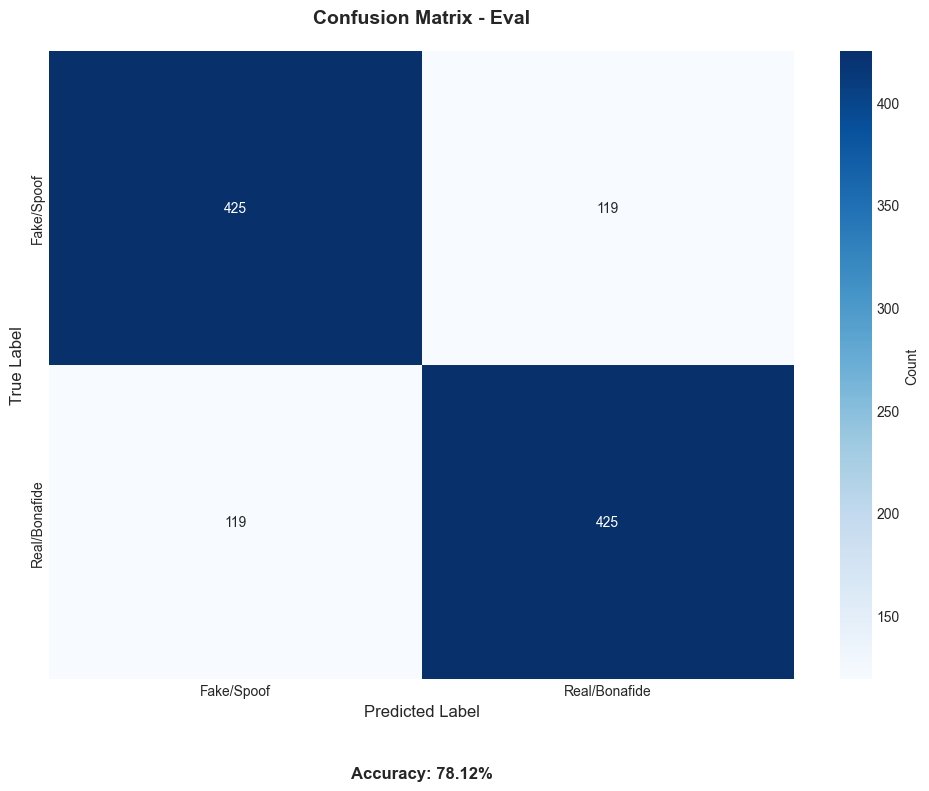

✓ ROC curve saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\roc_curve_eval.png


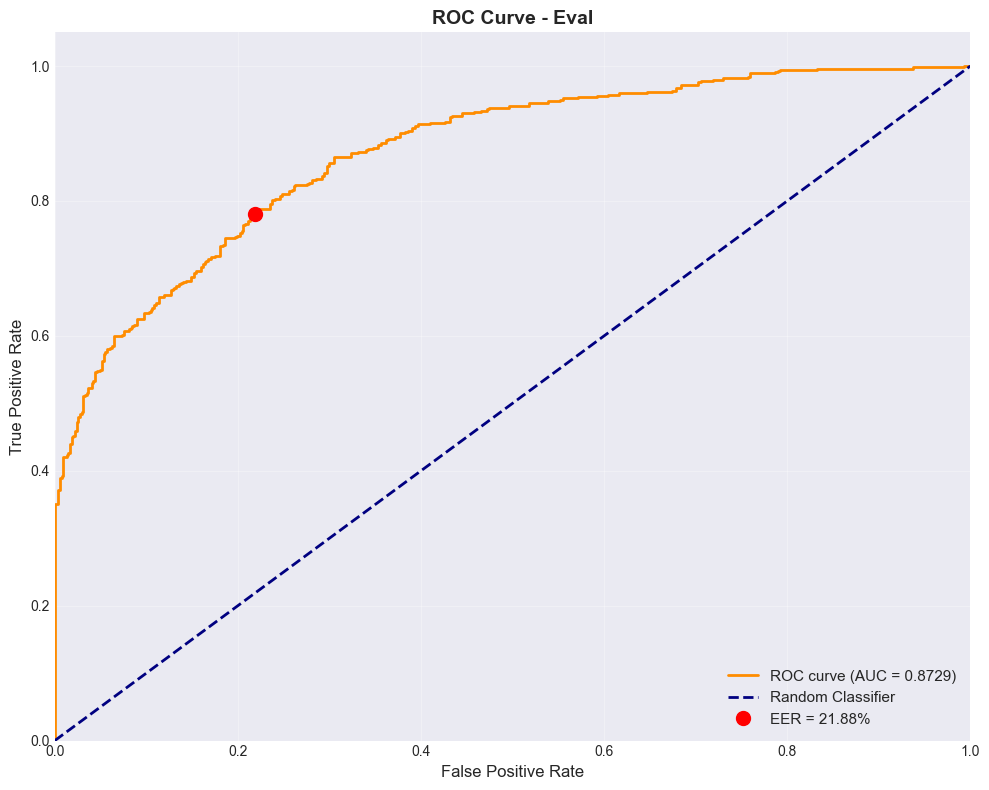


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.7812    0.7812    0.7812       544
Real/Bonafide     0.7812    0.7812    0.7812       544

     accuracy                         0.7812      1088
    macro avg     0.7812    0.7812    0.7812      1088
 weighted avg     0.7812    0.7812    0.7812      1088

✓ Classification report saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 78.12%  |  ROC AUC: 0.8729  |  EER: 21.88%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          425          119
    Actual Real/Bonafide          119          425

-----------------------------------------------------

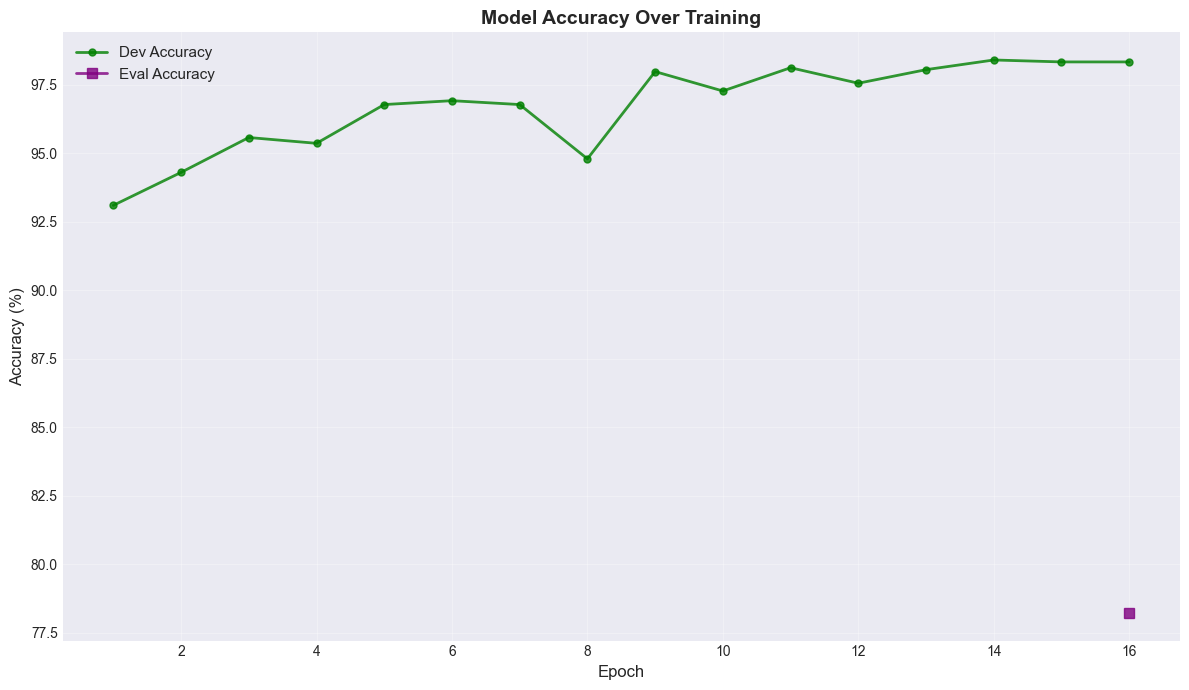


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.25328
  Final Loss:   0.08528
  Min Loss:     0.08528

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     1.6277%
  Best Dev Accuracy: 98.41%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       21.8750%
  ROC AUC:   0.8729
  Accuracy:  78.12%


[OK] Final summary saved to exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 21.875, Accuracy: 78.12%


<Figure size 640x480 with 0 Axes>

In [9]:
%run    main.py --config config/RawNet3.conf --feature_type 0 --dataset 2 --epochs 15 --random_noise --weight_avg --eval_best  

---

## 📊 Output Structure

After training, results are saved in `exp_result/`:

```
exp_result/
└── <dataset>_<track>_<model>_<flags>_ep<epochs>_bs<batch>_feat<feature>/
    ├── config.conf              # Copy of training config
    ├── weights/                 # Model checkpoints
    │   ├── best.pth            # Best model (lowest dev EER)
    │   └── swa.pth             # SWA averaged model
    ├── metrics/                 # Training metrics
    │   ├── epoch_metrics.json  # Per-epoch metrics
    │   └── final_summary.json  # Final results
    ├── metric_log.txt          # Training log
    ├── evaluation_results.txt  # Final evaluation
    └── events.out.*            # TensorBoard logs
```

### Metrics

| Metric       | Description                                    |
| ------------ | ---------------------------------------------- |
| **EER**      | Equal Error Rate                               |
| **Accuracy** | Classification accuracy                        |
| **t-DCF**    | Tandem Detection Cost Function (ASVspoof only) |


---

## 🔍 Step 5: Evaluate Model

Evaluate a trained model on the test set:


In [10]:
# Replace path with your trained model
#!python main.py --config config/LCNN.conf --dataset 2 --feature_type 1 --eval --eval_model_weights ./exp_result/<your_model_folder>/weights/best.pth

---

## 💡 Common Issues

| Issue           | Solution                                                          |
| --------------- | ----------------------------------------------------------------- |
| Out of memory   | Reduce `--batch_size 16` or `--batch_size 8`                      |
| Slow training   | Mixed precision is enabled by default (`use_amp: true` in config) |
| Need quick test | Use `--data_subset 0.1` to train on 10% of data                   |


---

## 🧪 Step 6: Feature & Model Experiments

Run experiments with different feature types and model configurations to find the best combination.

### Feature Type Reference

| Feature             | Best For            | Models                       |
| ------------------- | ------------------- | ---------------------------- |
| `0` Raw             | End-to-end learning | RawNet3, AASIST              |
| `1` Mel-spectrogram | General purpose     | LCNN, EfficientNet, SEResNet |
| `2` LFCC            | Speech features     | LCNN, SEResNet               |
| `3` MFCC            | Traditional speech  | All spectrogram models       |
| `4` CQT             | Harmonic analysis   | LCNN, EfficientNet           |


### Experiment 1: LCNN with CQT Features

CQT (Constant-Q Transform) provides excellent harmonic resolution for detecting synthesis artifacts.



DATASET: Fake-or-Real (Type 2)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: 4 (CQT)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
CuDNN Benchmark: Enabled
no. model params:444835
Memory Format: channels_last (optimized for CNNs)

TRAINING CONFIGURATION SUMMARY
  Model:            LCNN
  Dataset:          Fake-or-Real (Type 2)
  Feature:          cqt (Type 4)
  Augmentation:     ✅ ENABLED
  Weight Avg (SWA): ✅ ENABLED
  Epochs:           20
  Batch Size:       32


Dataset loaded from: fake_or_real\for-2sec\for-2seconds
Training samples: 13956 (Real: 697

Training: 100%|█| 436/436 [08:36<00:00,  1.19s/batch, loss=0.2



Validating on development set...


Evaluation: 100%|██████████| 89/89 [01:21<00:00,  1.09batch/s]


Scores saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\dev_score.txt
DONE.
Loss:0.29820, dev_eer: 4.812, dev_acc: 95.22%

Start training epoch 2/20


...

Evaluation: 100%|██████████| 34/34 [00:39<00:00,  1.15s/batch]


Scores saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\eval_scores_using_best_dev_model.txt
epoch020, 
Saving epoch 20 for SWA (weight averaging - best model)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 14 model snapshots


Evaluation: 100%|██████████| 34/34 [00:38<00:00,  1.12s/batch]


Scores saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\eval_scores_using_best_dev_model.txt

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZATIONS

[INFO] Collecting predictions for visualization...

[INFO] Development Set:


[INFO] Dev EER threshold: -0.2284

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\confusion_matrix_dev.png


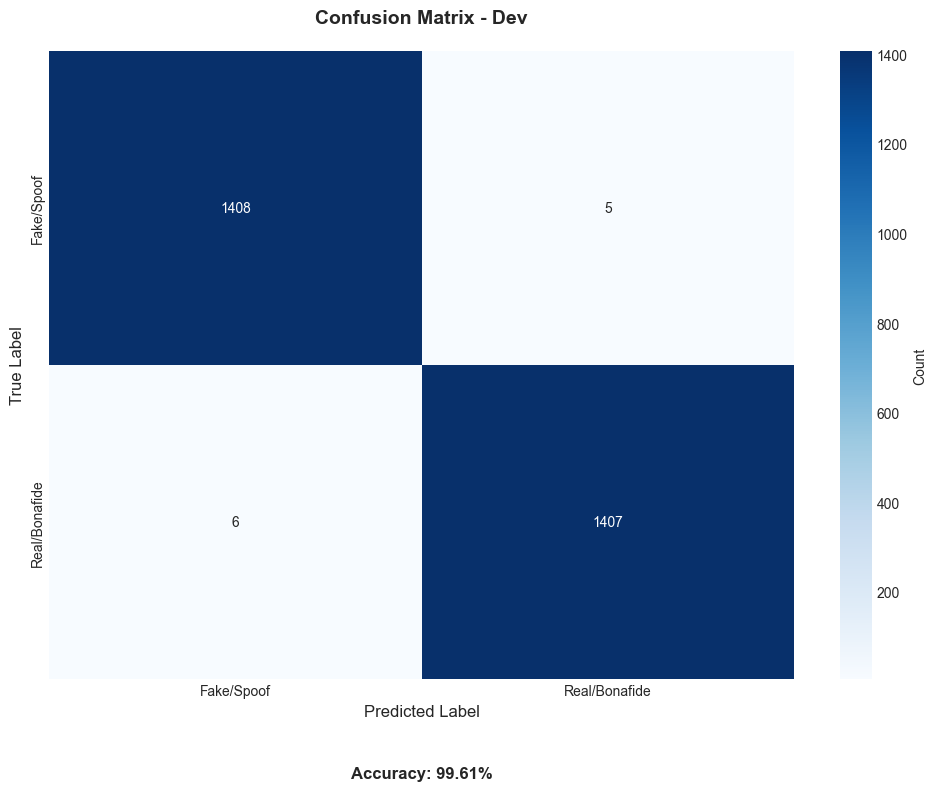

✓ ROC curve saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\roc_curve_dev.png


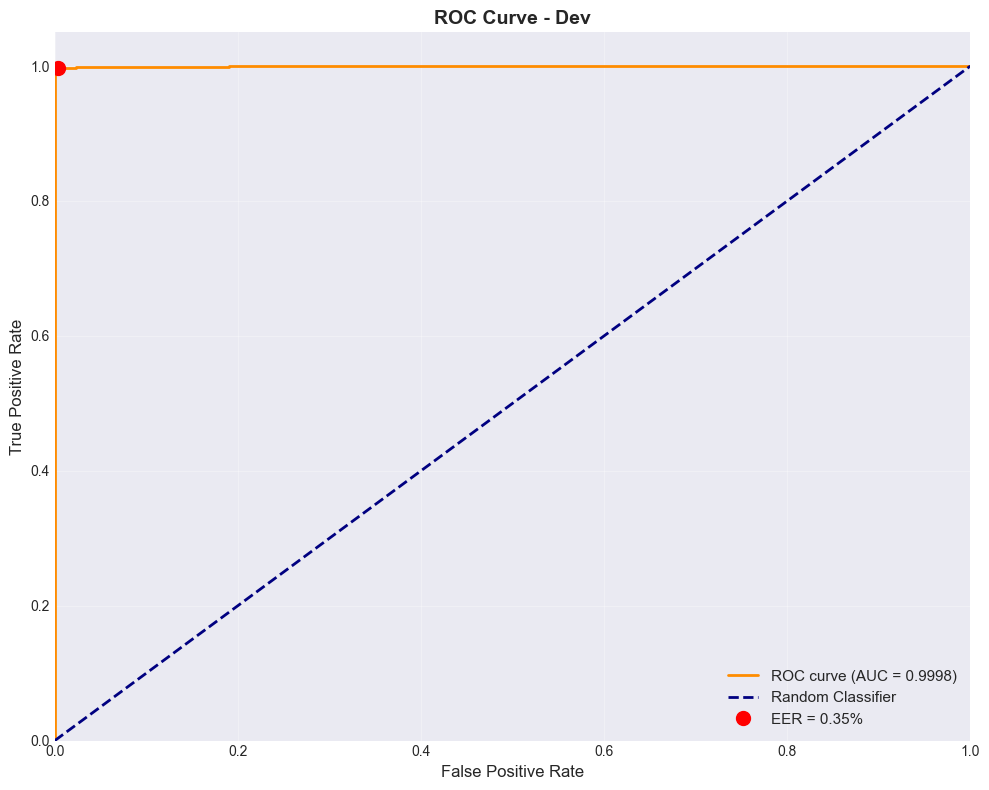


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9958    0.9965    0.9961      1413
Real/Bonafide     0.9965    0.9958    0.9961      1413

     accuracy                         0.9961      2826
    macro avg     0.9961    0.9961    0.9961      2826
 weighted avg     0.9961    0.9961    0.9961      2826

✓ Classification report saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 99.61%  |  ROC AUC: 0.9998  |  EER: 0.35%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1408            5
    Actual Real/Bonafide            6         1407

----------------------------------------------------------

[INFO] Eval EER threshold: 1.7432

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\confusion_matrix_eval.png


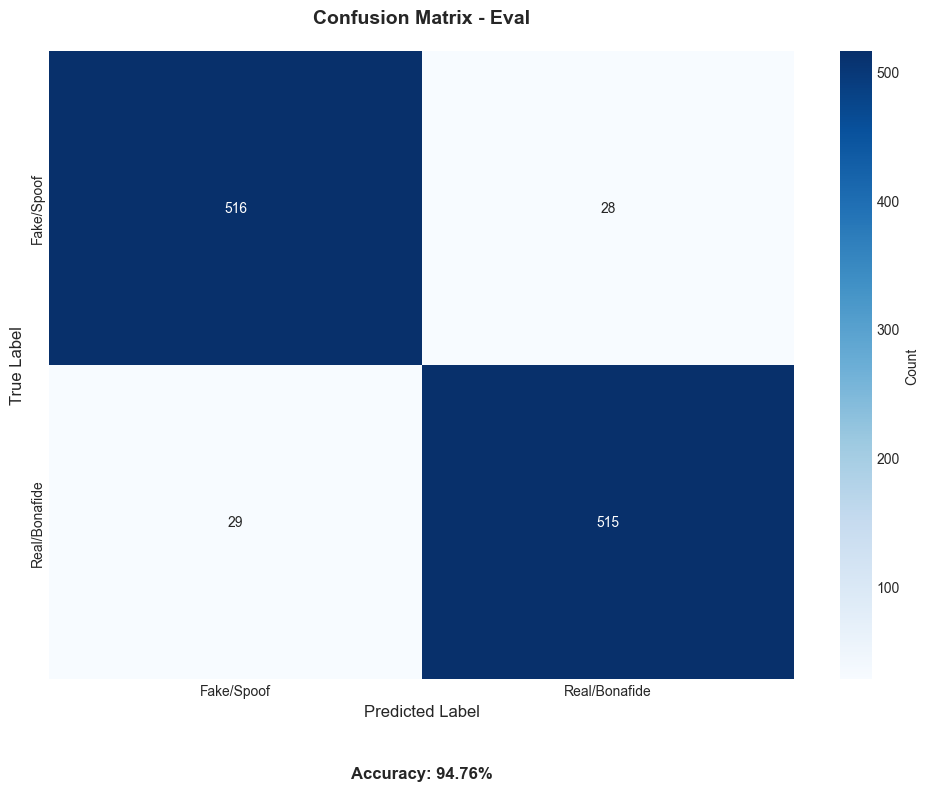

✓ ROC curve saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\roc_curve_eval.png


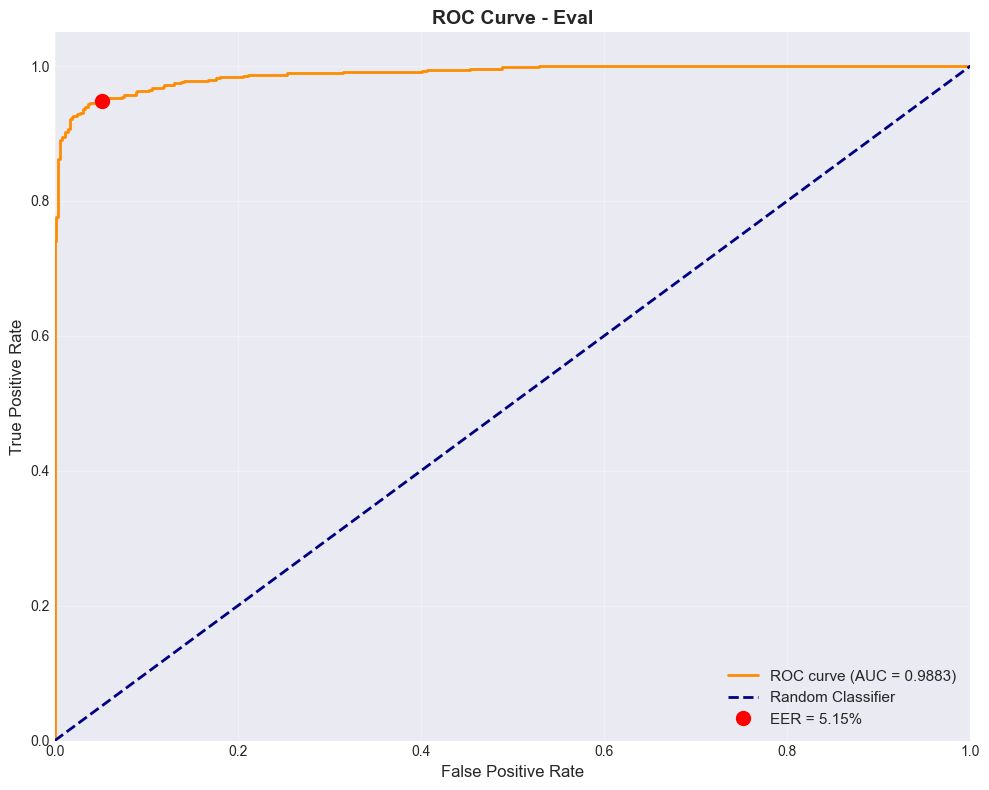


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9468    0.9485    0.9477       544
Real/Bonafide     0.9484    0.9467    0.9476       544

     accuracy                         0.9476      1088
    macro avg     0.9476    0.9476    0.9476      1088
 weighted avg     0.9476    0.9476    0.9476      1088

✓ Classification report saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 94.76%  |  ROC AUC: 0.9883  |  EER: 5.15%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          516           28
    Actual Real/Bonafide           29          515

--------------------------------------------------------

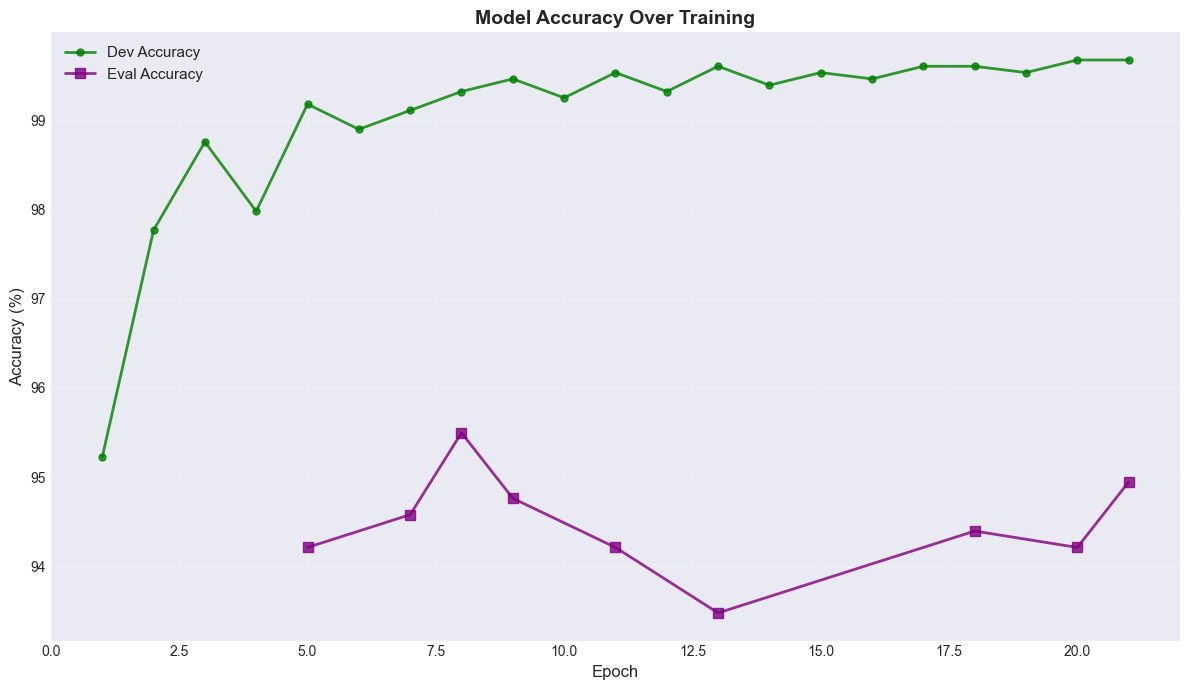


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.29820
  Final Loss:   0.06406
  Min Loss:     0.06130

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     0.2831%
  Best Dev Accuracy: 99.68%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       5.1471%
  ROC AUC:   0.9883
  Accuracy:  94.76%


[OK] Final summary saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 4.412, Accuracy: 94.76%


<Figure size 640x480 with 0 Axes>

In [11]:
%run    main.py --config config/LCNN.conf --feature_type 4 --dataset 2 --epochs 20 --random_noise --weight_avg --eval_best  

### Experiment 2: LCNN with LFCC Features

LFCC (Linear Frequency Cepstral Coefficients) is widely used for spoofing detection.



DATASET: Fake-or-Real (Type 2)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: 2 (LFCC)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
CuDNN Benchmark: Enabled
no. model params:444835
Memory Format: channels_last (optimized for CNNs)

TRAINING CONFIGURATION SUMMARY
  Model:            LCNN
  Dataset:          Fake-or-Real (Type 2)
  Feature:          lfcc (Type 2)
  Augmentation:     ✅ ENABLED
  Weight Avg (SWA): ✅ ENABLED
  Epochs:           20
  Batch Size:       32


Dataset loaded from: fake_or_real\for-2sec\for-2seconds
Training samples: 13956 (Real: 6

Training: 100%|█████████████| 436/436 [03:30<00:00,  2.07batch/s, loss=0.34572]



Validating on development set...


Evaluation: 100%|███████████████████████████| 89/89 [00:31<00:00,  2.83batch/s]


Scores saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\dev_score.txt
DONE.
Loss:0.34572, dev_eer: 6.582, dev_acc: 93.45%

Start training epoch 2/20


...

Evaluation: 100%|███████████████████████████| 89/89 [00:10<00:00,  8.49batch/s]


Scores saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\dev_score.txt
DONE.
Loss:0.10966, dev_eer: 0.354, dev_acc: 99.61%
Saving epoch 20 for SWA (weight averaging - late epoch)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 13 model snapshots


Evaluation: 100%|███████████████████████████| 34/34 [00:04<00:00,  7.93batch/s]


Scores saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\eval_scores_using_best_dev_model.txt

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZATIONS

[INFO] Collecting predictions for visualization...

[INFO] Development Set:


[INFO] Dev EER threshold: 0.0911

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\confusion_matrix_dev.png


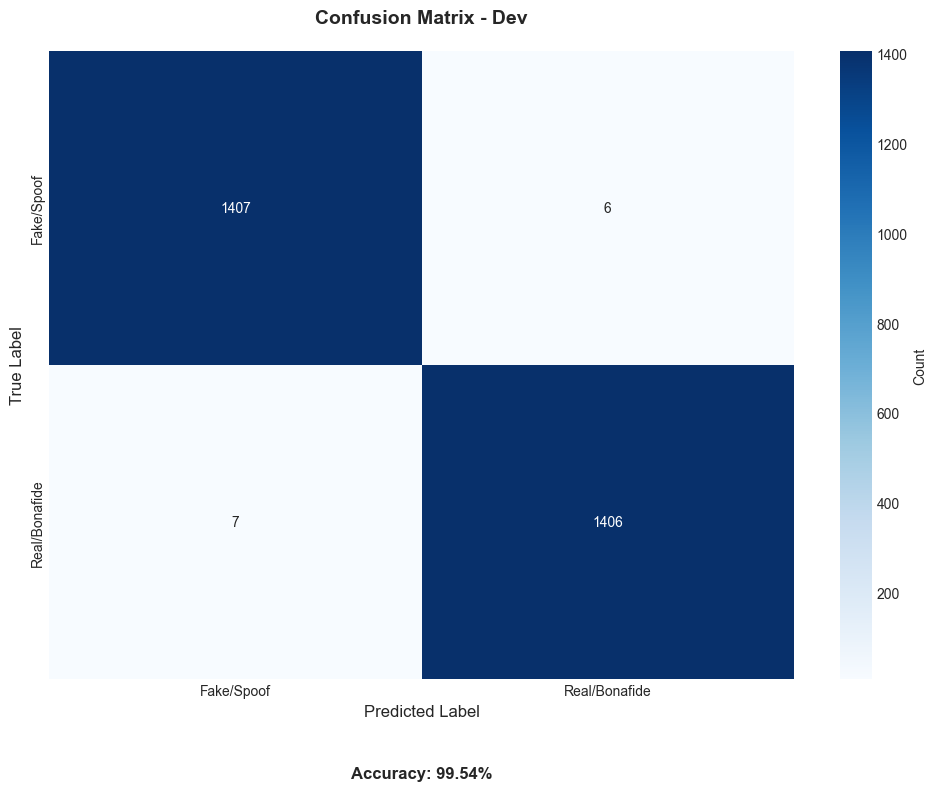

✓ ROC curve saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\roc_curve_dev.png


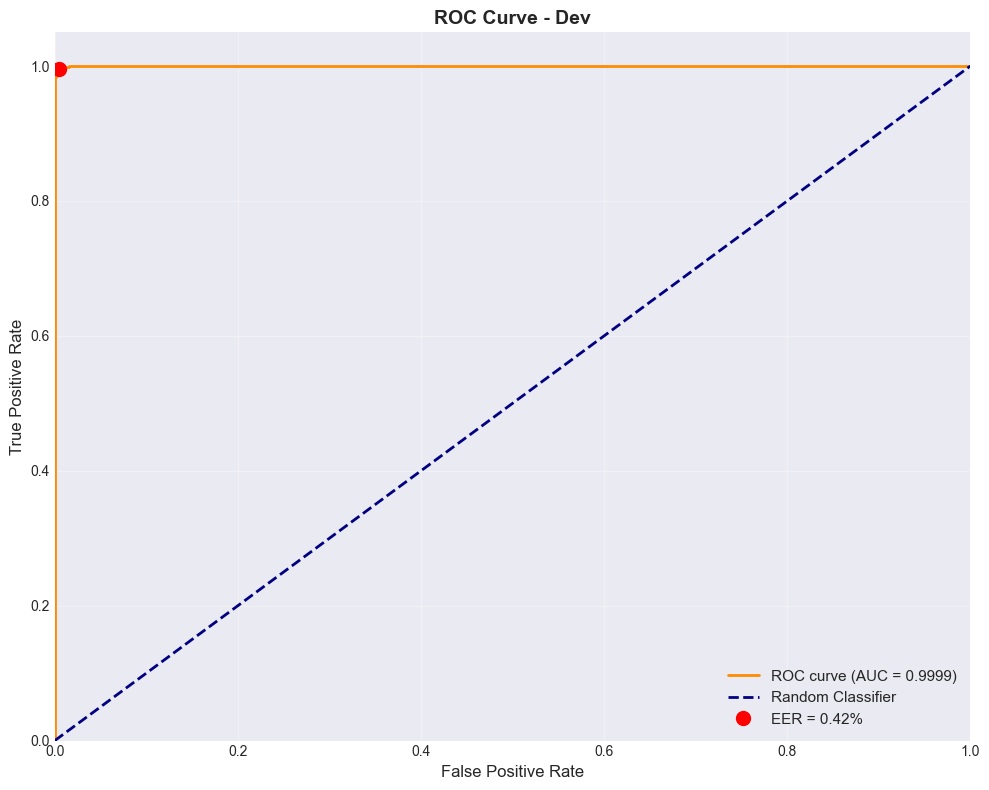


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9950    0.9958    0.9954      1413
Real/Bonafide     0.9958    0.9950    0.9954      1413

     accuracy                         0.9954      2826
    macro avg     0.9954    0.9954    0.9954      2826
 weighted avg     0.9954    0.9954    0.9954      2826

✓ Classification report saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 99.54%  |  ROC AUC: 0.9999  |  EER: 0.42%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1407            6
    Actual Real/Bonafide            7         1406

----------------------------------------------------------

[INFO] Eval EER threshold: 0.2067

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\confusion_matrix_eval.png


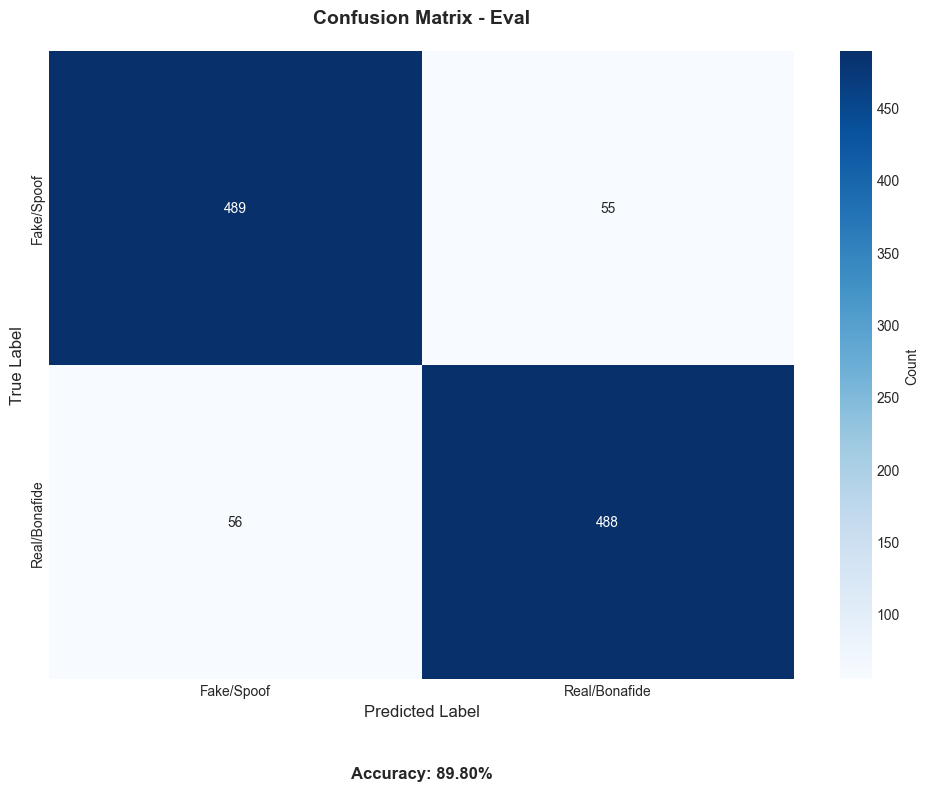

✓ ROC curve saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\roc_curve_eval.png


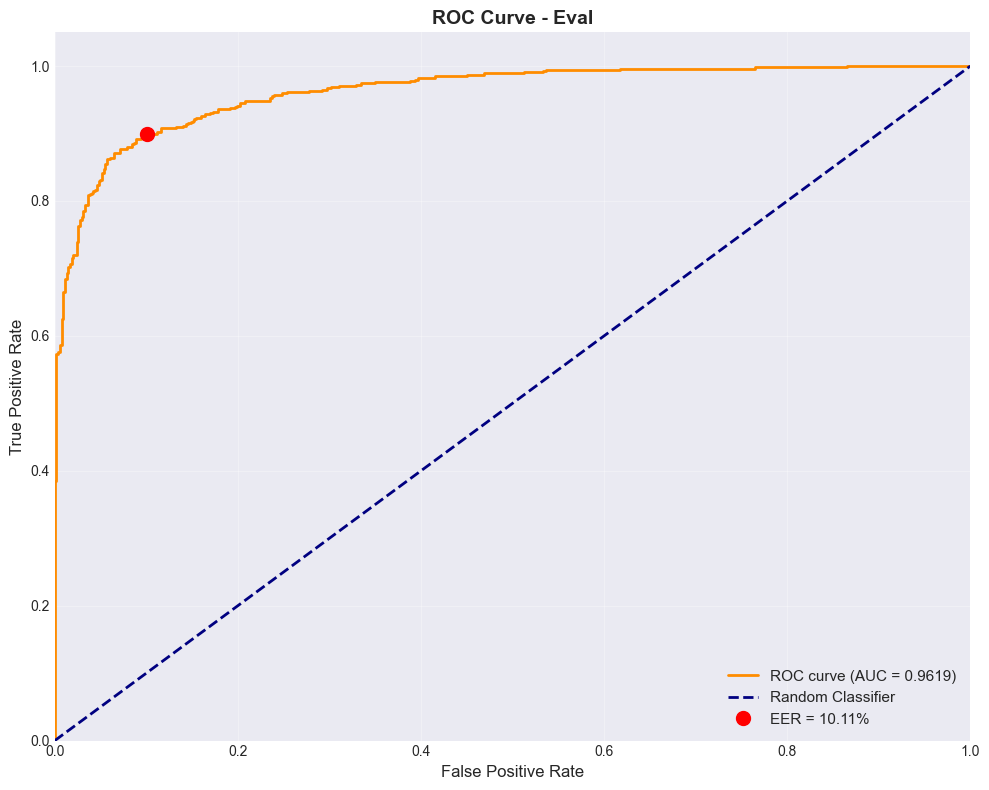


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.8972    0.8989    0.8981       544
Real/Bonafide     0.8987    0.8971    0.8979       544

     accuracy                         0.8980      1088
    macro avg     0.8980    0.8980    0.8980      1088
 weighted avg     0.8980    0.8980    0.8980      1088

✓ Classification report saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 89.80%  |  ROC AUC: 0.9619  |  EER: 10.11%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          489           55
    Actual Real/Bonafide           56          488

-------------------------------------------------------

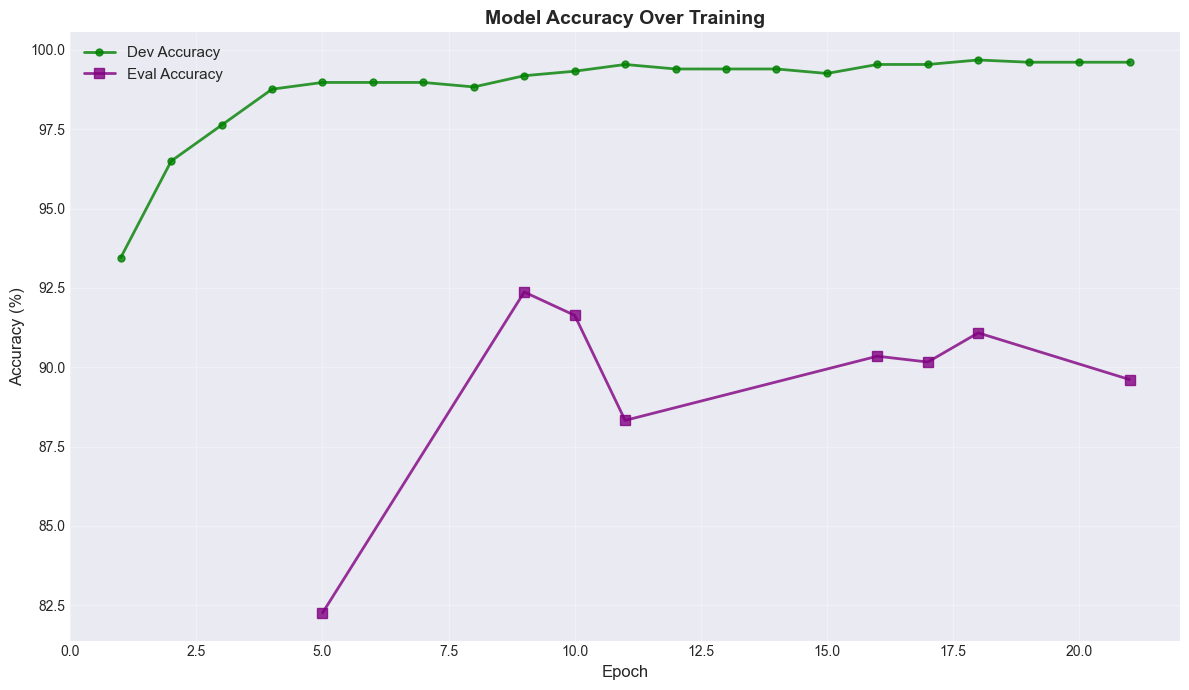


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.34572
  Final Loss:   0.10966
  Min Loss:     0.10834

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     0.2831%
  Best Dev Accuracy: 99.68%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       10.1103%
  ROC AUC:   0.9619
  Accuracy:  89.80%


[OK] Final summary saved to exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 7.537, Accuracy: 89.80%


In [1]:
%run    main.py --config config/LCNN.conf --feature_type 2 --dataset 2 --epochs 20 --random_noise --weight_avg --eval_best  

### Experiment 3: EfficientNet-B2 with CQT Features

EfficientNet with CQT can capture fine-grained frequency patterns.



DATASET: Fake-or-Real (Type 2)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: 4 (CQT)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
CuDNN Benchmark: Enabled
no. model params:10865581
Memory Format: channels_last (optimized for CNNs)

TRAINING CONFIGURATION SUMMARY
  Model:            EfficientNetB2
  Dataset:          Fake-or-Real (Type 2)
  Feature:          cqt (Type 4)
  Augmentation:     ✅ ENABLED
  Weight Avg (SWA): ✅ ENABLED
  Epochs:           20
  Batch Size:       24


Dataset loaded from: fake_or_real\for-2sec\for-2seconds
Training samples: 1395

Training: 100%|█████████████| 581/581 [09:51<00:00,  1.02s/batch, loss=0.42799]



Validating on development set...


Evaluation: 100%|█████████████████████████| 118/118 [01:49<00:00,  1.07batch/s]


Scores saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\dev_score.txt
DONE.
Loss:0.42799, dev_eer: 4.105, dev_acc: 95.86%

Start training epoch 2/20


...

Evaluation: 100%|███████████████████████████| 46/46 [00:27<00:00,  1.67batch/s]


Scores saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\eval_scores_using_best_dev_model.txt
epoch020, 
Saving epoch 20 for SWA (weight averaging - best model)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 15 model snapshots


Evaluation: 100%|███████████████████████████| 46/46 [00:26<00:00,  1.70batch/s]


Scores saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\eval_scores_using_best_dev_model.txt

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZATIONS

[INFO] Collecting predictions for visualization...

[INFO] Development Set:


[INFO] Dev EER threshold: 0.2171

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\confusion_matrix_dev.png


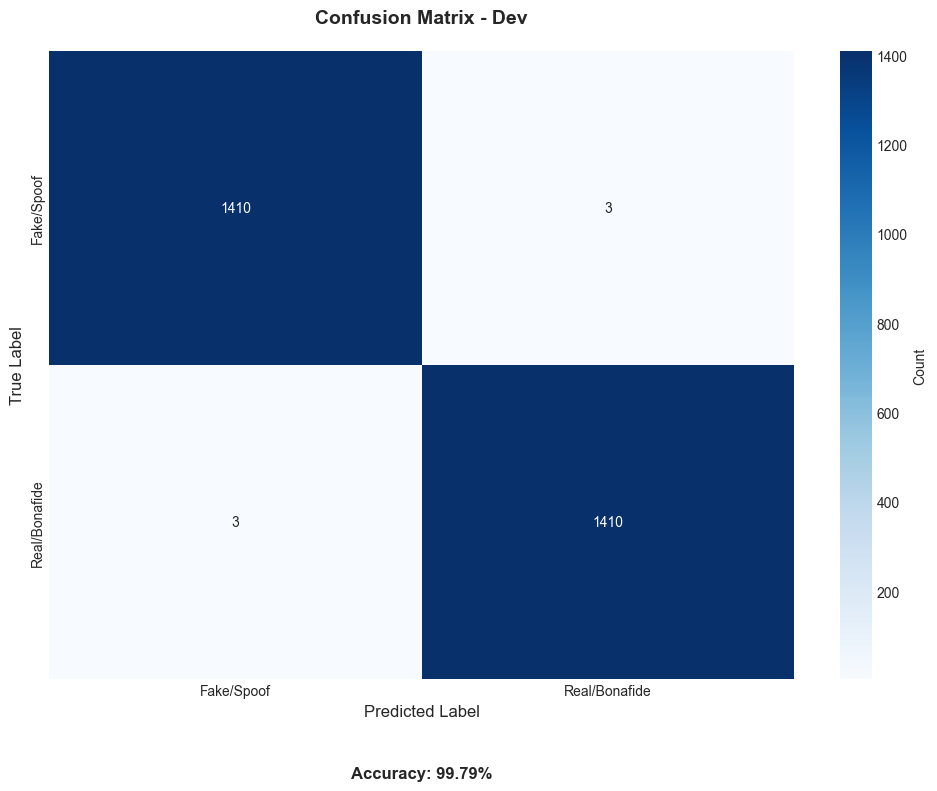

✓ ROC curve saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\roc_curve_dev.png


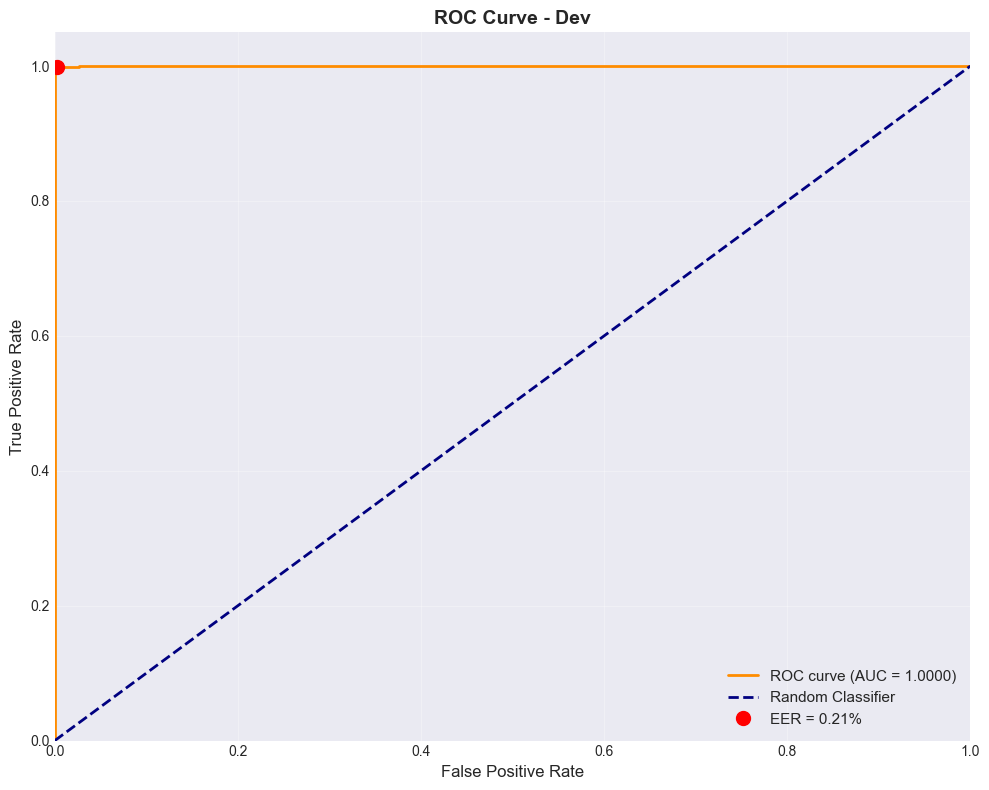


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9979    0.9979    0.9979      1413
Real/Bonafide     0.9979    0.9979    0.9979      1413

     accuracy                         0.9979      2826
    macro avg     0.9979    0.9979    0.9979      2826
 weighted avg     0.9979    0.9979    0.9979      2826

✓ Classification report saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 99.79%  |  ROC AUC: 1.0000  |  EER: 0.21%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1410            3
    Actual Real/Bonafide            3         1410

--------------------------------------

[INFO] Eval EER threshold: 3.5390

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\confusion_matrix_eval.png


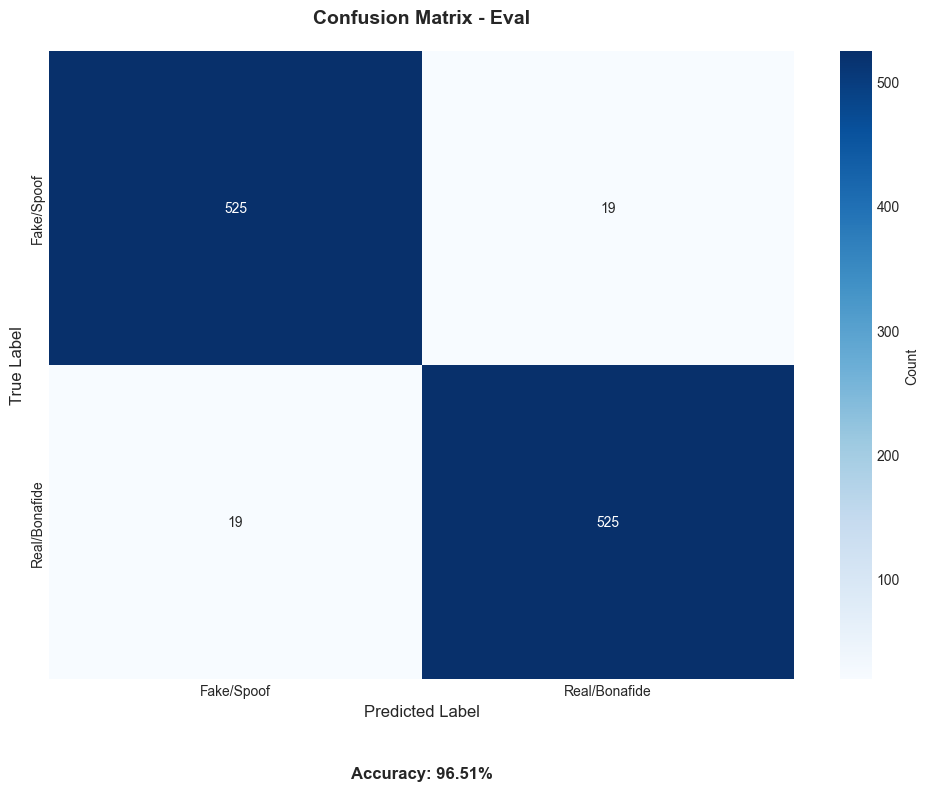

✓ ROC curve saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\roc_curve_eval.png


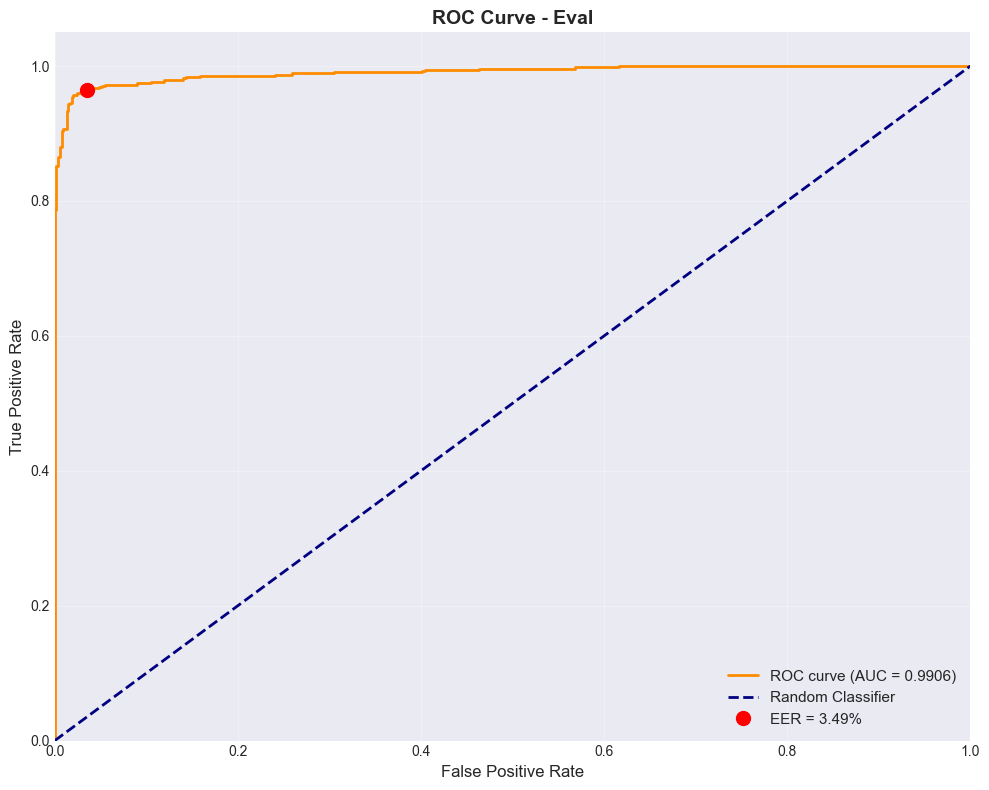


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9651    0.9651    0.9651       544
Real/Bonafide     0.9651    0.9651    0.9651       544

     accuracy                         0.9651      1088
    macro avg     0.9651    0.9651    0.9651      1088
 weighted avg     0.9651    0.9651    0.9651      1088

✓ Classification report saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 96.51%  |  ROC AUC: 0.9906  |  EER: 3.49%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          525           19
    Actual Real/Bonafide           19          525

------------------------------------

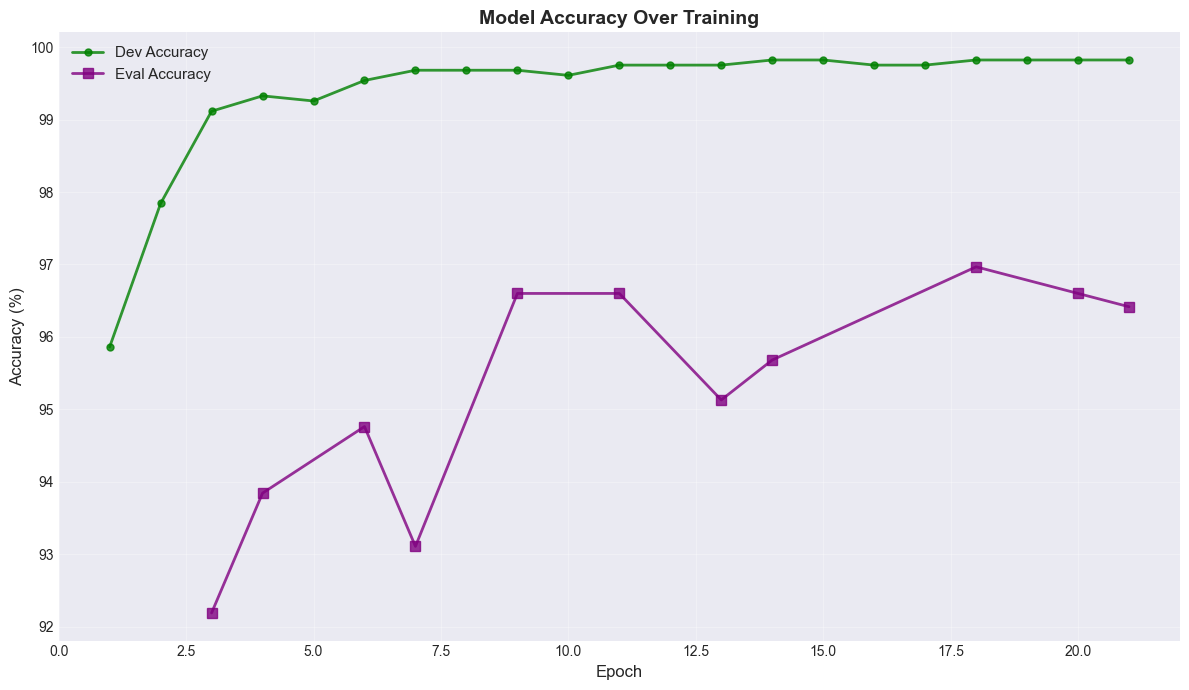


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.42799
  Final Loss:   0.04387
  Min Loss:     0.04387

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     0.1415%
  Best Dev Accuracy: 99.82%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       3.4926%
  ROC AUC:   0.9906
  Accuracy:  96.51%


[OK] Final summary saved to exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 2.941, Accuracy: 96.51%


In [1]:
%run    main.py --config config/EfficientNetB2_Attention.conf --feature_type 4 --dataset 2 --epochs 20 --random_noise --weight_avg --eval_best  

### Experiment 4: SEResNet with MFCC Features

SEResNet with MFCC for traditional speech feature analysis.



DATASET: Fake-or-Real (Type 2)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: 3 (MFCC)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
CuDNN Benchmark: Enabled
no. model params:11981251
Memory Format: channels_last (optimized for CNNs)

TRAINING CONFIGURATION SUMMARY
  Model:            SEResNet
  Dataset:          Fake-or-Real (Type 2)
  Feature:          mfcc (Type 3)
  Augmentation:     ✅ ENABLED
  Weight Avg (SWA): ✅ ENABLED
  Epochs:           15
  Batch Size:       32


Dataset loaded from: fake_or_real\for-2sec\for-2seconds
Training samples: 13956 (R

Training: 100%|█████████████| 436/436 [01:51<00:00,  3.93batch/s, loss=0.36034]



Validating on development set...


Evaluation: 100%|███████████████████████████| 89/89 [00:13<00:00,  6.81batch/s]


Scores saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\dev_score.txt
DONE.
Loss:0.36034, dev_eer: 14.508, dev_acc: 85.46%

Start training epoch 2/15


...

Evaluation: 100%|███████████████████████████| 89/89 [00:13<00:00,  6.78batch/s]


Scores saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\dev_score.txt
DONE.
Loss:0.08991, dev_eer: 0.566, dev_acc: 99.40%
Saving epoch 15 for SWA (weight averaging - late epoch)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 8 model snapshots


Evaluation: 100%|███████████████████████████| 34/34 [00:05<00:00,  6.78batch/s]


Scores saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\eval_scores_using_best_dev_model.txt

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZATIONS

[INFO] Collecting predictions for visualization...

[INFO] Development Set:


[INFO] Dev EER threshold: 0.4088

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\confusion_matrix_dev.png


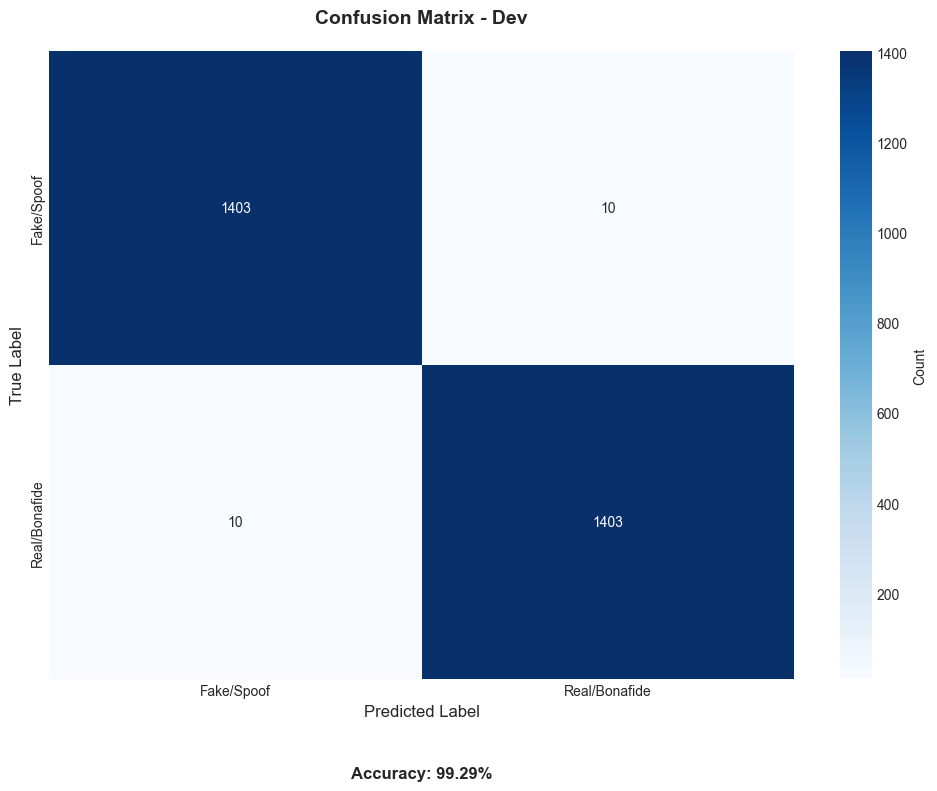

✓ ROC curve saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\roc_curve_dev.png


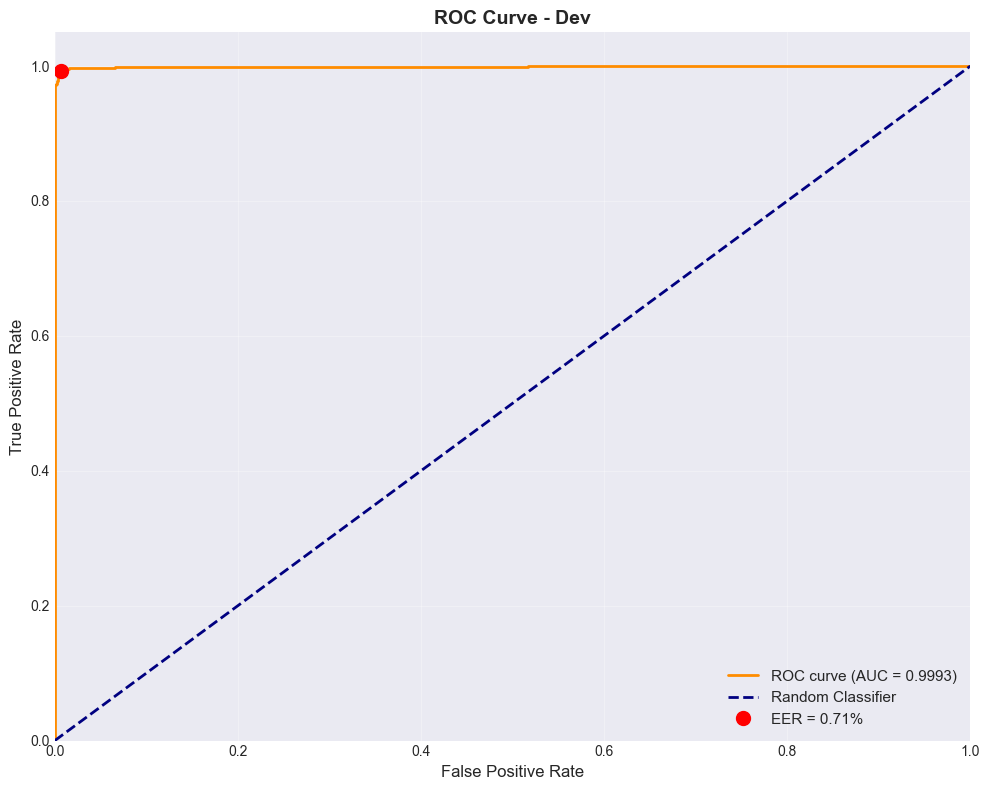


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9929    0.9929    0.9929      1413
Real/Bonafide     0.9929    0.9929    0.9929      1413

     accuracy                         0.9929      2826
    macro avg     0.9929    0.9929    0.9929      2826
 weighted avg     0.9929    0.9929    0.9929      2826

✓ Classification report saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 99.29%  |  ROC AUC: 0.9993  |  EER: 0.71%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1403           10
    Actual Real/Bonafide           10         1403

------------------------------------------------------

[INFO] Eval EER threshold: 0.5561

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\confusion_matrix_eval.png


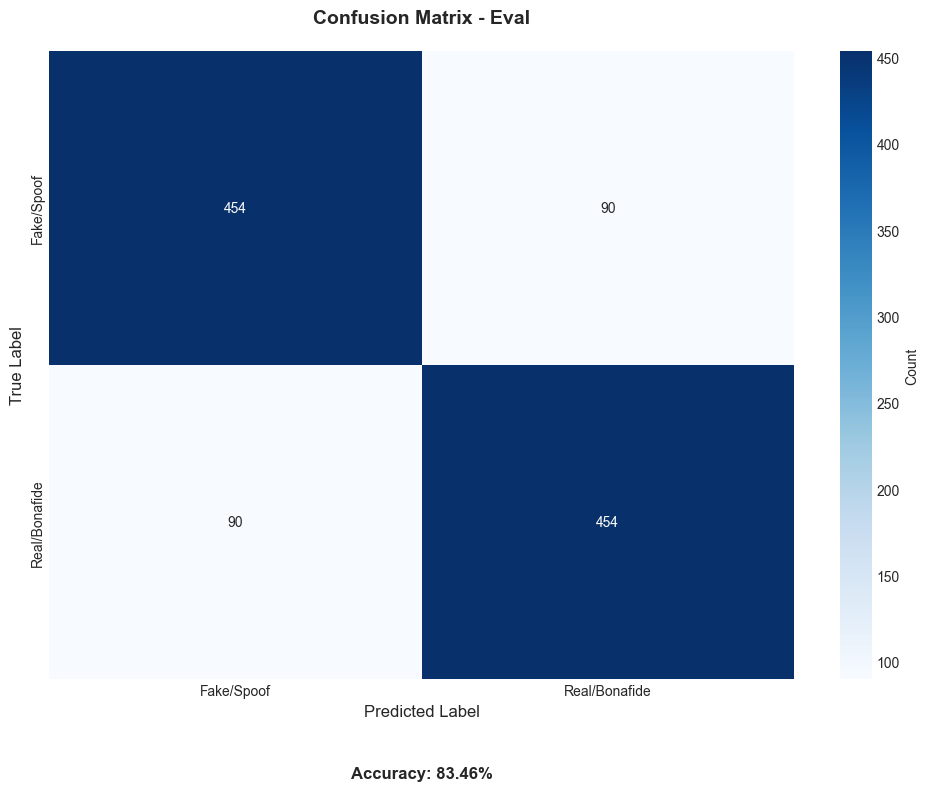

✓ ROC curve saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\roc_curve_eval.png


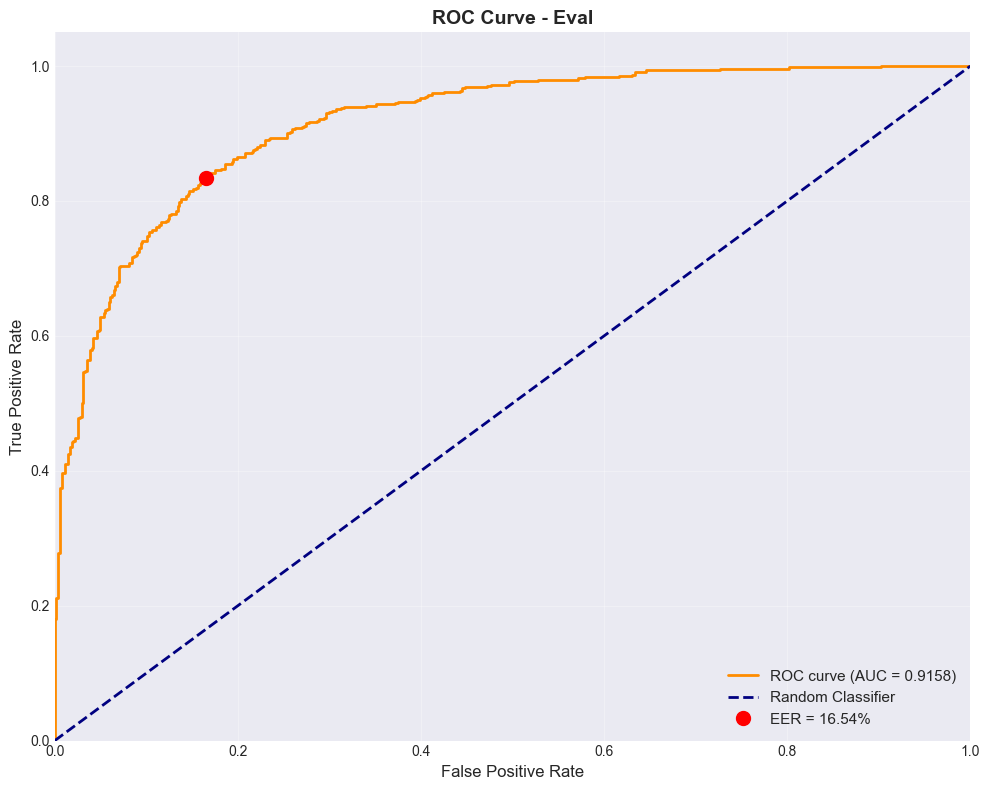


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.8346    0.8346    0.8346       544
Real/Bonafide     0.8346    0.8346    0.8346       544

     accuracy                         0.8346      1088
    macro avg     0.8346    0.8346    0.8346      1088
 weighted avg     0.8346    0.8346    0.8346      1088

✓ Classification report saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 83.46%  |  ROC AUC: 0.9158  |  EER: 16.54%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          454           90
    Actual Real/Bonafide           90          454

---------------------------------------------------

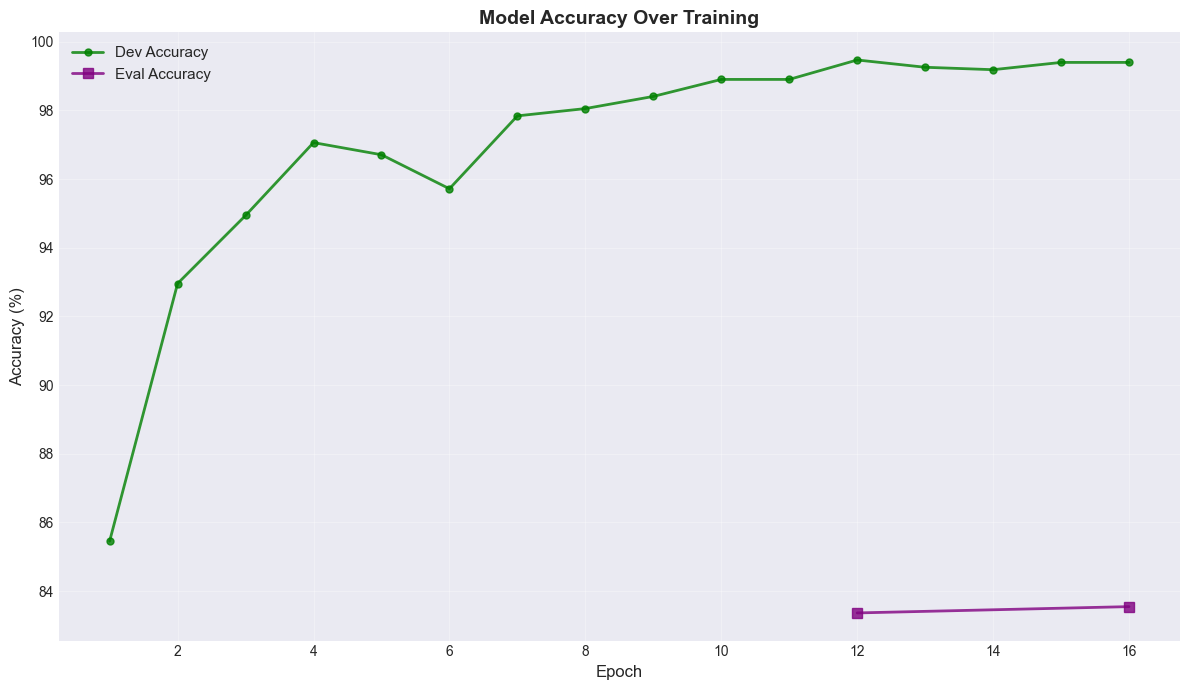


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.36034
  Final Loss:   0.08991
  Min Loss:     0.08991

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     0.4954%
  Best Dev Accuracy: 99.47%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       16.5441%
  ROC AUC:   0.9158
  Accuracy:  83.46%


[OK] Final summary saved to exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat3\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 16.544, Accuracy: 83.46%


<Figure size 640x480 with 0 Axes>

In [2]:
%run    main.py --config config/SEResNet.conf --feature_type 3 --dataset 2 --epochs 15 --random_noise --weight_avg --eval_best 


DATASET: Fake-or-Real (Type 2)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: 0 (RAW)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
no. model params:42338
Memory Format: channels_last (optimized for CNNs)

TRAINING CONFIGURATION SUMMARY
  Model:            SimpleCNN
  Dataset:          Fake-or-Real (Type 2)
  Feature:          raw (Type 0)
  Augmentation:     ✅ ENABLED
  Weight Avg (SWA): ✅ ENABLED
  Epochs:           25
  Batch Size:       24


Dataset loaded from: fake_or_real\for-2sec\for-2seconds
Training samples: 13956 (Real: 6978, Fake: 6978)
Valida

Training: 100%|█████████████| 581/581 [01:08<00:00,  8.50batch/s, loss=0.34055]



Validating on development set...


Evaluation: 100%|█████████████████████████| 118/118 [00:02<00:00, 45.37batch/s]


Scores saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\dev_score.txt
DONE.
Loss:0.34055, dev_eer: 16.631, dev_acc: 83.33%

Start training epoch 2/25


...

Evaluation: 100%|█████████████████████████| 118/118 [00:03<00:00, 32.95batch/s]


Scores saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\dev_score.txt
DONE.
Loss:0.14699, dev_eer: 4.105, dev_acc: 95.93%
Saving epoch 25 for SWA (weight averaging - late epoch)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 13 model snapshots


Evaluation: 100%|███████████████████████████| 46/46 [00:02<00:00, 21.29batch/s]


Scores saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\eval_scores_using_best_dev_model.txt

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZATIONS

[INFO] Collecting predictions for visualization...

[INFO] Development Set:


[INFO] Dev EER threshold: 0.9001

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\confusion_matrix_dev.png


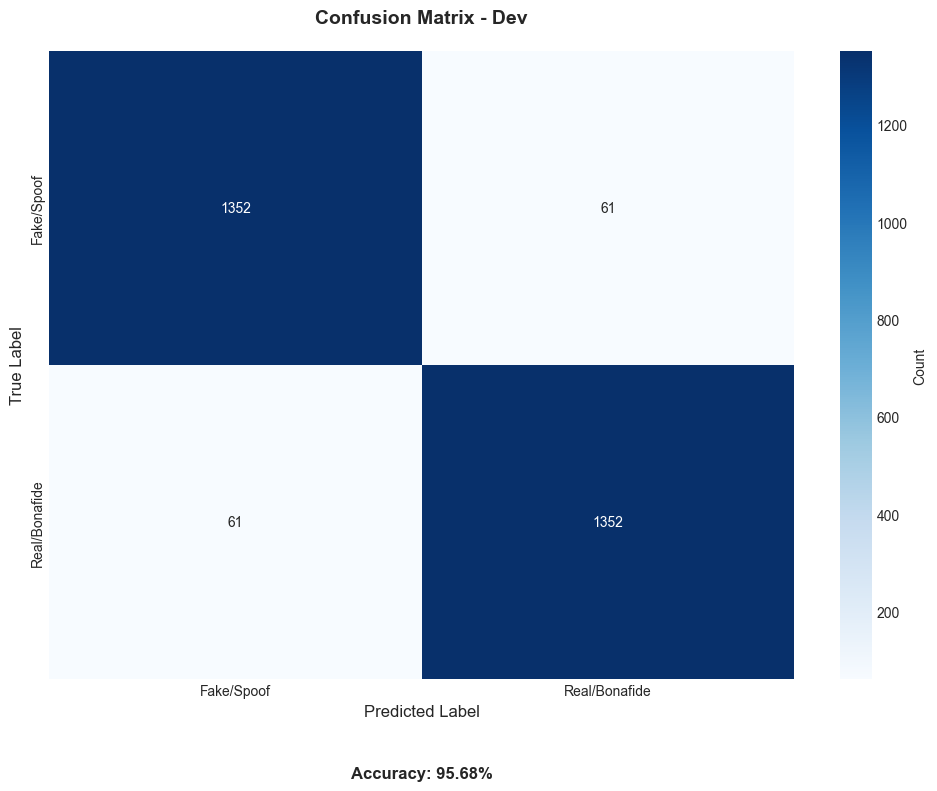

✓ ROC curve saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\roc_curve_dev.png


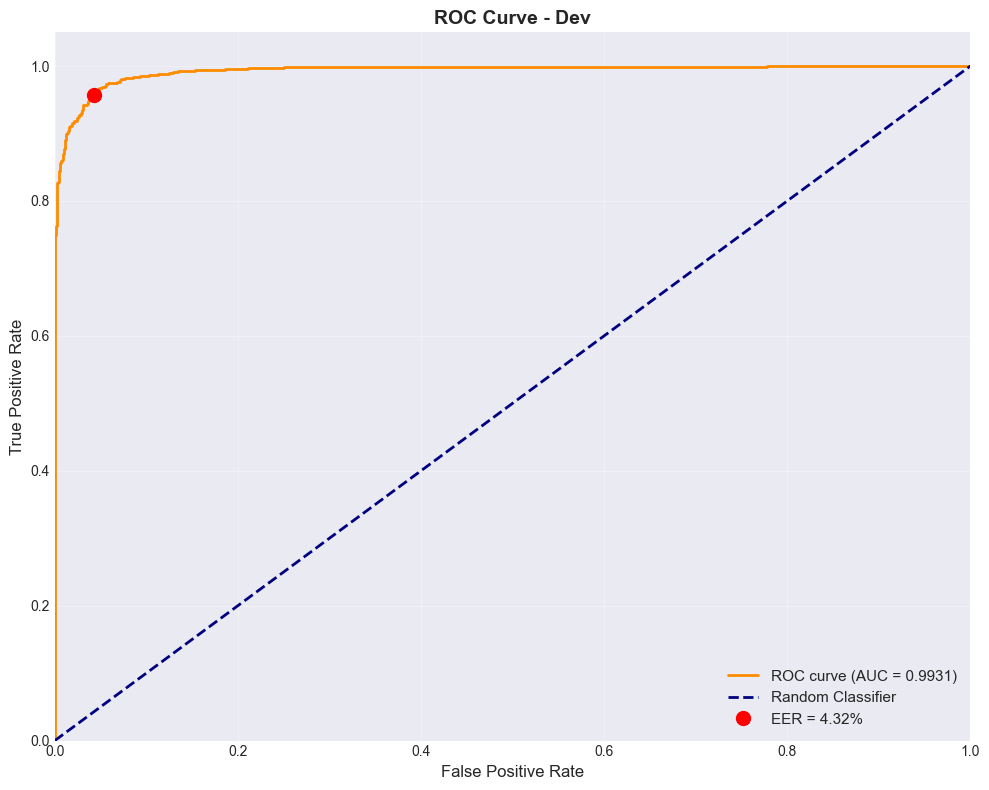


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9568    0.9568    0.9568      1413
Real/Bonafide     0.9568    0.9568    0.9568      1413

     accuracy                         0.9568      2826
    macro avg     0.9568    0.9568    0.9568      2826
 weighted avg     0.9568    0.9568    0.9568      2826

✓ Classification report saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 95.68%  |  ROC AUC: 0.9931  |  EER: 4.32%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1352           61
    Actual Real/Bonafide           61         1352

-----------------------------------------------------

[INFO] Eval EER threshold: 2.7735

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\confusion_matrix_eval.png


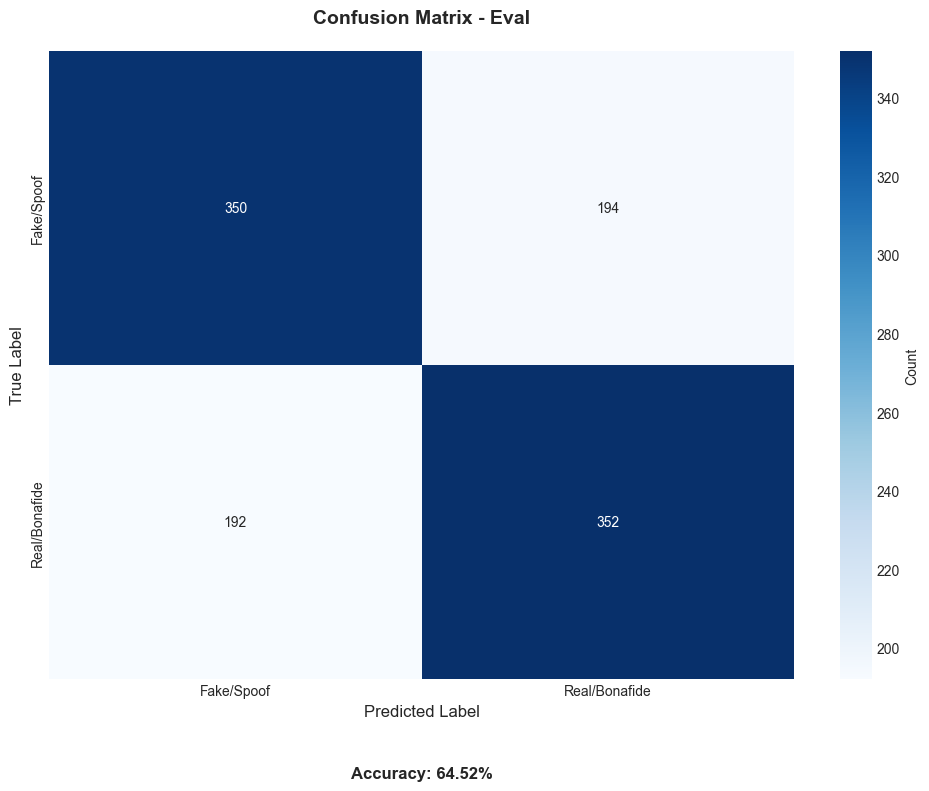

✓ ROC curve saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\roc_curve_eval.png


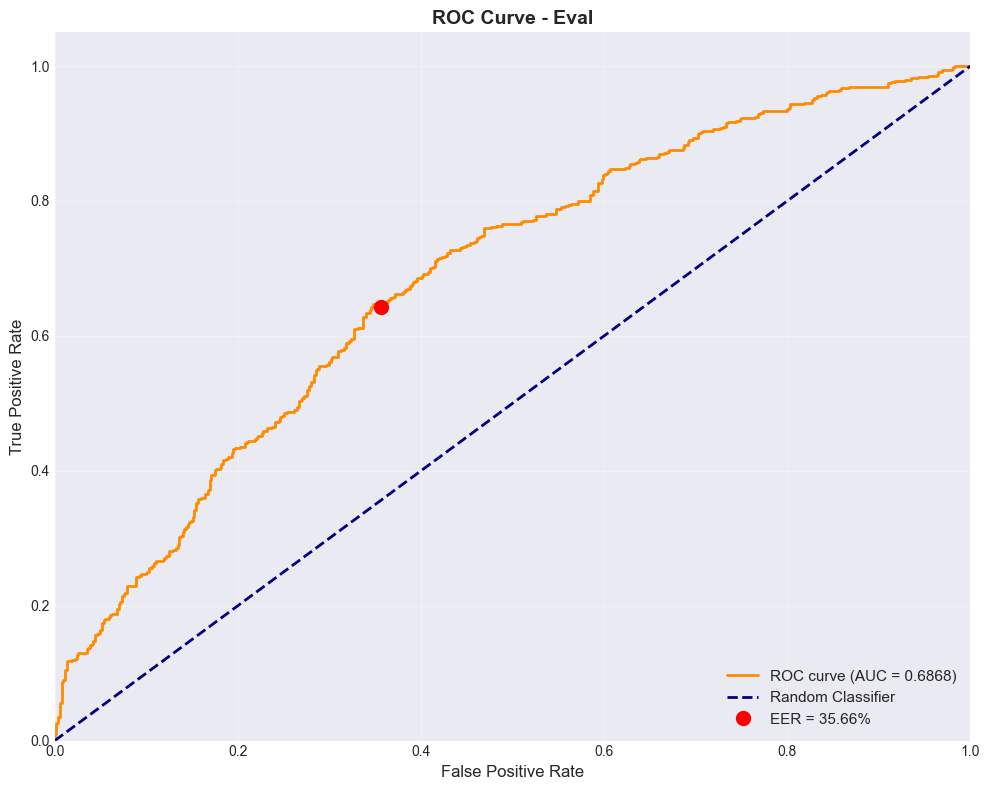


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.6458    0.6434    0.6446       544
Real/Bonafide     0.6447    0.6471    0.6459       544

     accuracy                         0.6452      1088
    macro avg     0.6452    0.6452    0.6452      1088
 weighted avg     0.6452    0.6452    0.6452      1088

✓ Classification report saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 64.52%  |  ROC AUC: 0.6868  |  EER: 35.66%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          350          194
    Actual Real/Bonafide          192          352

--------------------------------------------------

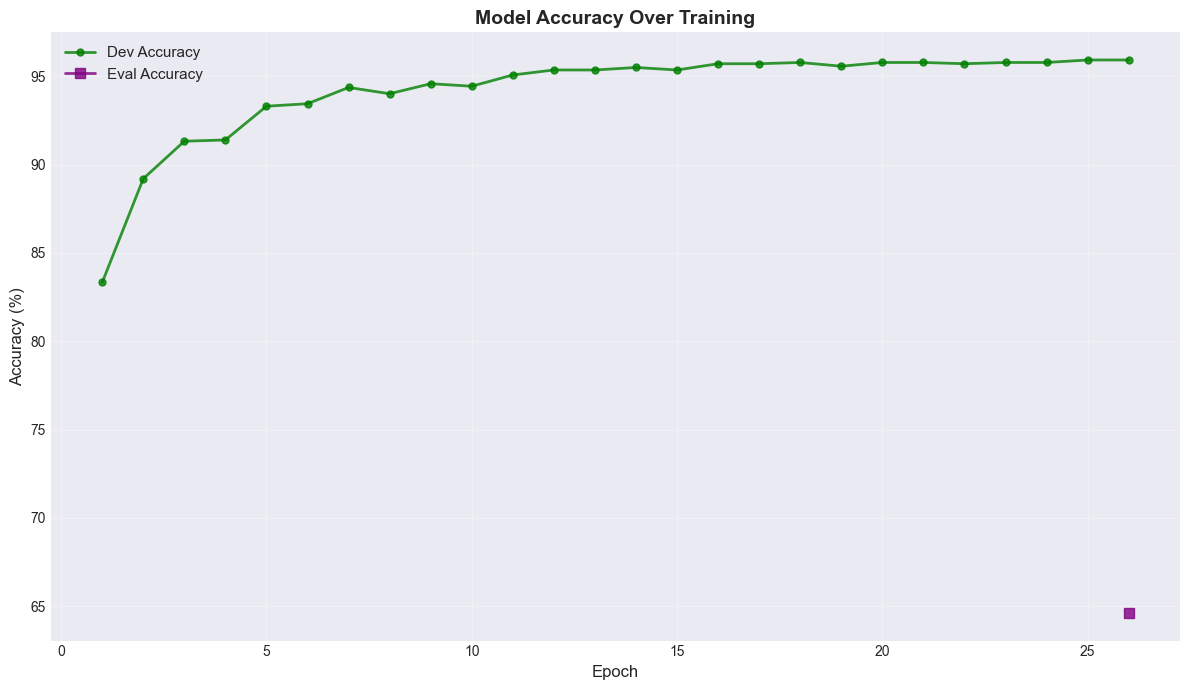


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.34055
  Final Loss:   0.14699
  Min Loss:     0.14699

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     4.1047%
  Best Dev Accuracy: 95.93%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       35.6618%
  ROC AUC:   0.6868
  Accuracy:  64.52%


[OK] Final summary saved to exp_result\FakeorReal_audio_SimpleCNN_rand_ep25_bs24_feat0\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 35.294, Accuracy: 64.52%


<Figure size 640x480 with 0 Axes>

In [7]:
%run    main.py --config config/SimpleCNN.conf --feature_type 0 --dataset 2 --epochs 25 --random_noise --weight_avg --eval_best  

### Experiment 7: LCNN Large with LFCC Features

Larger LCNN model with LFCC for better spoofing artifact detection.



DATASET: Fake-or-Real (Type 2)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: 2 (LFCC)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
CuDNN Benchmark: Enabled
no. model params:1901635
Memory Format: channels_last (optimized for CNNs)

TRAINING CONFIGURATION SUMMARY
  Model:            LCNN
  Dataset:          Fake-or-Real (Type 2)
  Feature:          lfcc (Type 2)
  Augmentation:     ✅ ENABLED
  Weight Avg (SWA): ✅ ENABLED
  Epochs:           20
  Batch Size:       24


Dataset loaded from: fake_or_real\for-2sec\for-2seconds
Training samples: 13956 (Real: 

Training: 100%|█████████████| 581/581 [01:50<00:00,  5.28batch/s, loss=0.53011]



Validating on development set...


Evaluation: 100%|█████████████████████████| 118/118 [00:11<00:00, 10.34batch/s]


Scores saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\dev_score.txt
DONE.
Loss:0.53011, dev_eer: 7.714, dev_acc: 92.25%

Start training epoch 2/20


...

Evaluation: 100%|███████████████████████████| 46/46 [00:04<00:00, 10.45batch/s]


Scores saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\eval_scores_using_best_dev_model.txt
epoch020, 
Saving epoch 20 for SWA (weight averaging - best model)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 10 model snapshots


Evaluation: 100%|███████████████████████████| 46/46 [00:03<00:00, 11.55batch/s]


Scores saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\eval_scores_using_best_dev_model.txt

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZATIONS

[INFO] Collecting predictions for visualization...

[INFO] Development Set:


[INFO] Dev EER threshold: 0.6357

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\confusion_matrix_dev.png


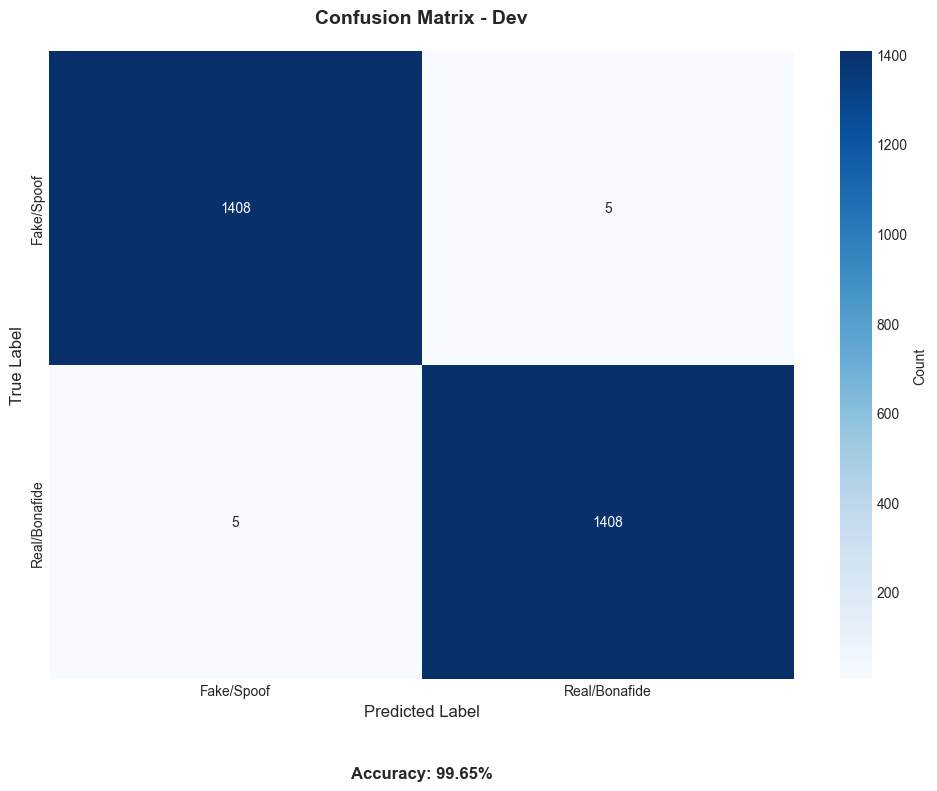

✓ ROC curve saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\roc_curve_dev.png


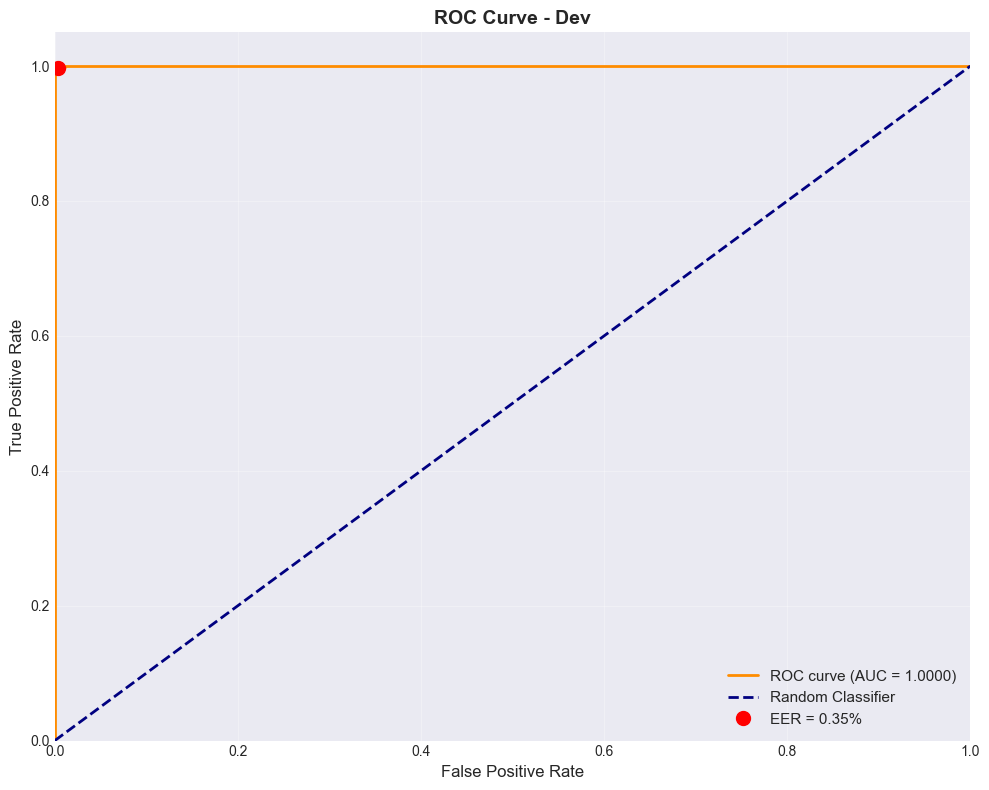


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9965    0.9965    0.9965      1413
Real/Bonafide     0.9965    0.9965    0.9965      1413

     accuracy                         0.9965      2826
    macro avg     0.9965    0.9965    0.9965      2826
 weighted avg     0.9965    0.9965    0.9965      2826

✓ Classification report saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 99.65%  |  ROC AUC: 1.0000  |  EER: 0.35%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1408            5
    Actual Real/Bonafide            5         1408

----------------------------------------------------

[INFO] Eval EER threshold: 0.4703

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\confusion_matrix_eval.png


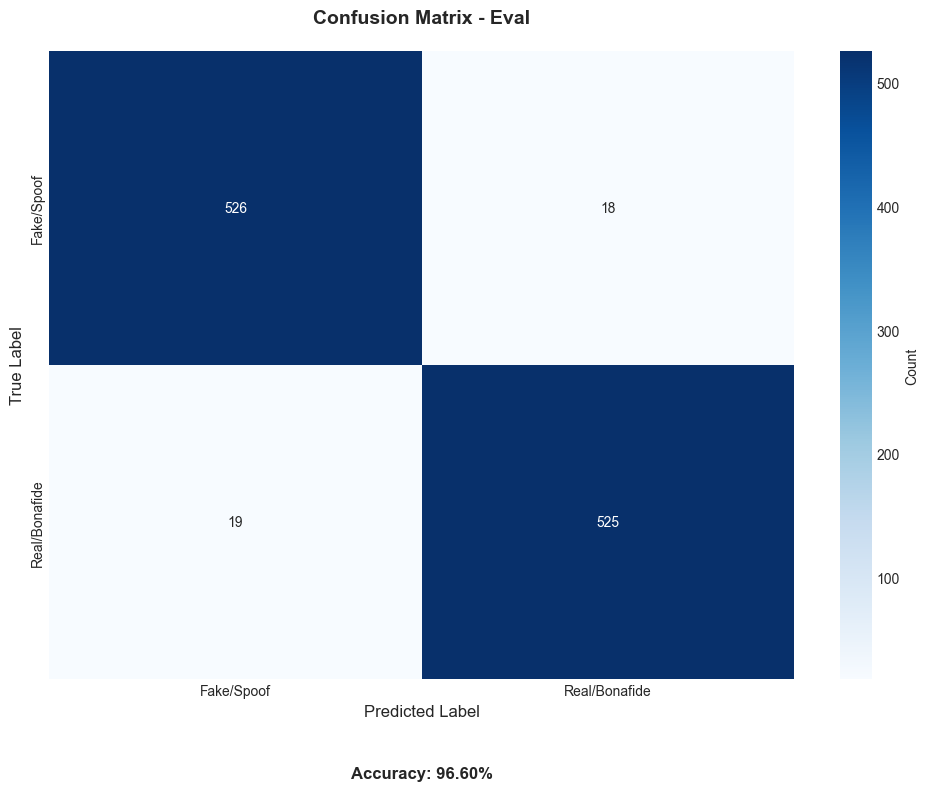

✓ ROC curve saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\roc_curve_eval.png


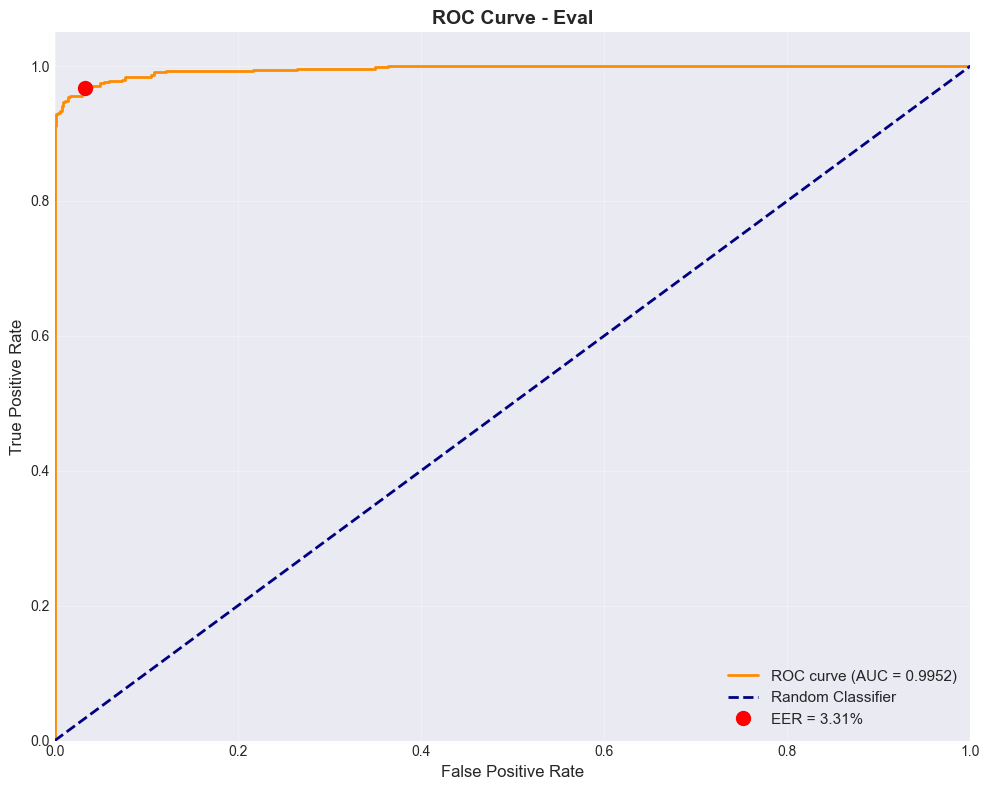


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9651    0.9669    0.9660       544
Real/Bonafide     0.9669    0.9651    0.9660       544

     accuracy                         0.9660      1088
    macro avg     0.9660    0.9660    0.9660      1088
 weighted avg     0.9660    0.9660    0.9660      1088

✓ Classification report saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 96.60%  |  ROC AUC: 0.9952  |  EER: 3.31%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          526           18
    Actual Real/Bonafide           19          525

--------------------------------------------------

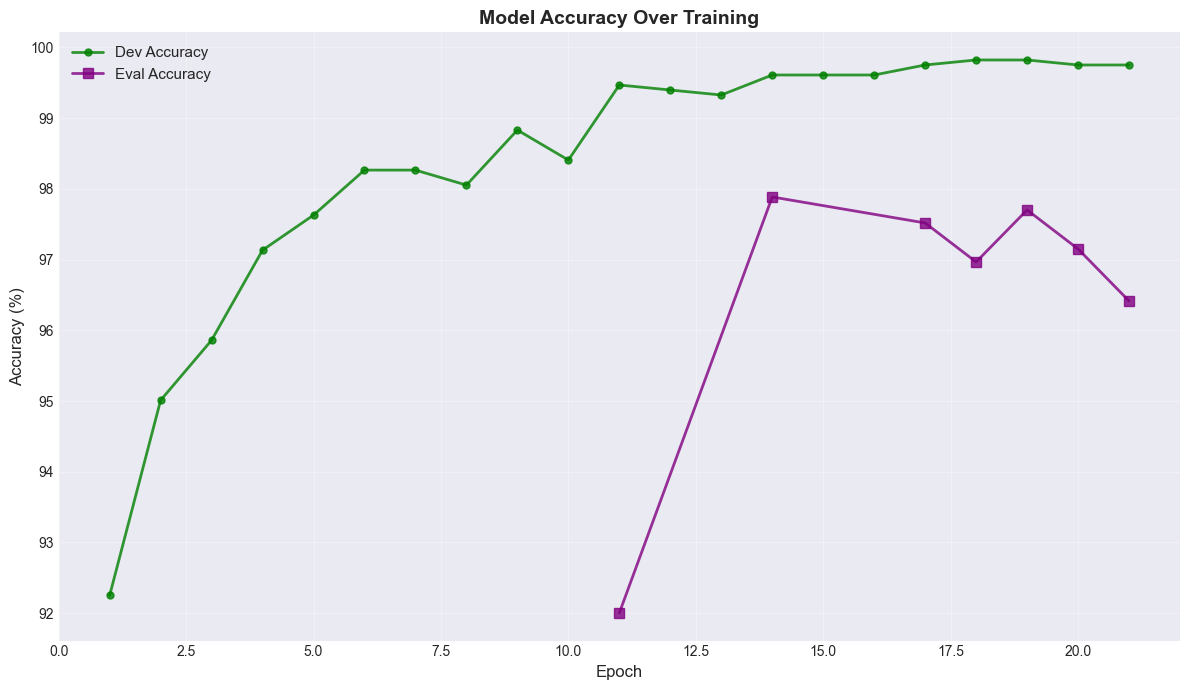


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.53011
  Final Loss:   0.10420
  Min Loss:     0.10420

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     0.2123%
  Best Dev Accuracy: 99.82%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       3.3088%
  ROC AUC:   0.9952
  Accuracy:  96.60%


[OK] Final summary saved to exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 2.022, Accuracy: 96.60%


<Figure size 640x480 with 0 Axes>

In [4]:
%run    main.py --config config/LCNN_Large.conf --feature_type 2 --dataset 2 --epochs 20 --random_noise --weight_avg --eval_best   

---

## 📈 Step 7: Compare All Results

After running experiments, visualize and compare all model results.



✓ Found 11 path(s)
✓ Loaded metrics from exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\metrics\metrics.json
✓ Loaded metrics from exp_result\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\metrics\metrics.json
✓ Loaded metrics from exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\metrics\metrics.json
✓ Loaded metrics from exp_result\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\metrics\metrics.json
✓ Loaded metrics from exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\metrics\metrics.json
✓ Loaded metrics from exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\metrics\metrics.json
✓ Loaded metrics from exp_result\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\metrics\metrics.json
✓ Loaded metrics from exp_result\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\metrics\metrics.json
✓ Loaded metrics from exp_result\FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1\metrics\metrics.json
✓ Loaded metrics from exp_result\FakeorReal_audio

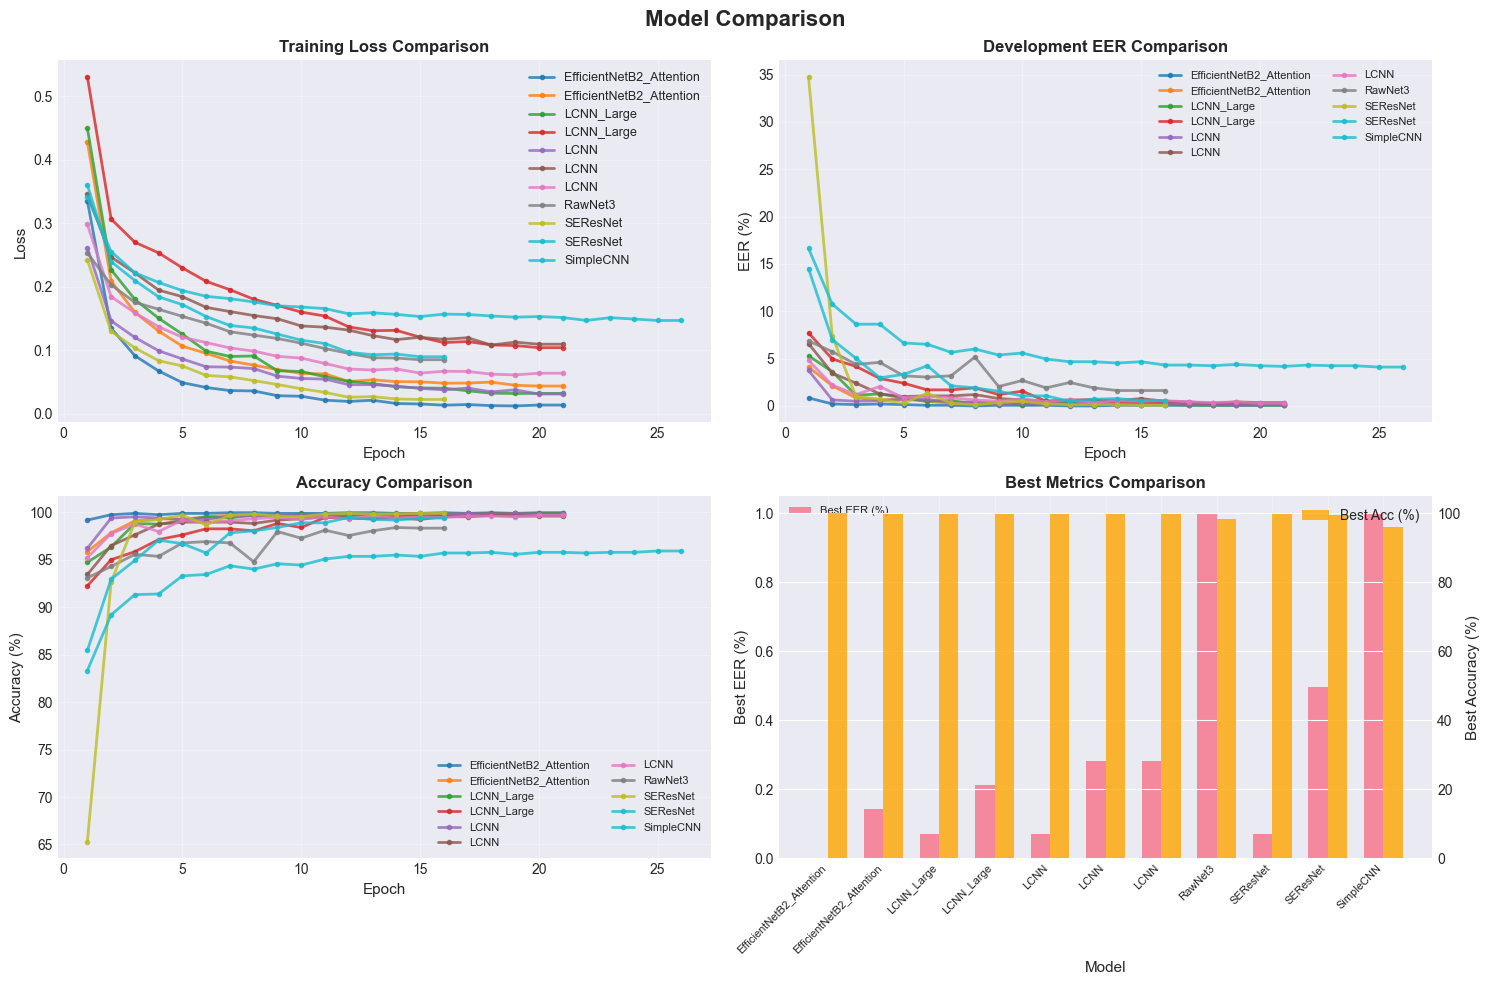


📈 Generating visualizations for: FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1
✓ Saved training curves to comparison_plots\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\training_curves.png


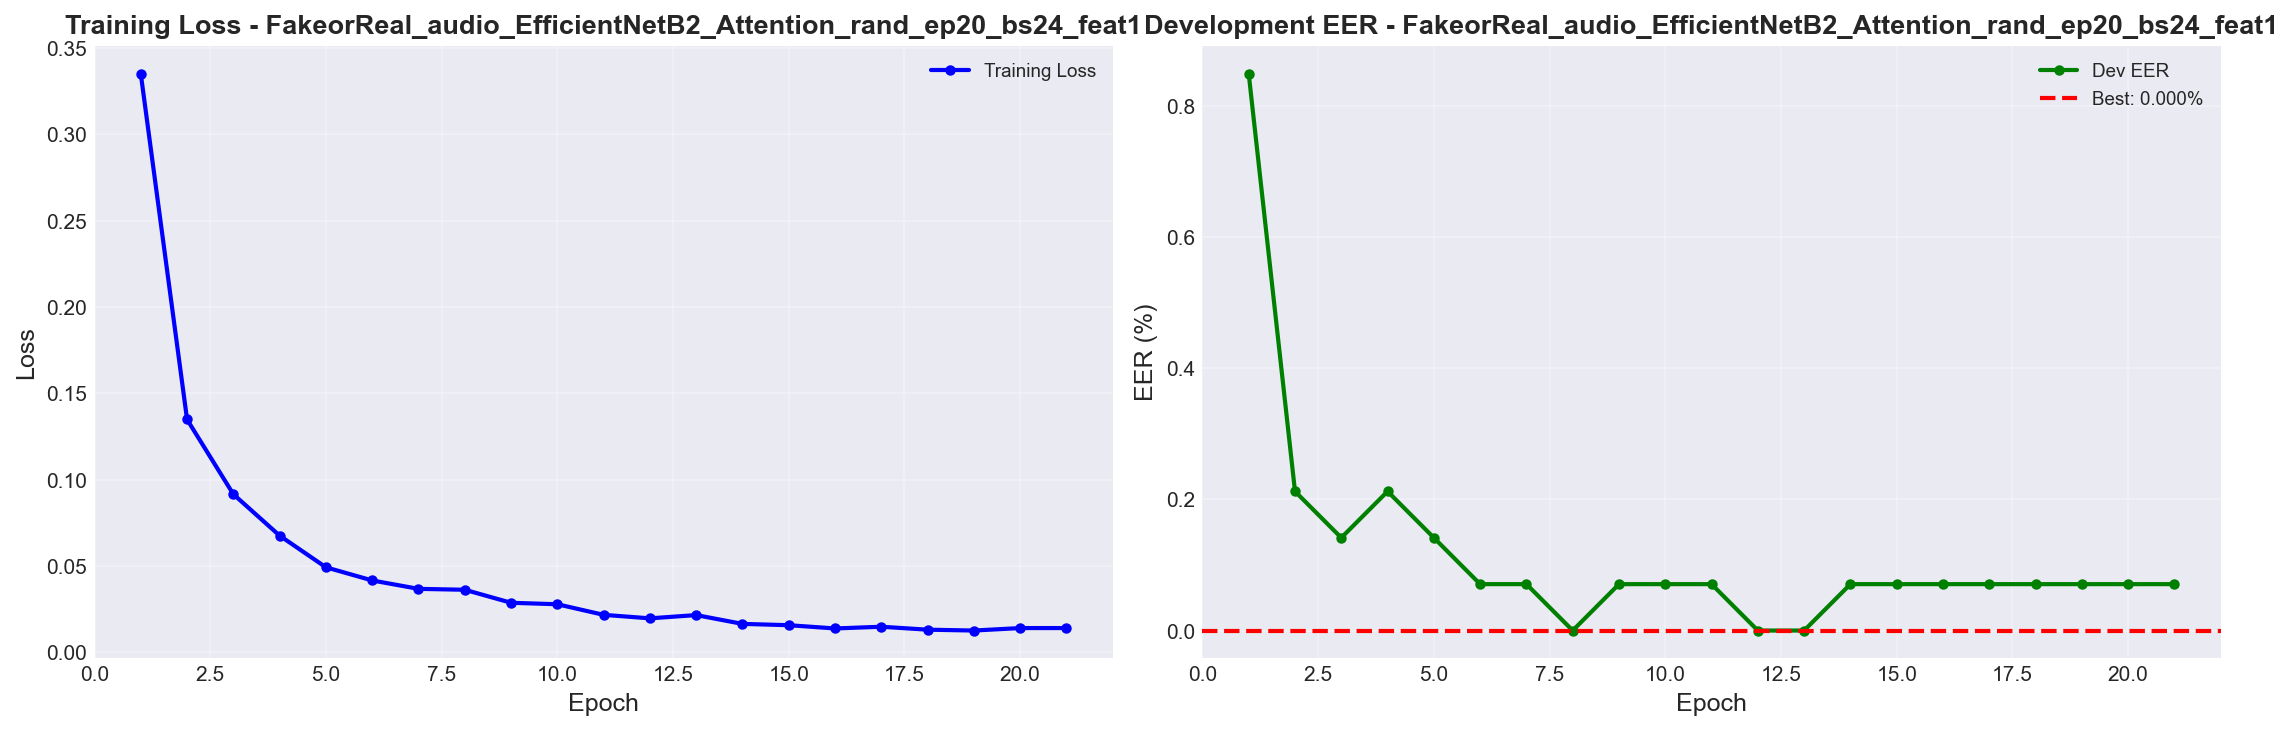

✓ Saved accuracy curves to comparison_plots\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\accuracy_curves.png


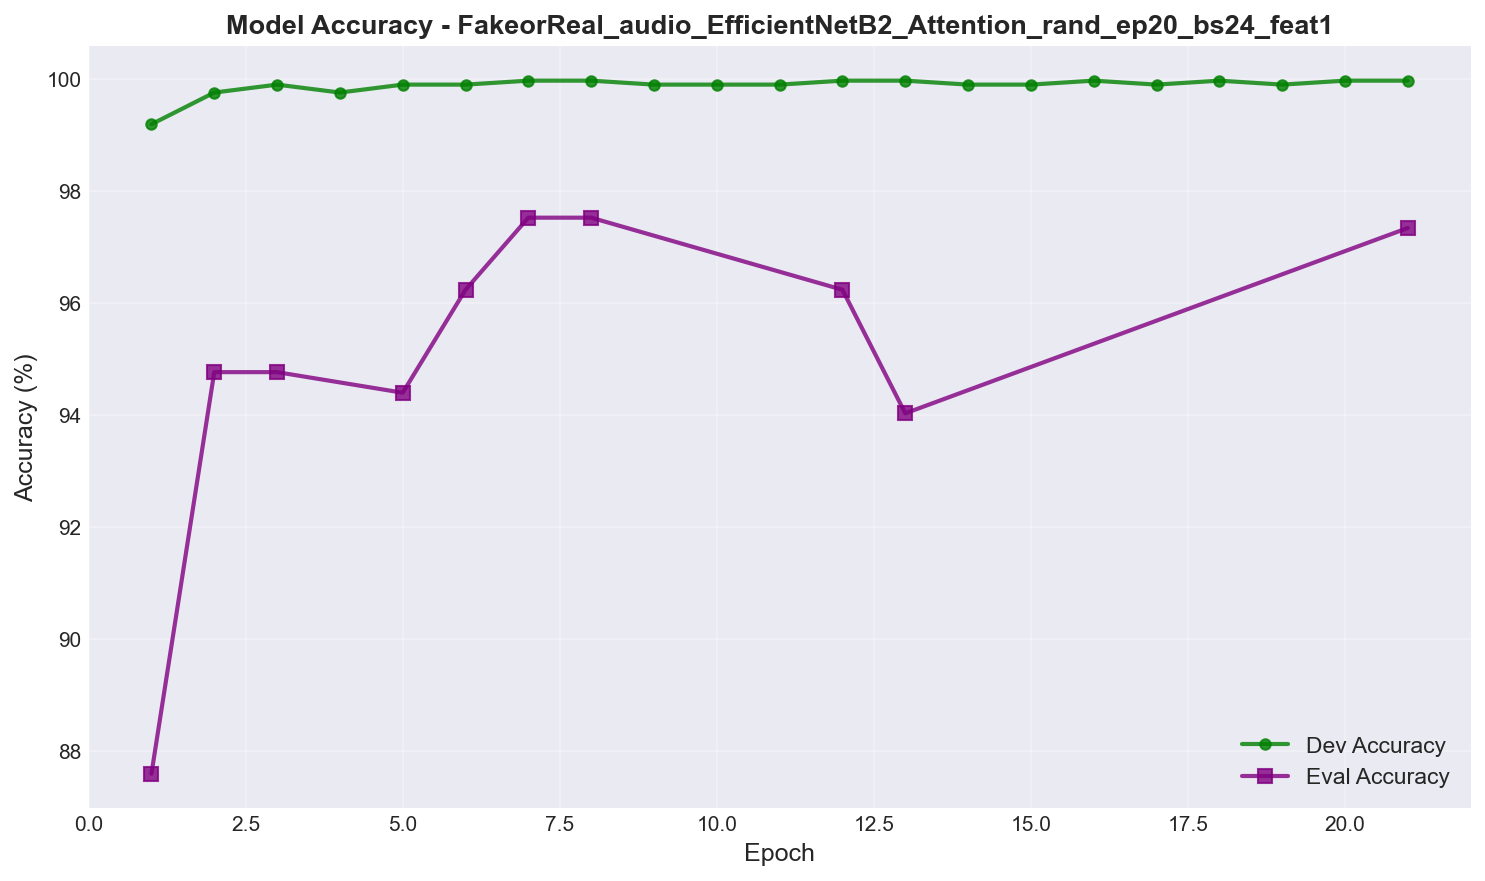

✓ Saved EER comparison to comparison_plots\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\eer_comparison.png


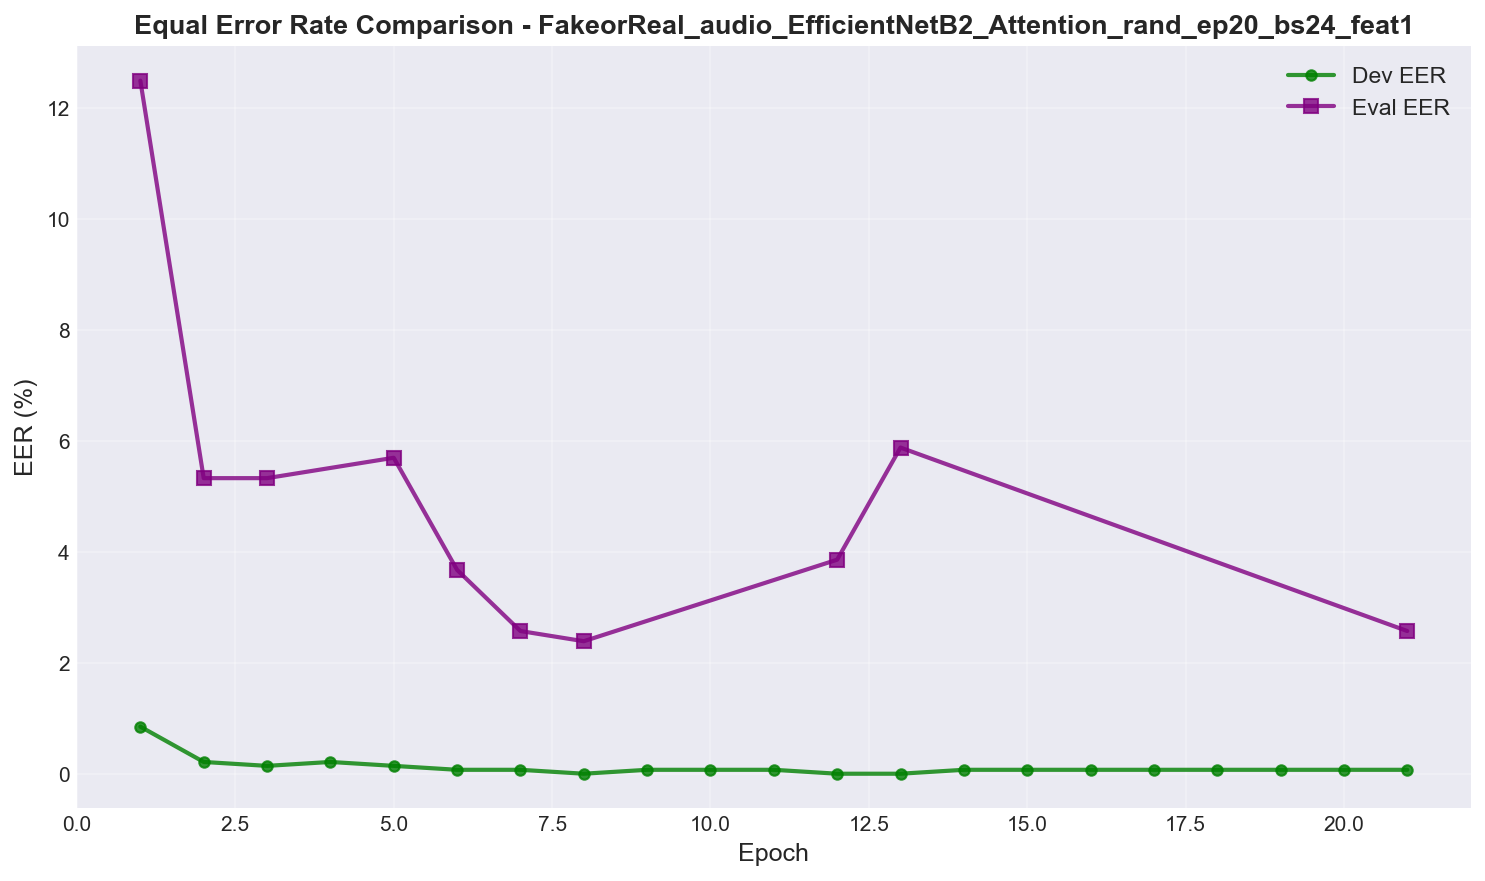

✓ Saved comprehensive metrics to comparison_plots\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1\all_metrics.png


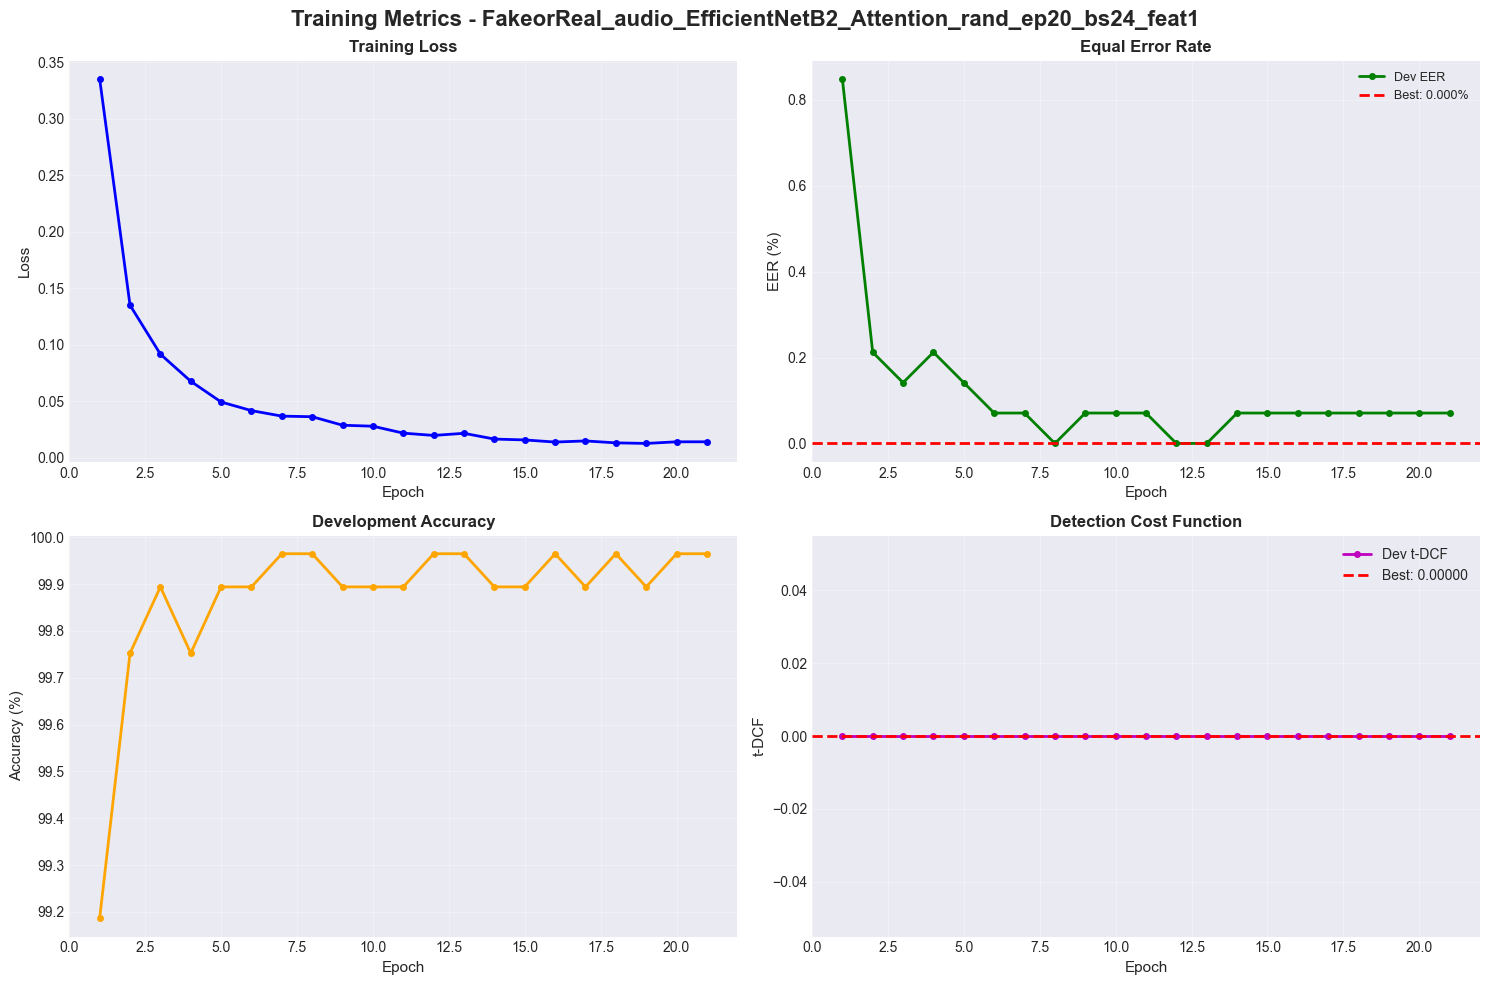


📊 FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat1 Summary
Total Epochs: 21

Training Loss:
  Initial: 0.33515
  Final:   0.01398
  Min:     0.01254

Development EER:
  Best:    0.0000%
  Final:   0.0708%

Development Accuracy:
  Best:    99.96%
  Final:   99.96%


📈 Generating visualizations for: FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4
✓ Saved training curves to comparison_plots\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\training_curves.png


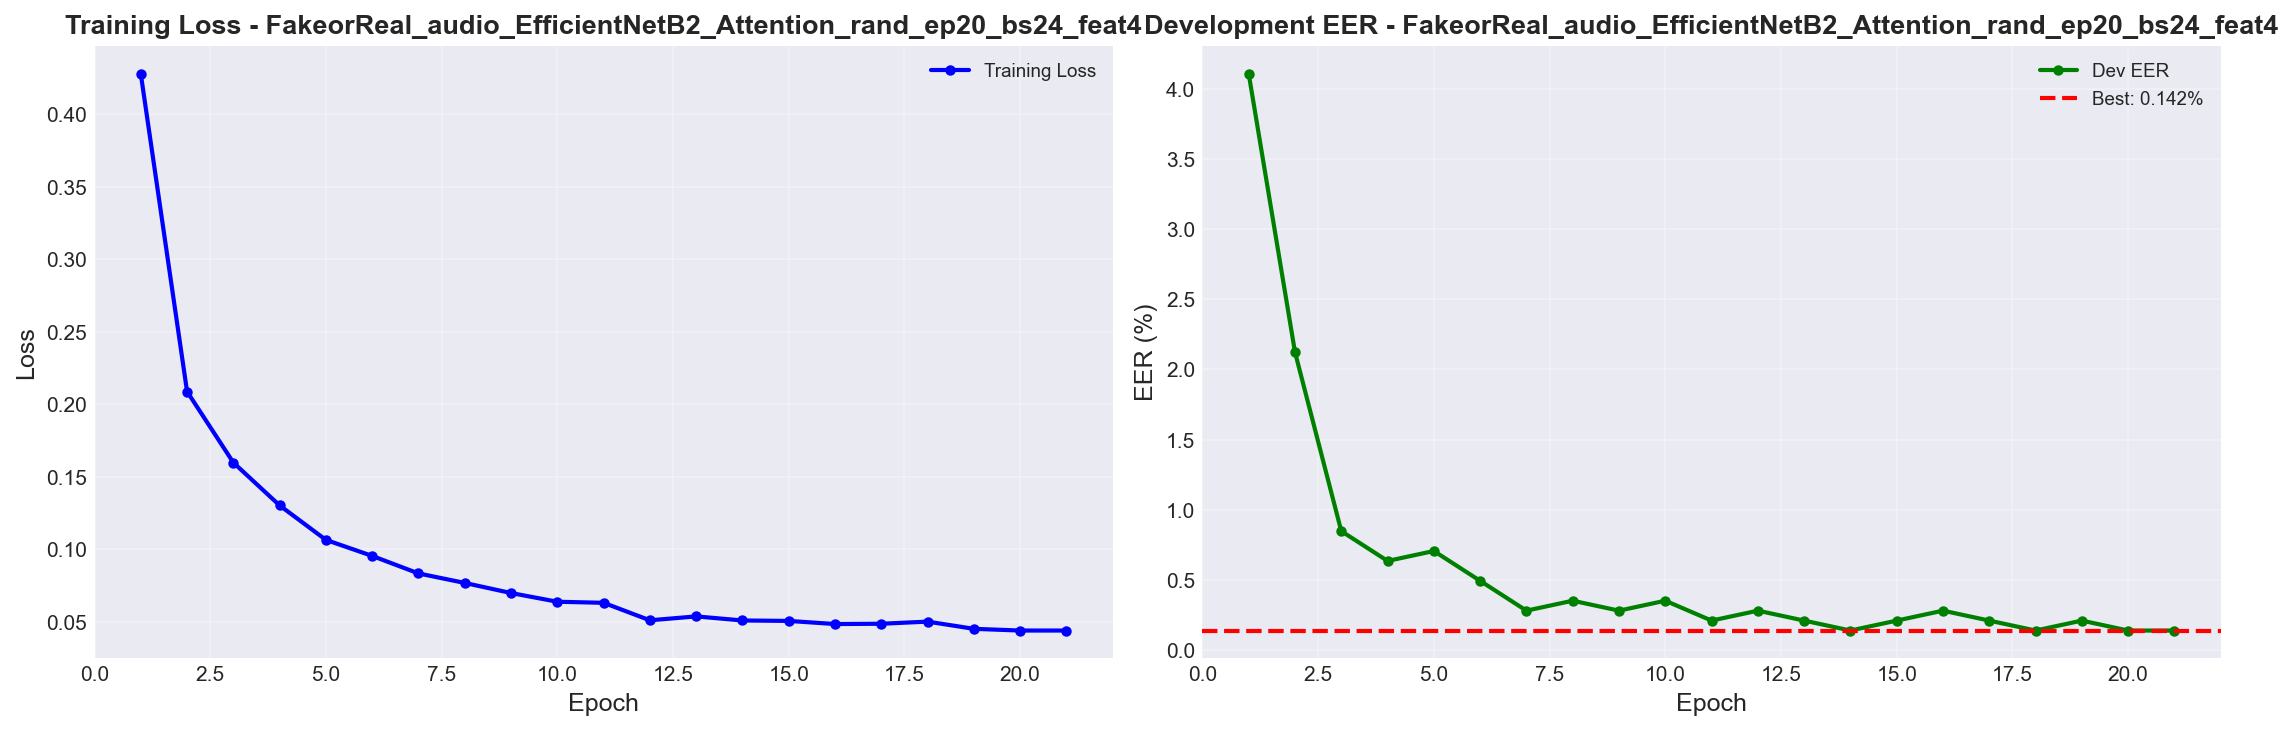

✓ Saved accuracy curves to comparison_plots\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\accuracy_curves.png


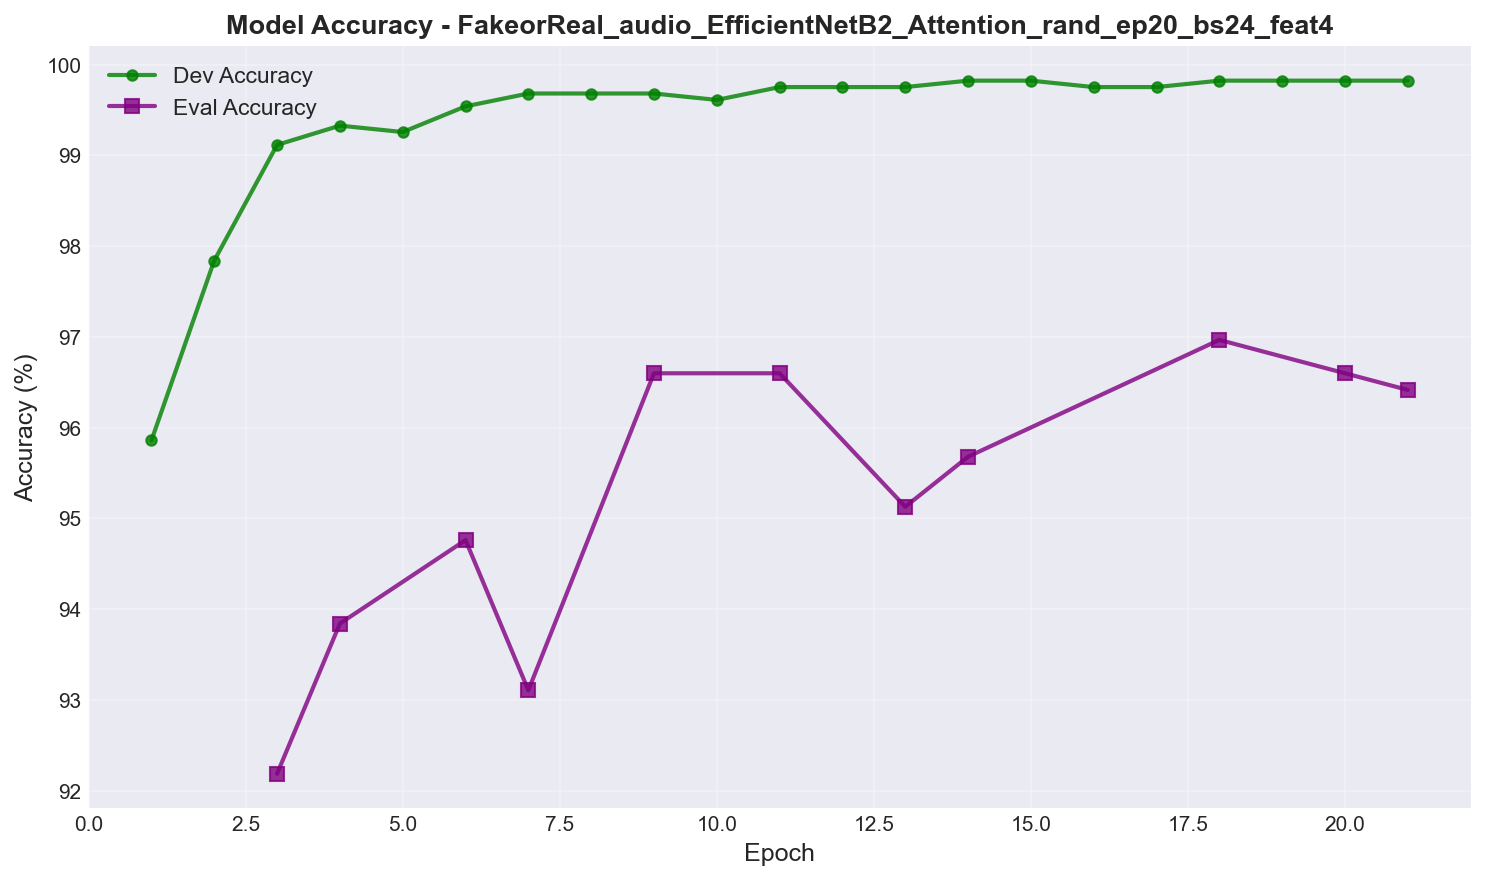

✓ Saved EER comparison to comparison_plots\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\eer_comparison.png


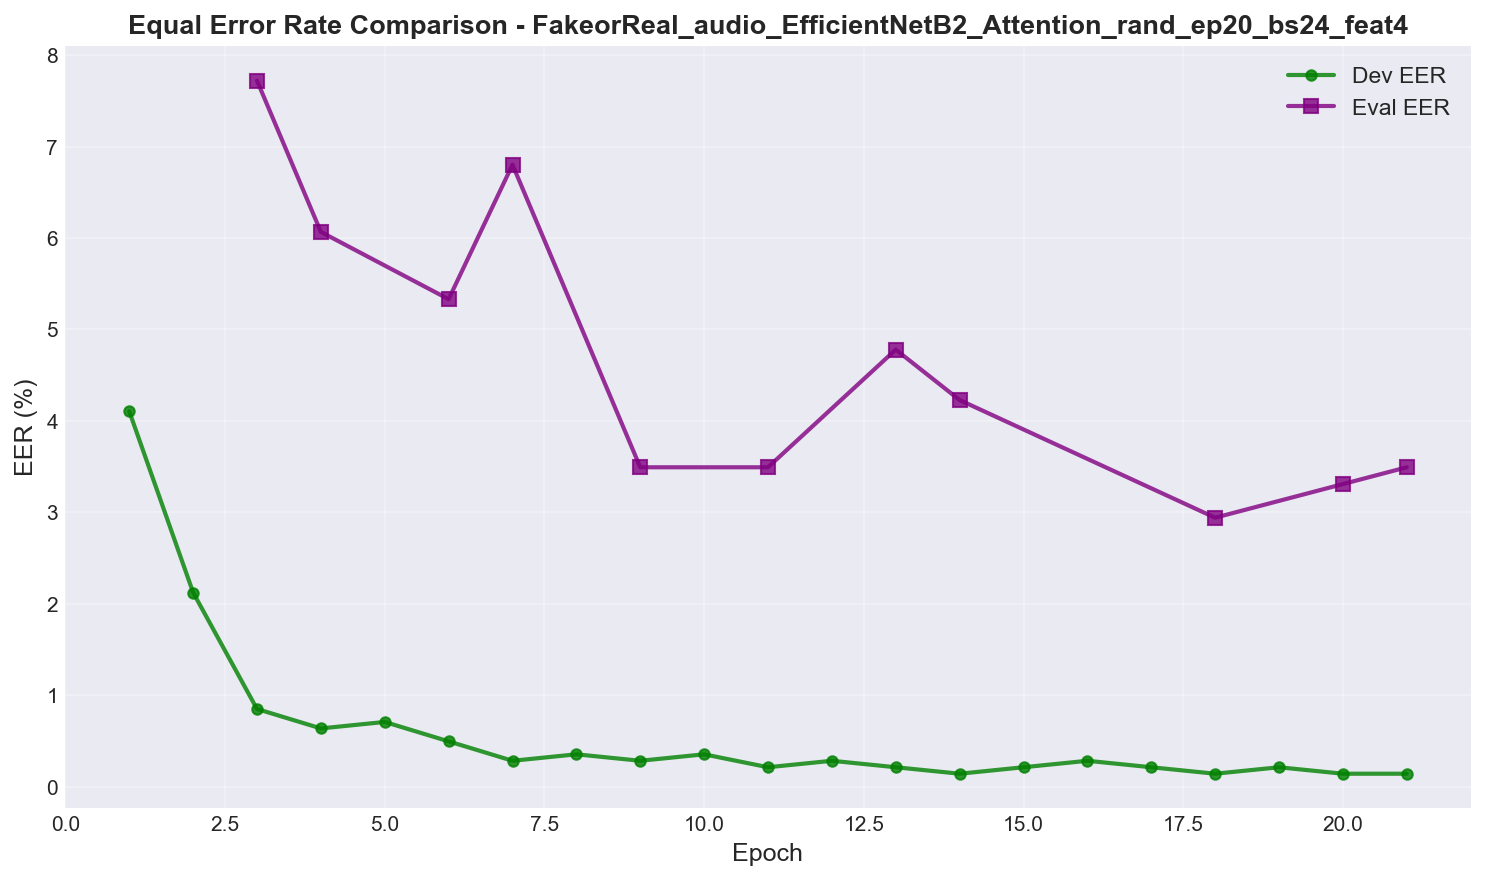

✓ Saved comprehensive metrics to comparison_plots\FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4\all_metrics.png


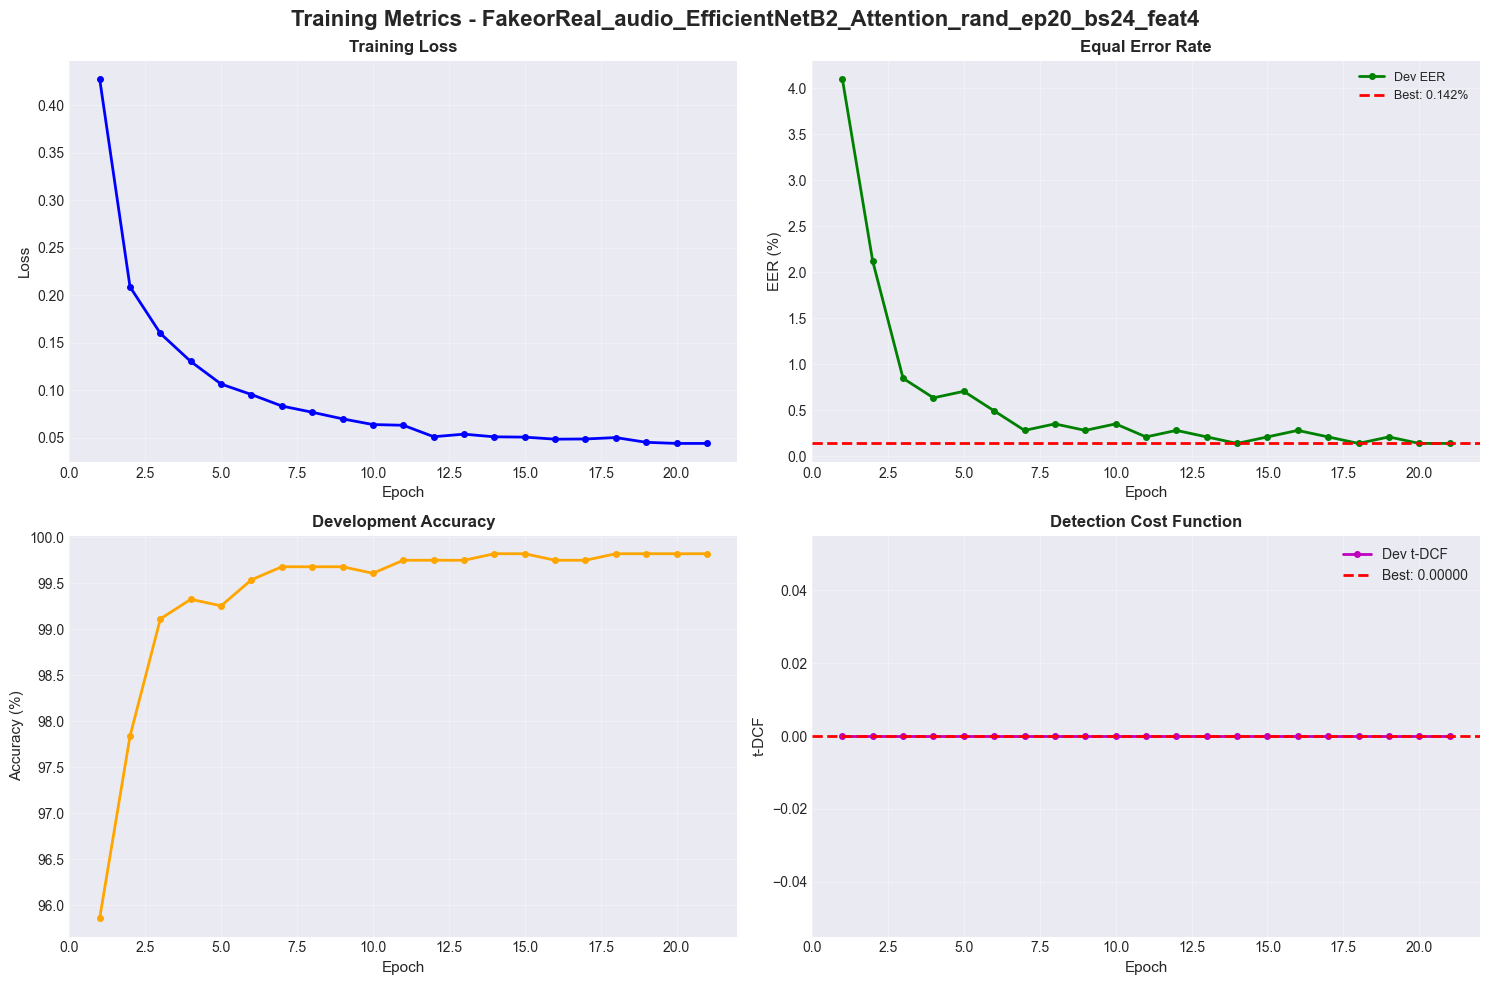


📊 FakeorReal_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat4 Summary
Total Epochs: 21

Training Loss:
  Initial: 0.42799
  Final:   0.04387
  Min:     0.04387

Development EER:
  Best:    0.1415%
  Final:   0.1415%

Development Accuracy:
  Best:    99.82%
  Final:   99.82%


📈 Generating visualizations for: FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1
✓ Saved training curves to comparison_plots\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\training_curves.png


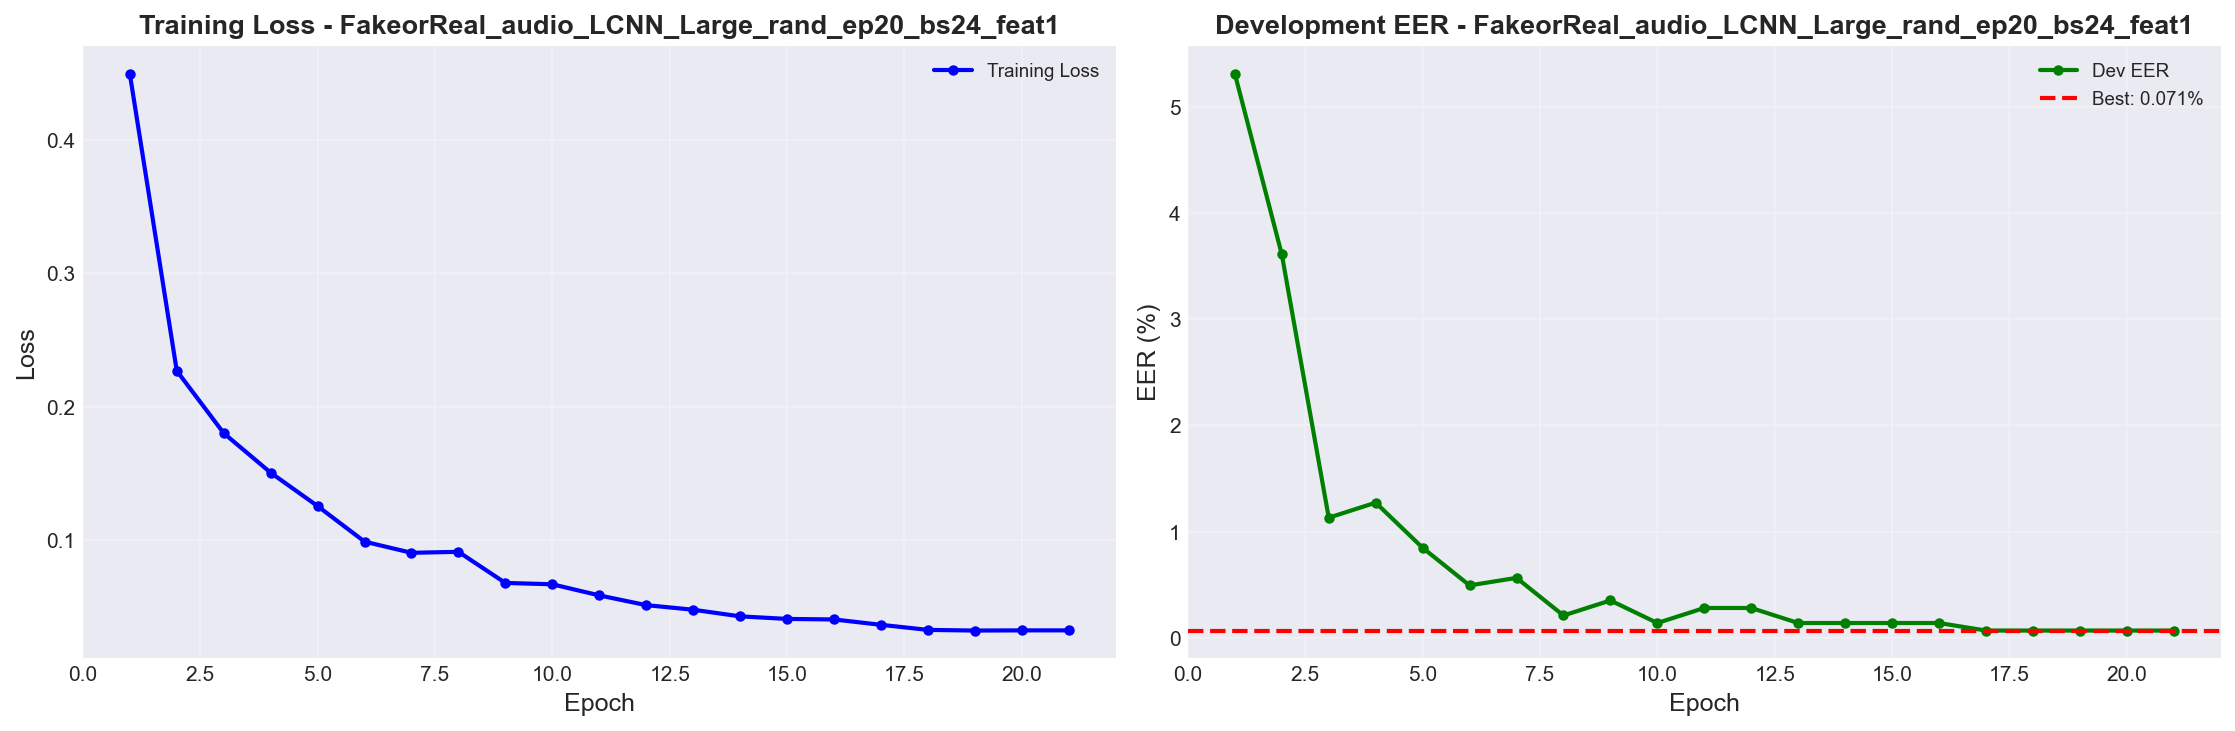

✓ Saved accuracy curves to comparison_plots\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\accuracy_curves.png


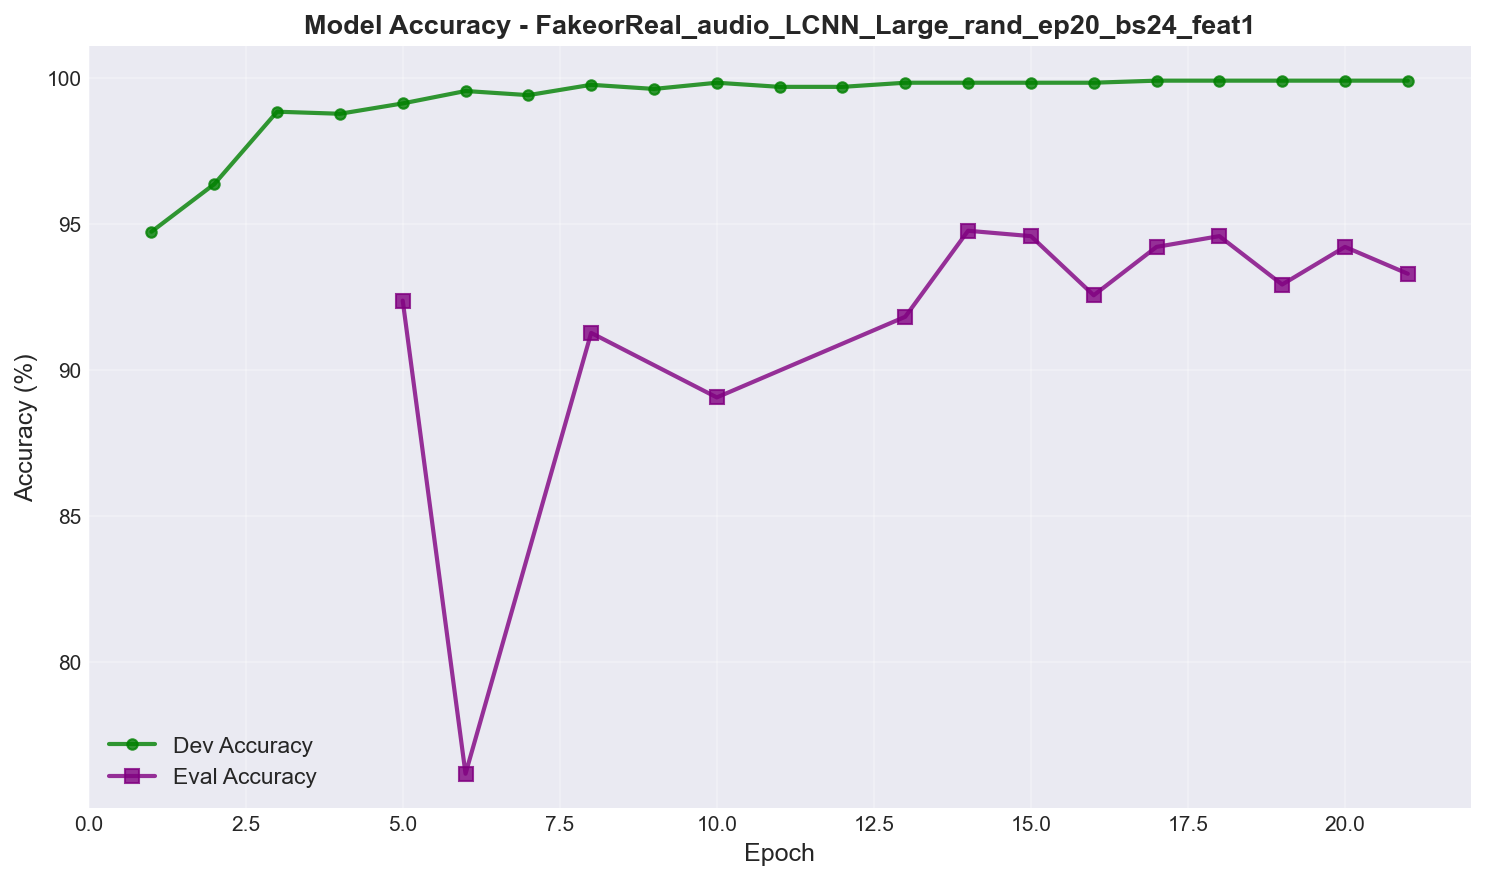

✓ Saved EER comparison to comparison_plots\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\eer_comparison.png


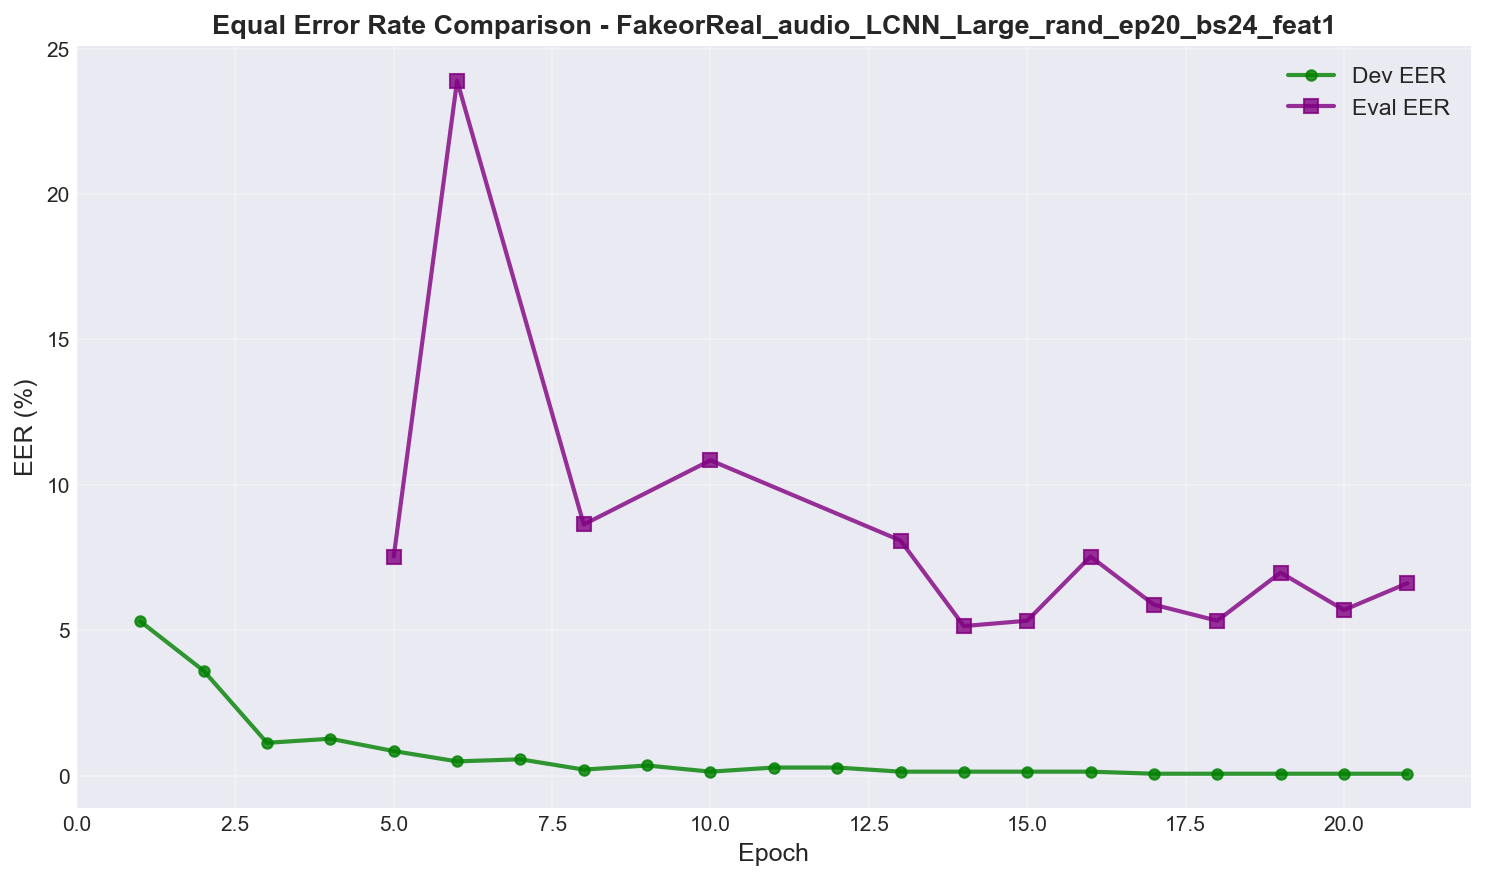

✓ Saved comprehensive metrics to comparison_plots\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1\all_metrics.png


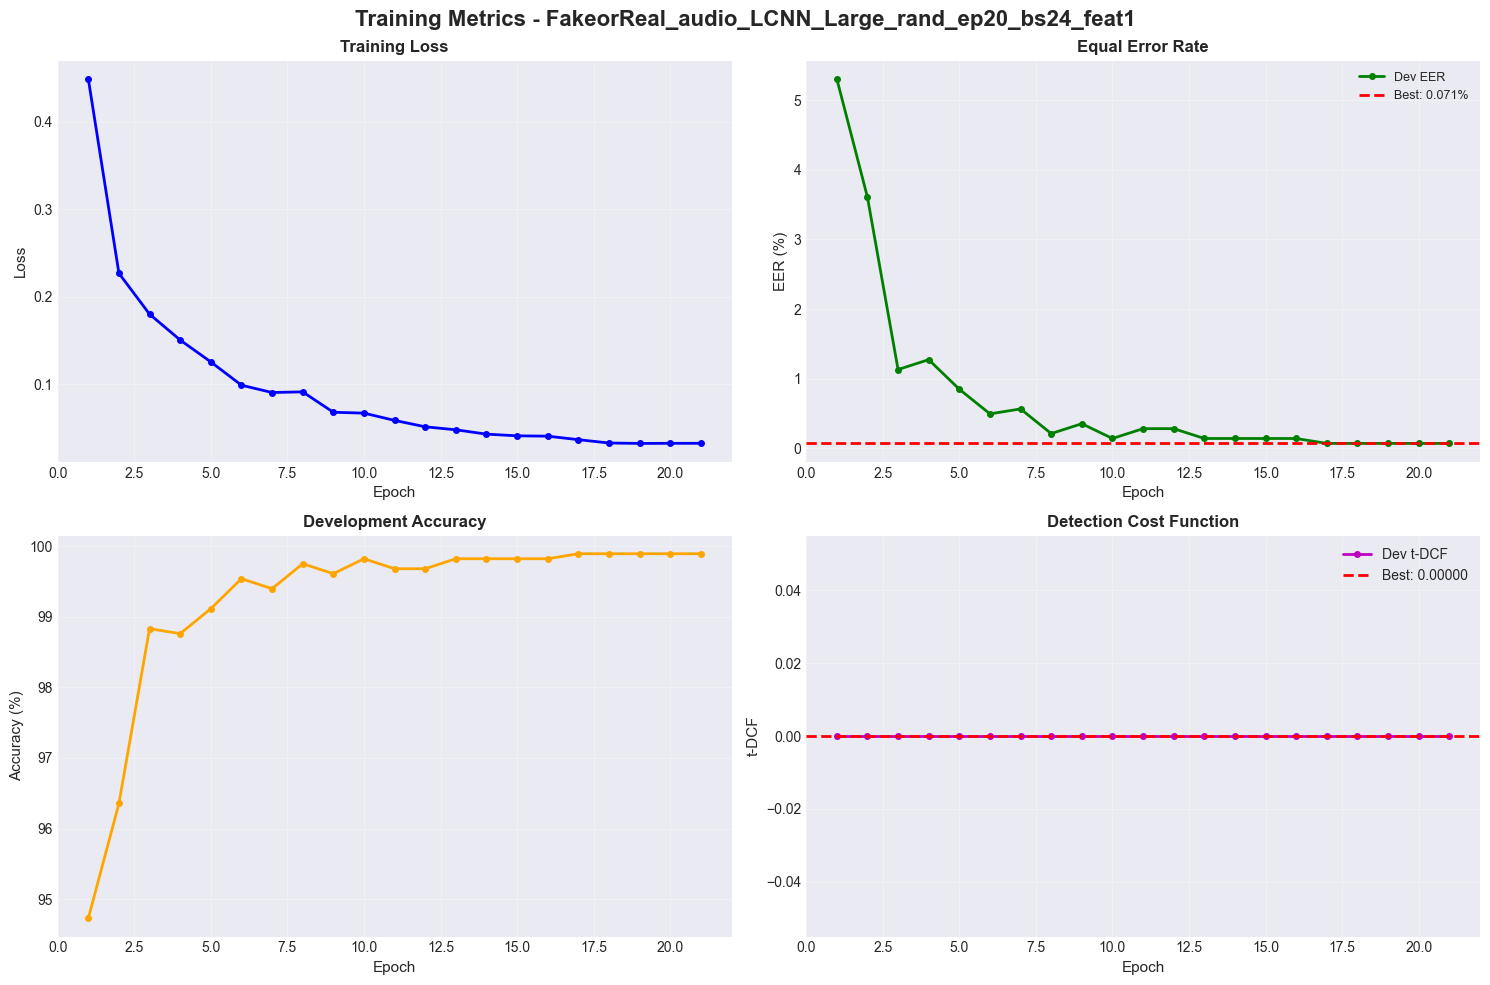


📊 FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat1 Summary
Total Epochs: 21

Training Loss:
  Initial: 0.44941
  Final:   0.03225
  Min:     0.03212

Development EER:
  Best:    0.0708%
  Final:   0.0708%

Development Accuracy:
  Best:    99.89%
  Final:   99.89%


📈 Generating visualizations for: FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2
✓ Saved training curves to comparison_plots\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\training_curves.png


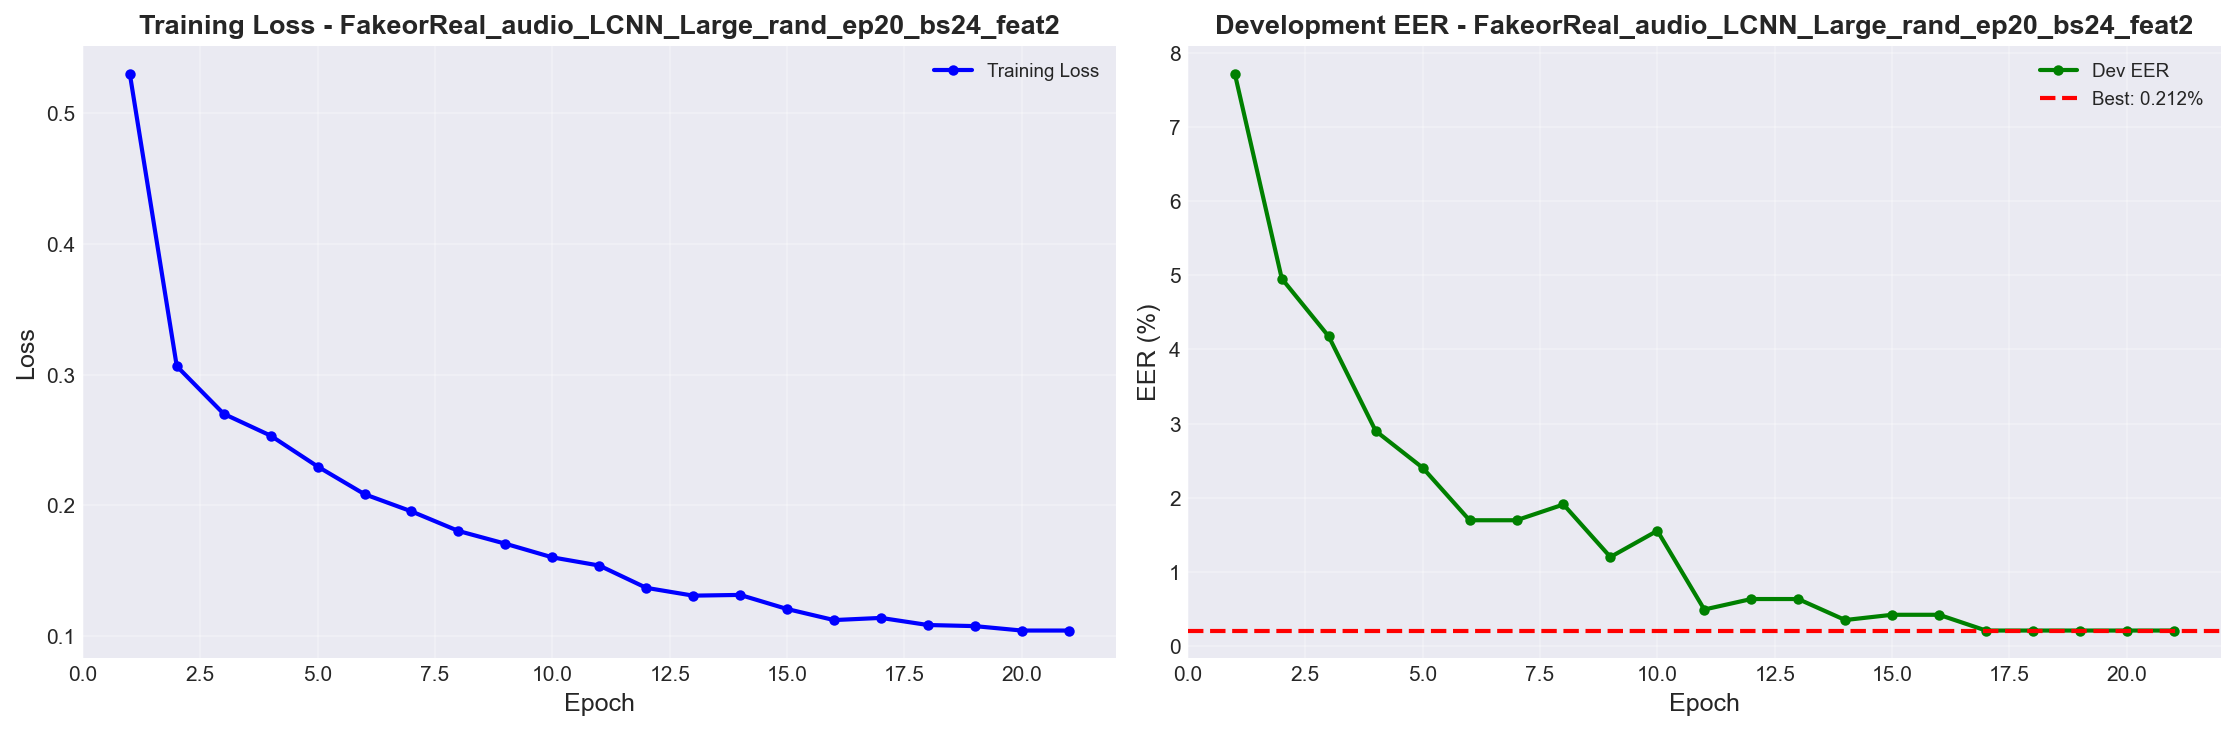

✓ Saved accuracy curves to comparison_plots\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\accuracy_curves.png


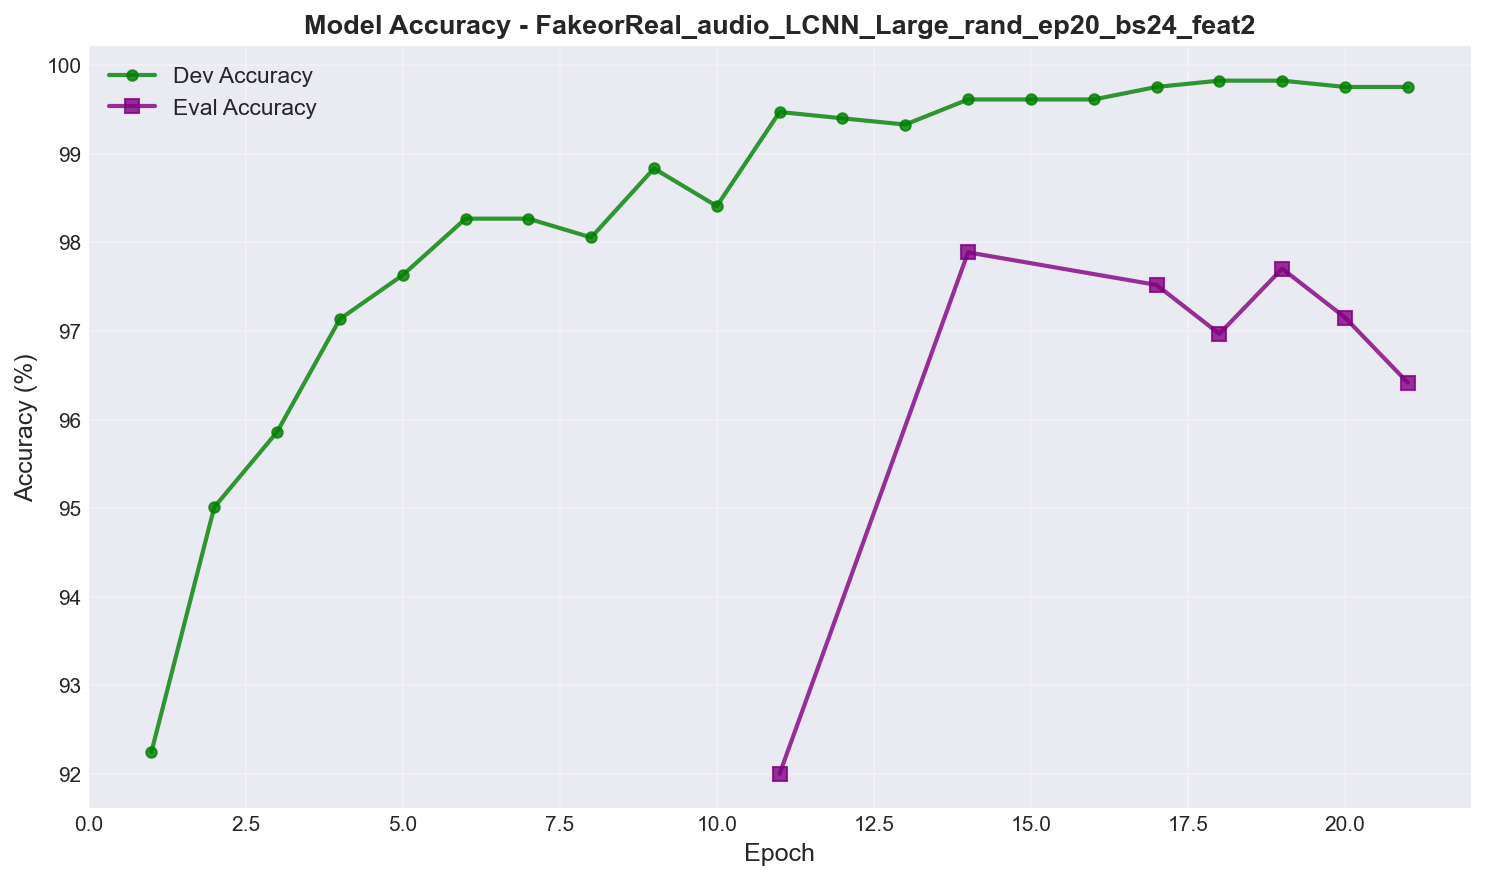

✓ Saved EER comparison to comparison_plots\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\eer_comparison.png


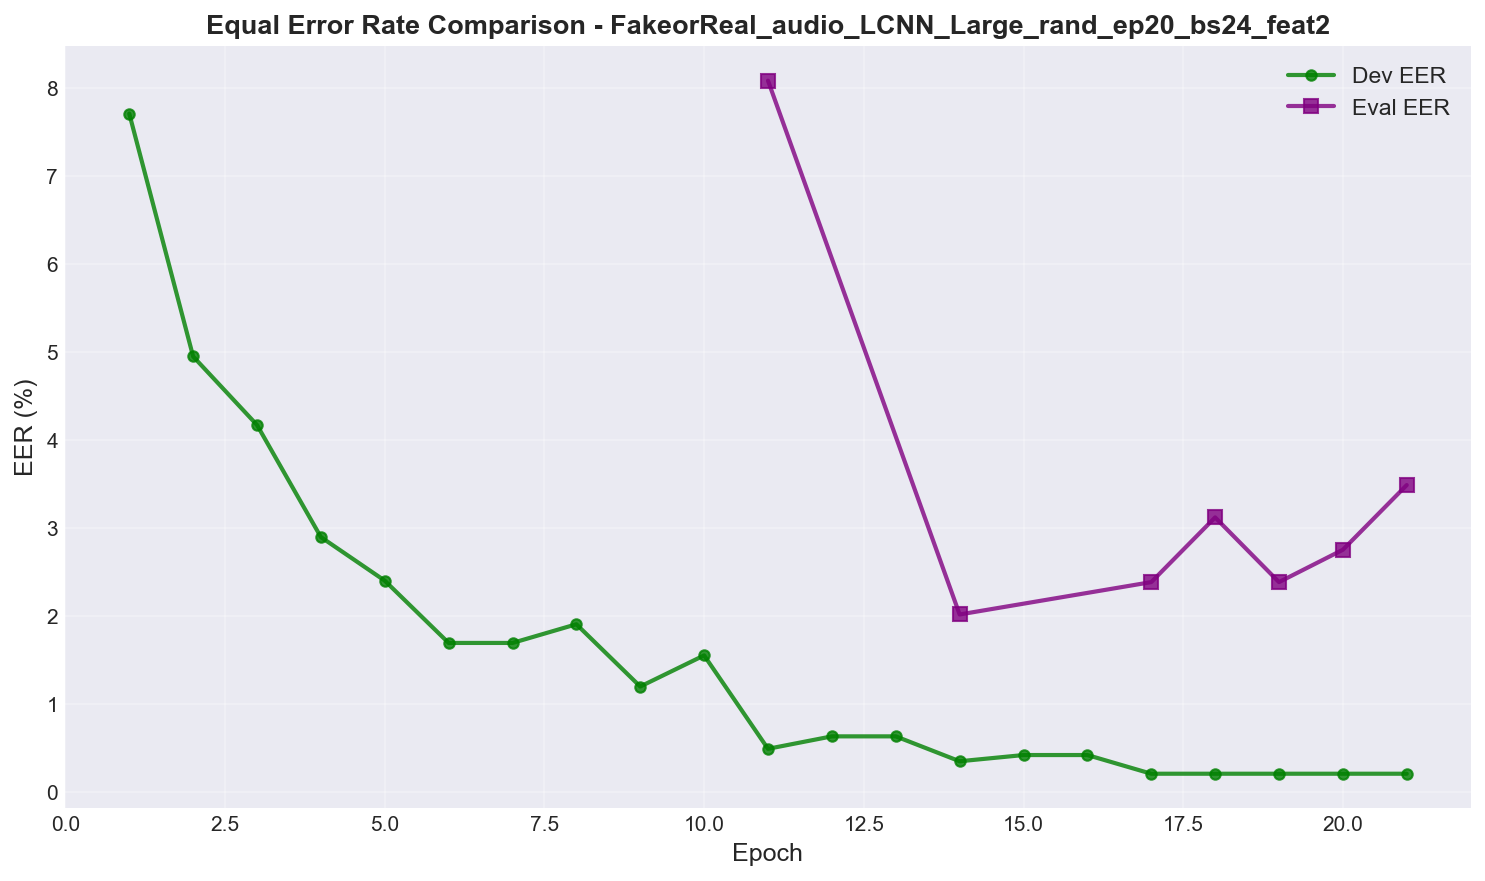

✓ Saved comprehensive metrics to comparison_plots\FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2\all_metrics.png


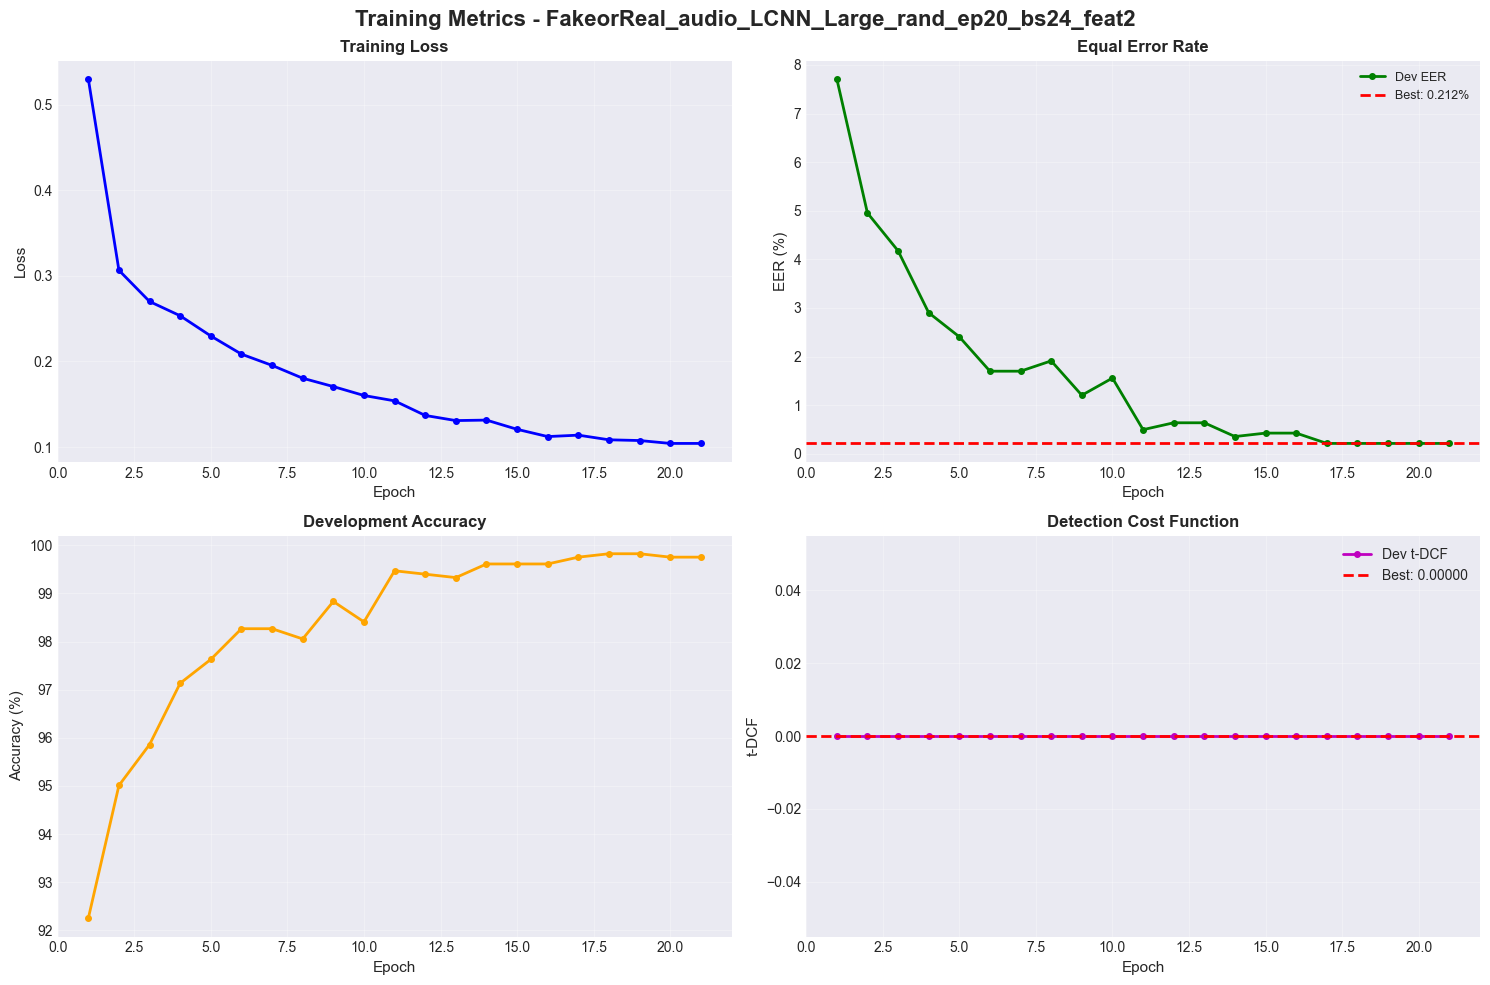


📊 FakeorReal_audio_LCNN_Large_rand_ep20_bs24_feat2 Summary
Total Epochs: 21

Training Loss:
  Initial: 0.53011
  Final:   0.10420
  Min:     0.10420

Development EER:
  Best:    0.2123%
  Final:   0.2123%

Development Accuracy:
  Best:    99.82%
  Final:   99.75%


📈 Generating visualizations for: FakeorReal_audio_LCNN_rand_ep20_bs32_feat1
✓ Saved training curves to comparison_plots\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\training_curves.png


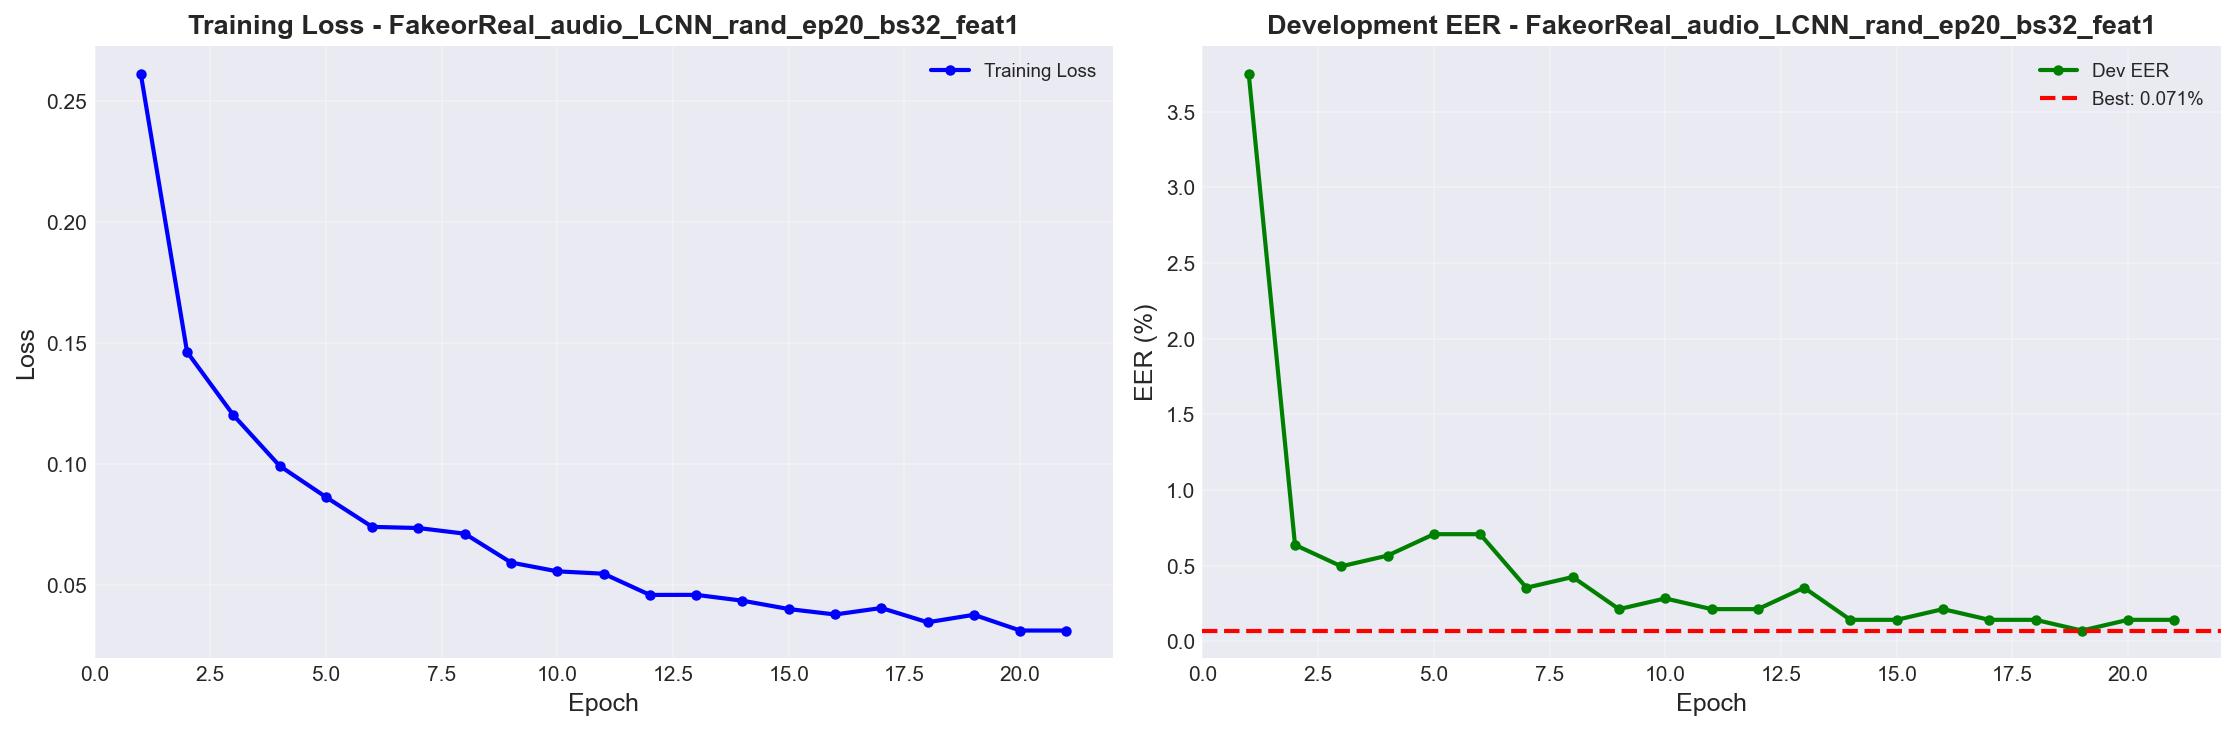

✓ Saved accuracy curves to comparison_plots\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\accuracy_curves.png


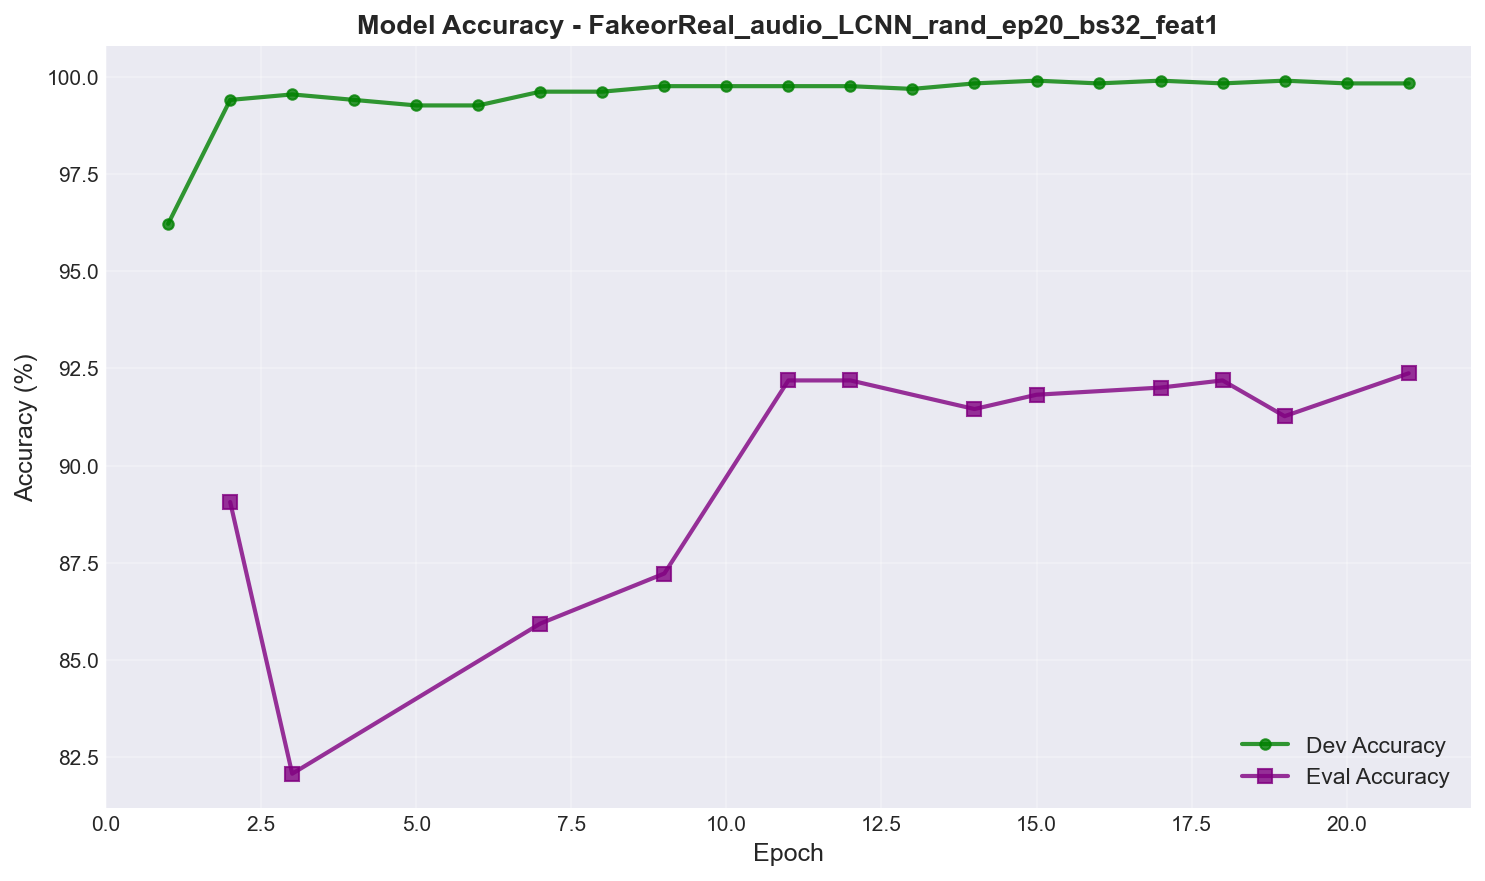

✓ Saved EER comparison to comparison_plots\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\eer_comparison.png


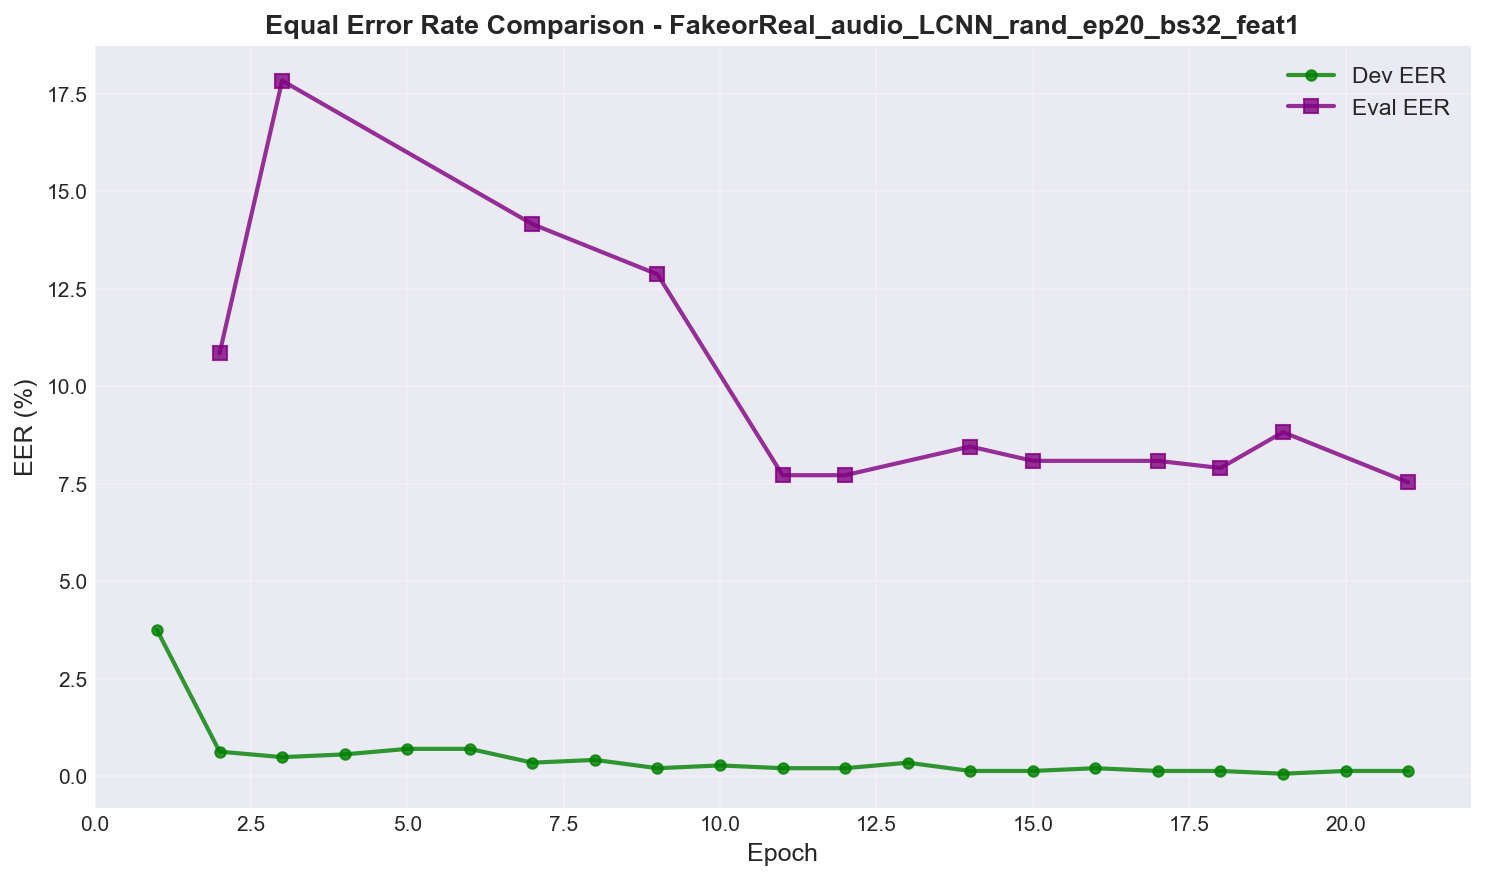

✓ Saved comprehensive metrics to comparison_plots\FakeorReal_audio_LCNN_rand_ep20_bs32_feat1\all_metrics.png


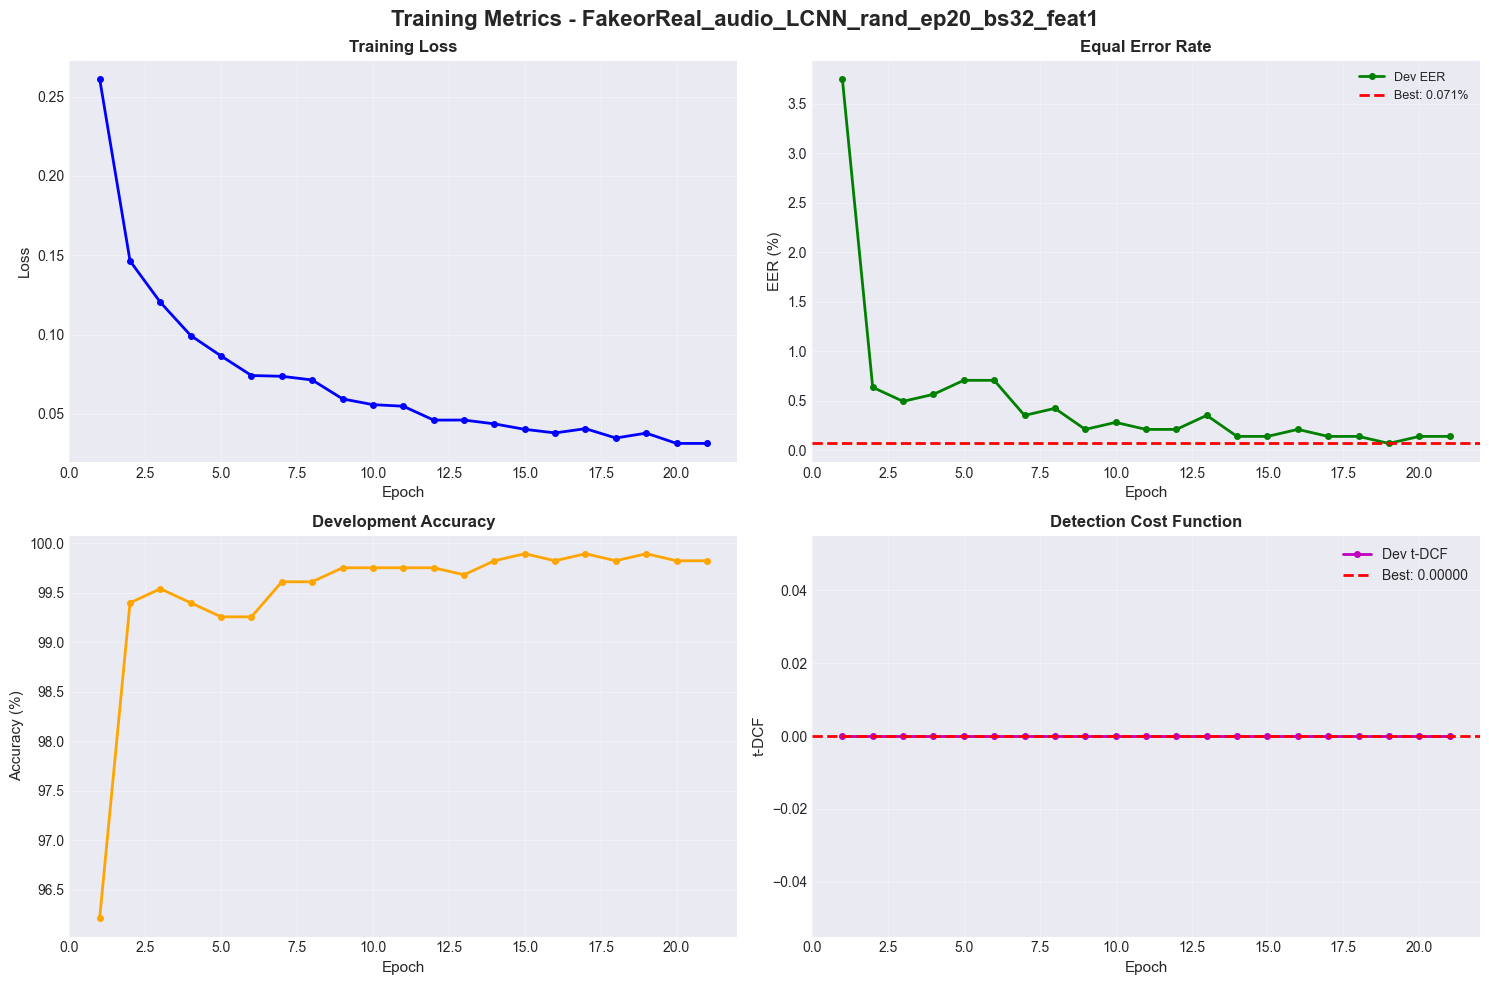


📊 FakeorReal_audio_LCNN_rand_ep20_bs32_feat1 Summary
Total Epochs: 21

Training Loss:
  Initial: 0.26125
  Final:   0.03131
  Min:     0.03131

Development EER:
  Best:    0.0708%
  Final:   0.1415%

Development Accuracy:
  Best:    99.89%
  Final:   99.82%


📈 Generating visualizations for: FakeorReal_audio_LCNN_rand_ep20_bs32_feat2
✓ Saved training curves to comparison_plots\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\training_curves.png


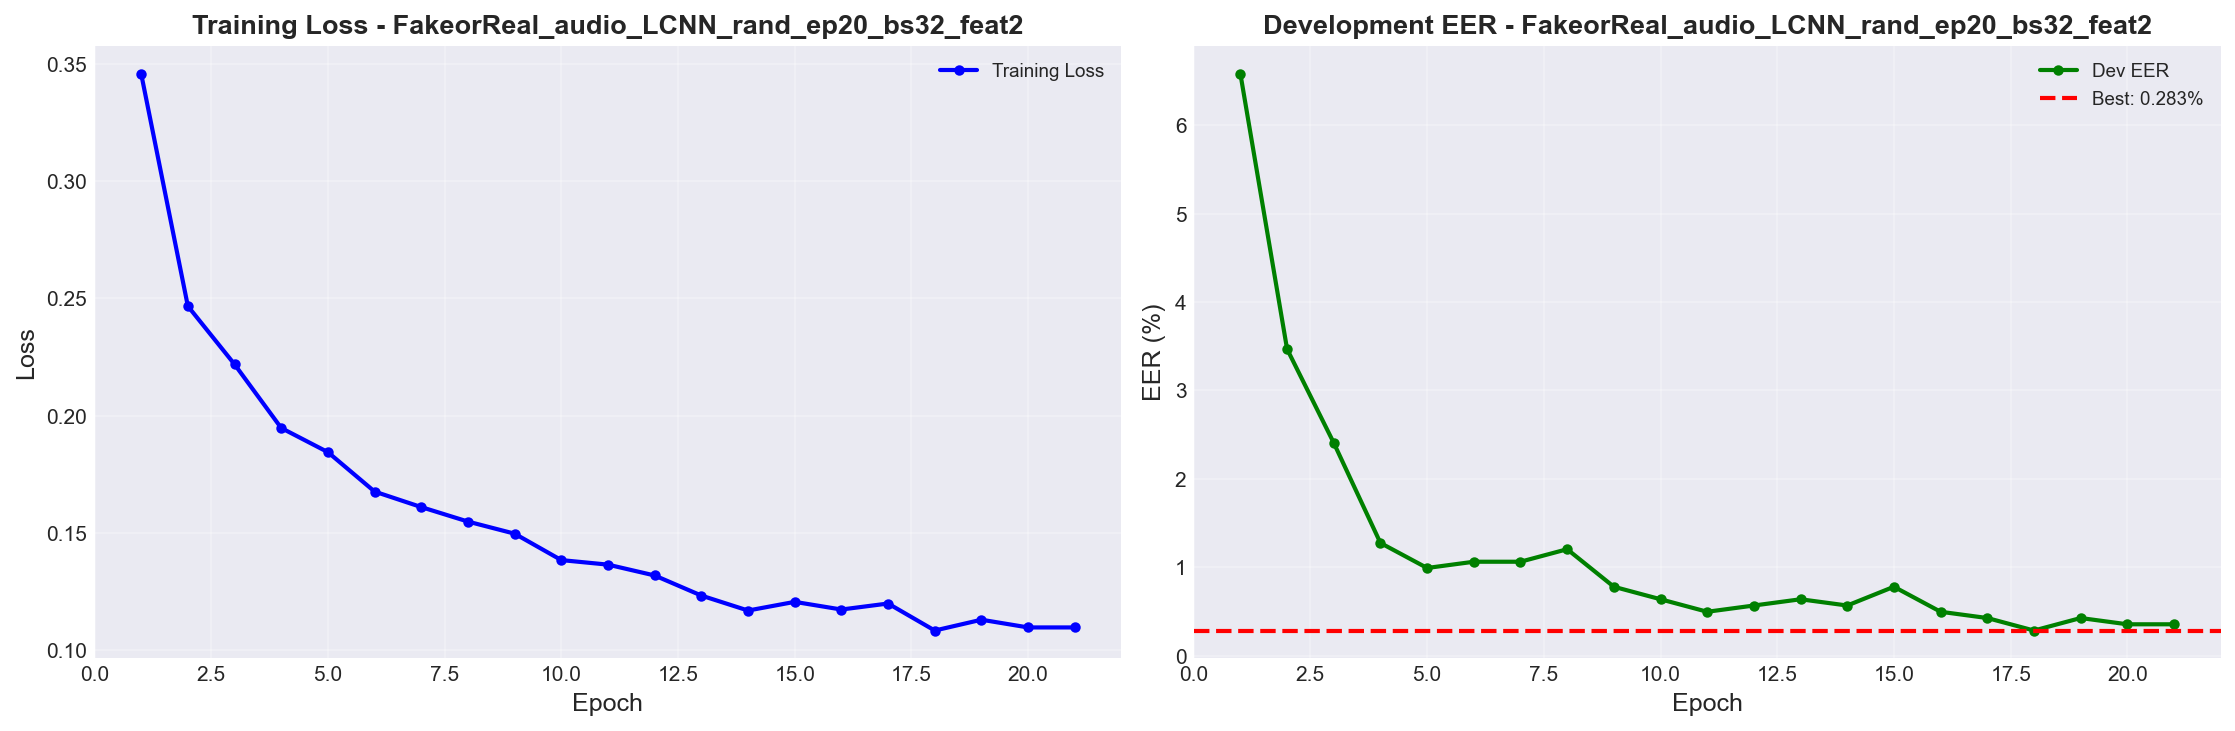

✓ Saved accuracy curves to comparison_plots\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\accuracy_curves.png


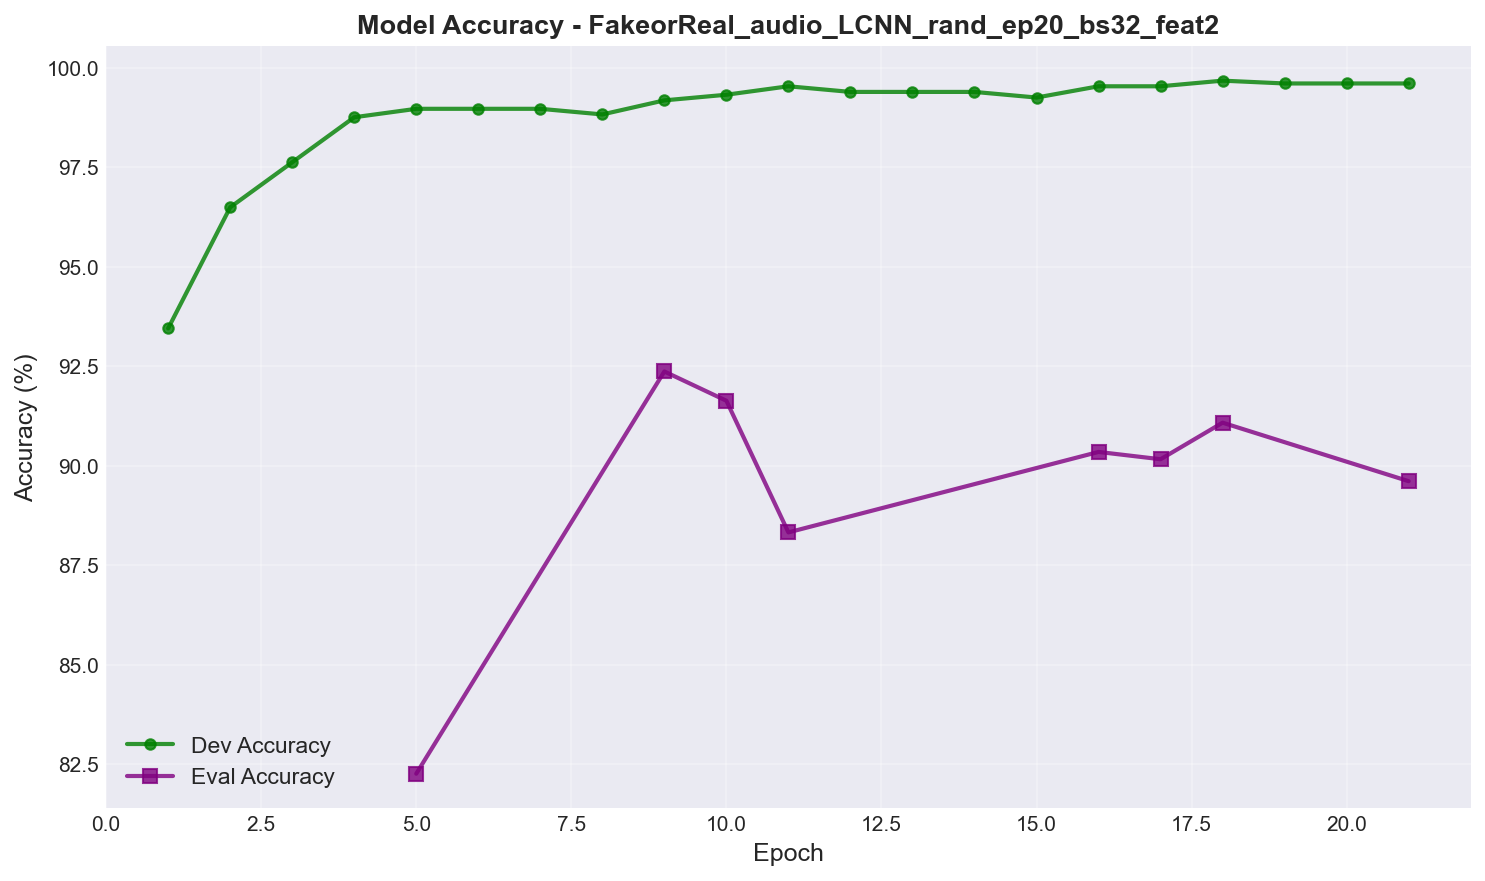

✓ Saved EER comparison to comparison_plots\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\eer_comparison.png


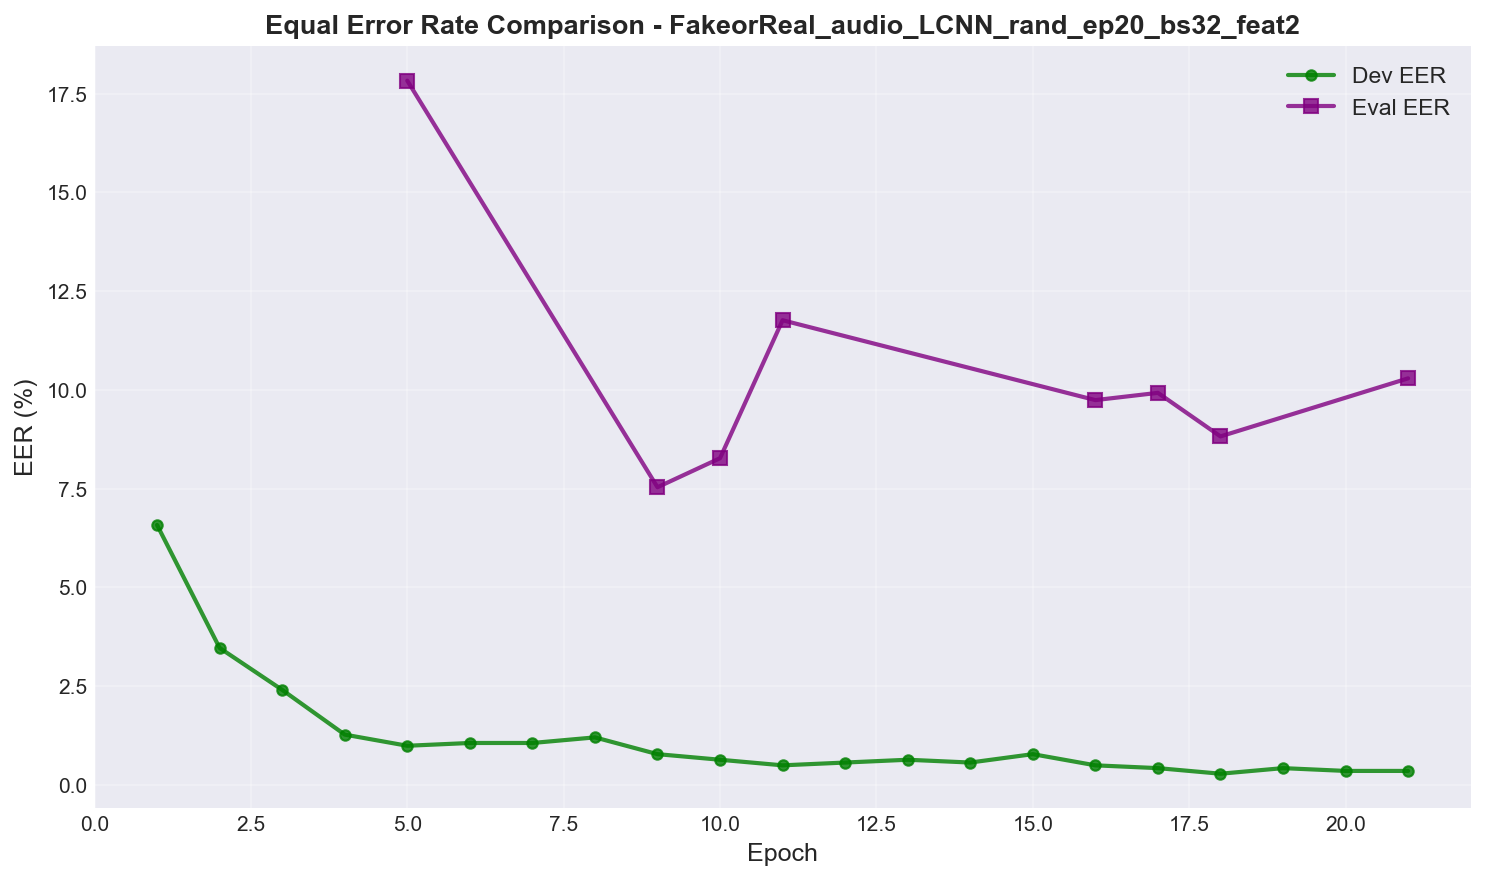

✓ Saved comprehensive metrics to comparison_plots\FakeorReal_audio_LCNN_rand_ep20_bs32_feat2\all_metrics.png


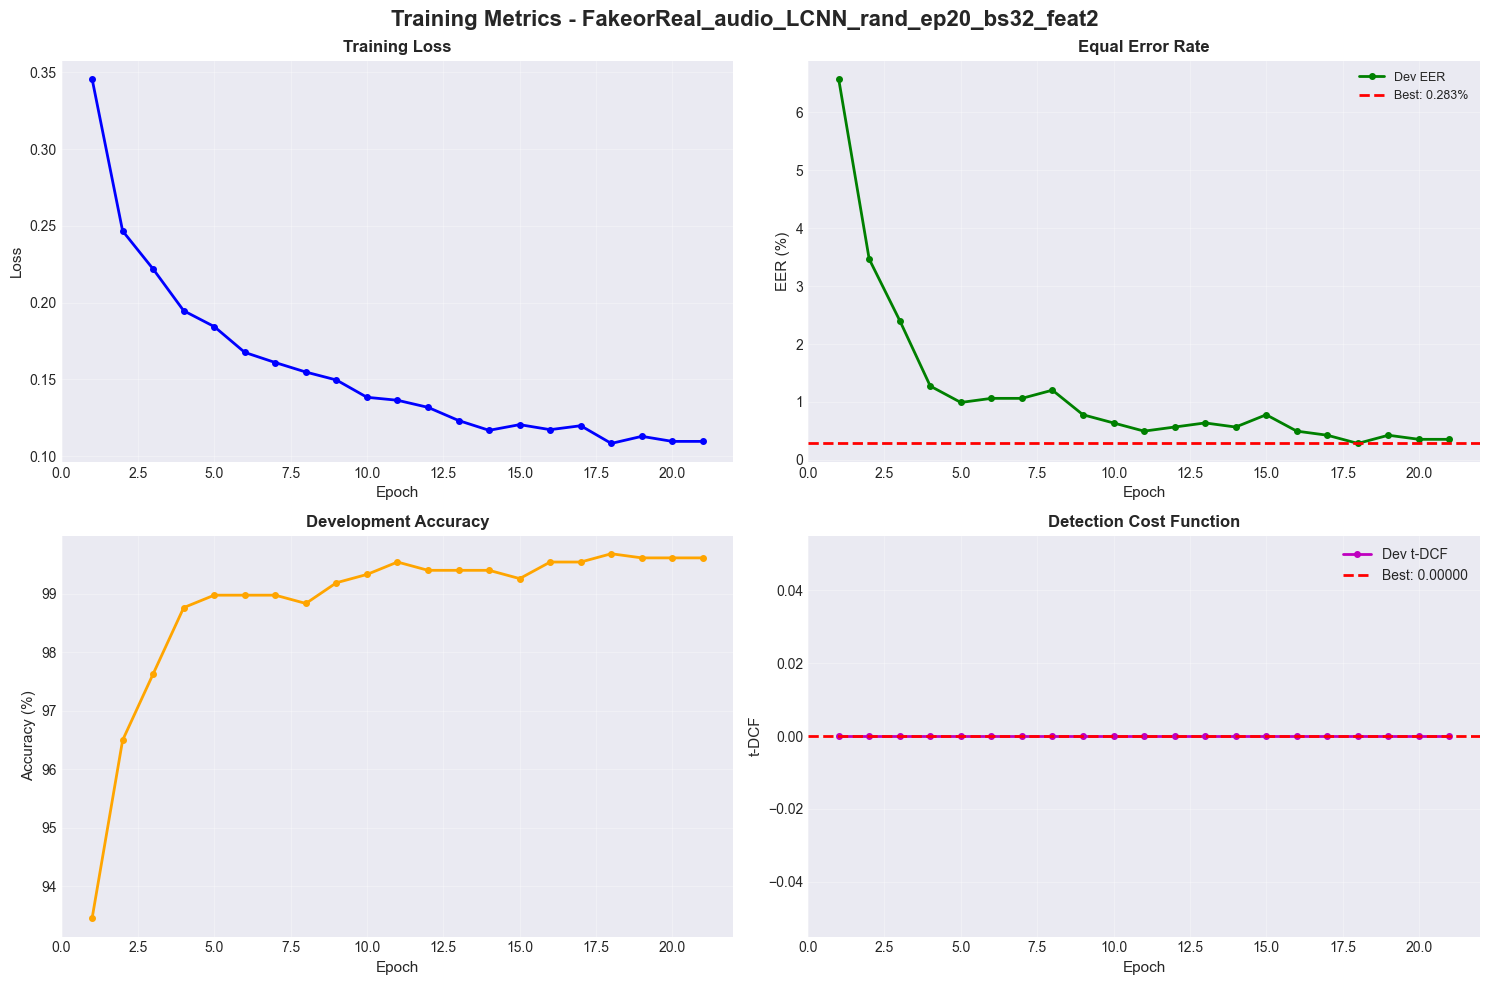


📊 FakeorReal_audio_LCNN_rand_ep20_bs32_feat2 Summary
Total Epochs: 21

Training Loss:
  Initial: 0.34572
  Final:   0.10966
  Min:     0.10834

Development EER:
  Best:    0.2831%
  Final:   0.3539%

Development Accuracy:
  Best:    99.68%
  Final:   99.61%


📈 Generating visualizations for: FakeorReal_audio_LCNN_rand_ep20_bs32_feat4
✓ Saved training curves to comparison_plots\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\training_curves.png


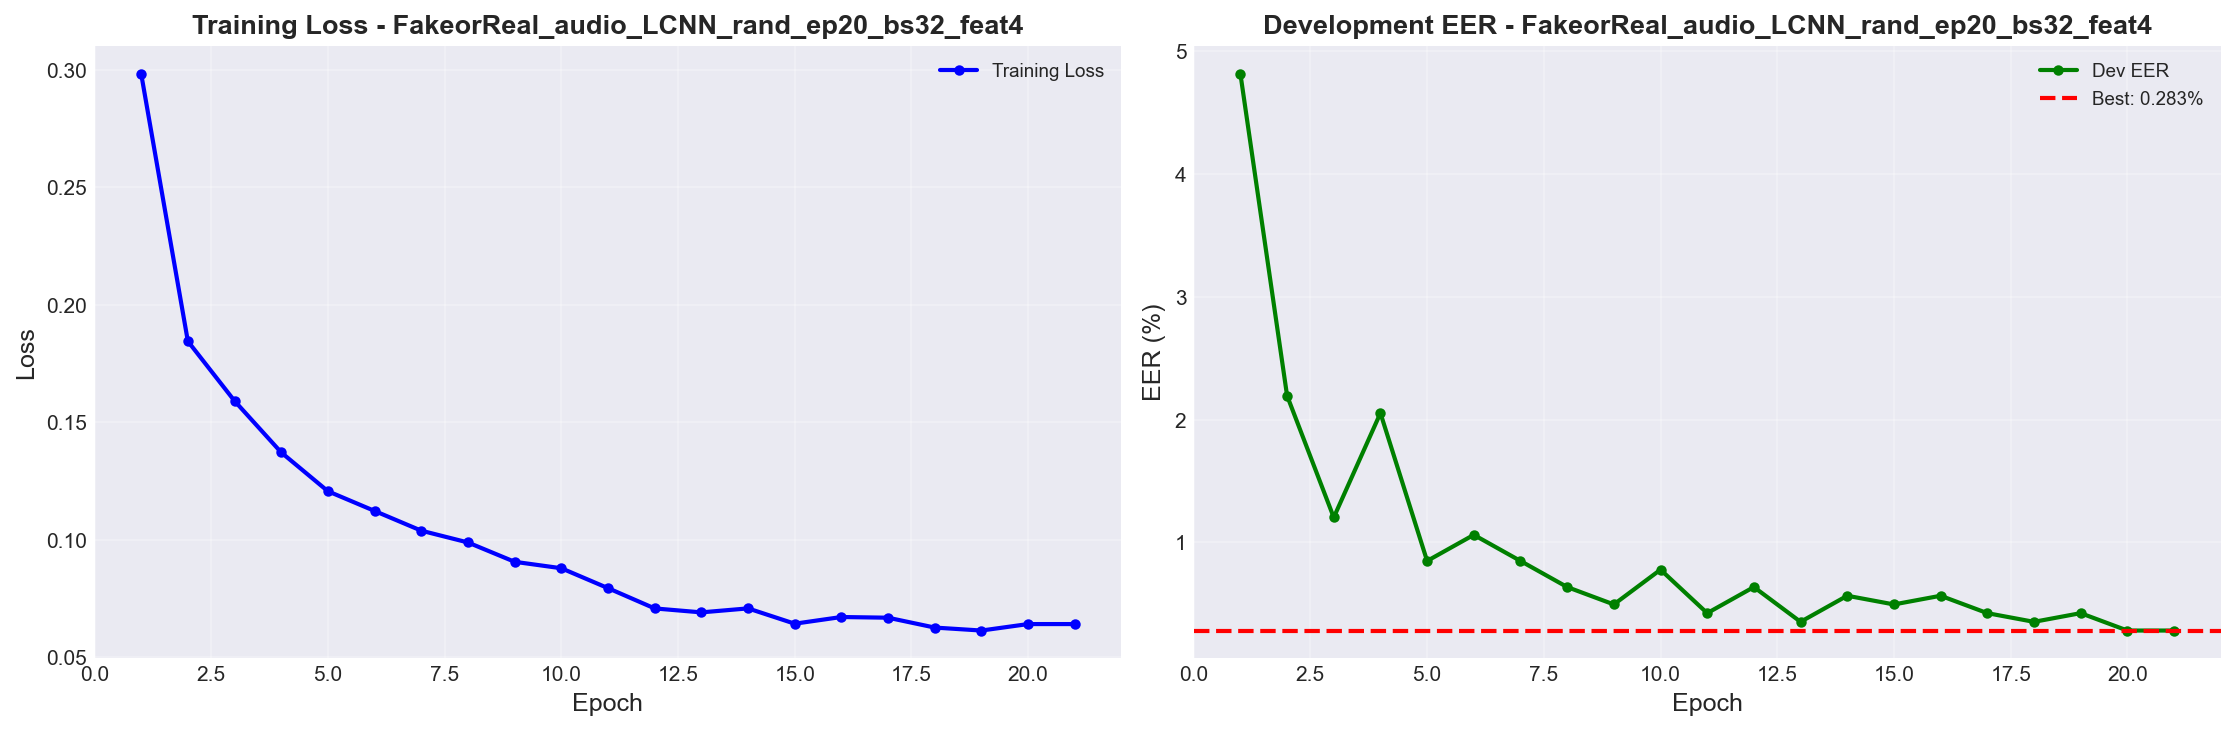

✓ Saved accuracy curves to comparison_plots\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\accuracy_curves.png


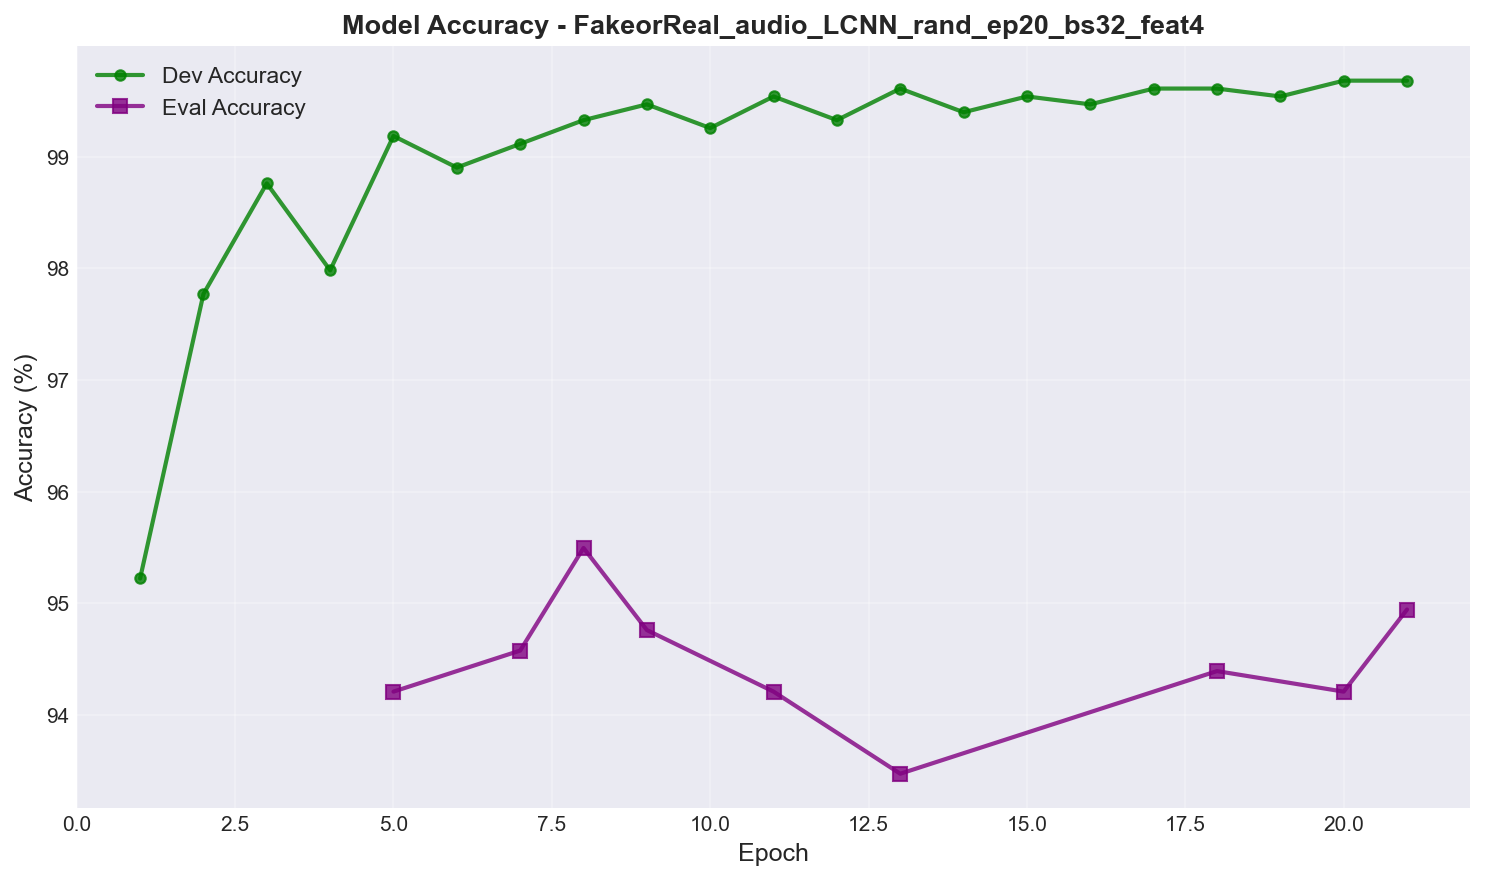

✓ Saved EER comparison to comparison_plots\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\eer_comparison.png


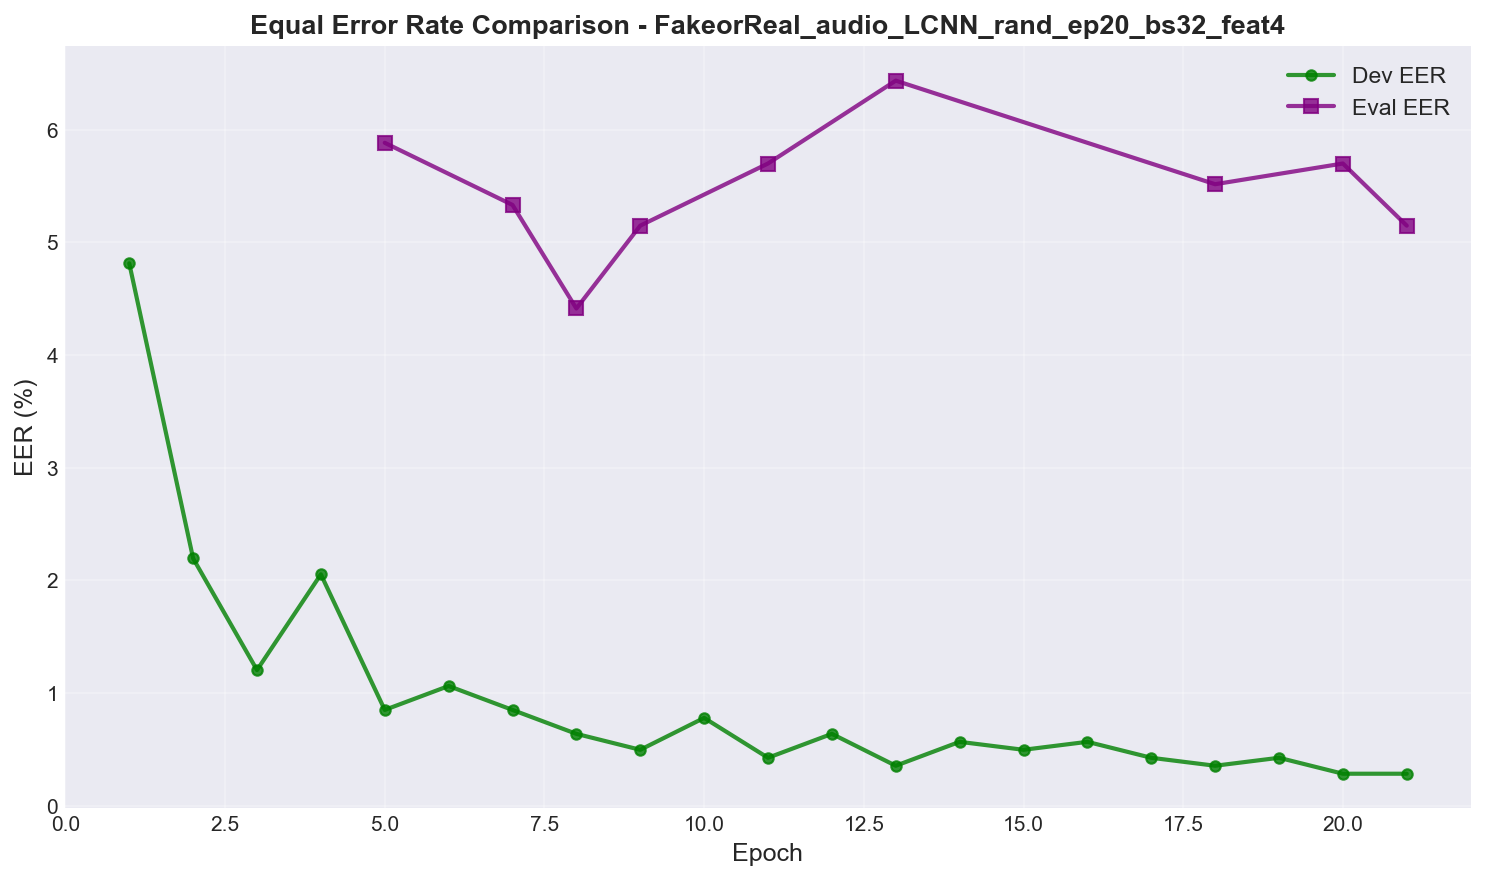

✓ Saved comprehensive metrics to comparison_plots\FakeorReal_audio_LCNN_rand_ep20_bs32_feat4\all_metrics.png


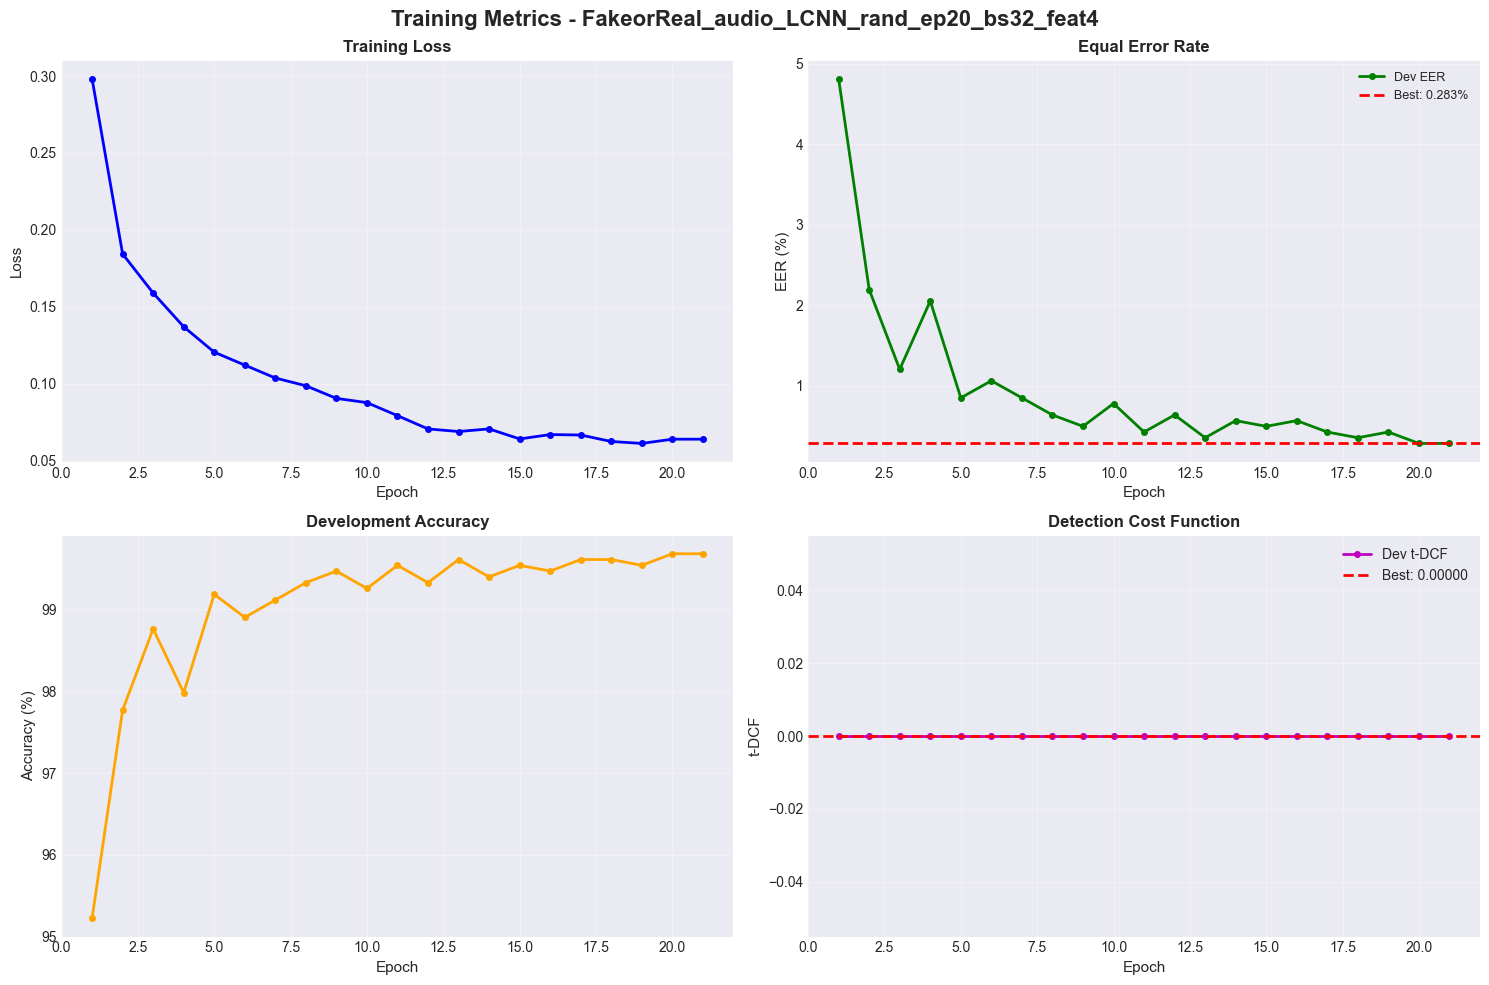


📊 FakeorReal_audio_LCNN_rand_ep20_bs32_feat4 Summary
Total Epochs: 21

Training Loss:
  Initial: 0.29820
  Final:   0.06406
  Min:     0.06130

Development EER:
  Best:    0.2831%
  Final:   0.2831%

Development Accuracy:
  Best:    99.68%
  Final:   99.68%


📈 Generating visualizations for: FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0
✓ Saved training curves to comparison_plots\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\training_curves.png


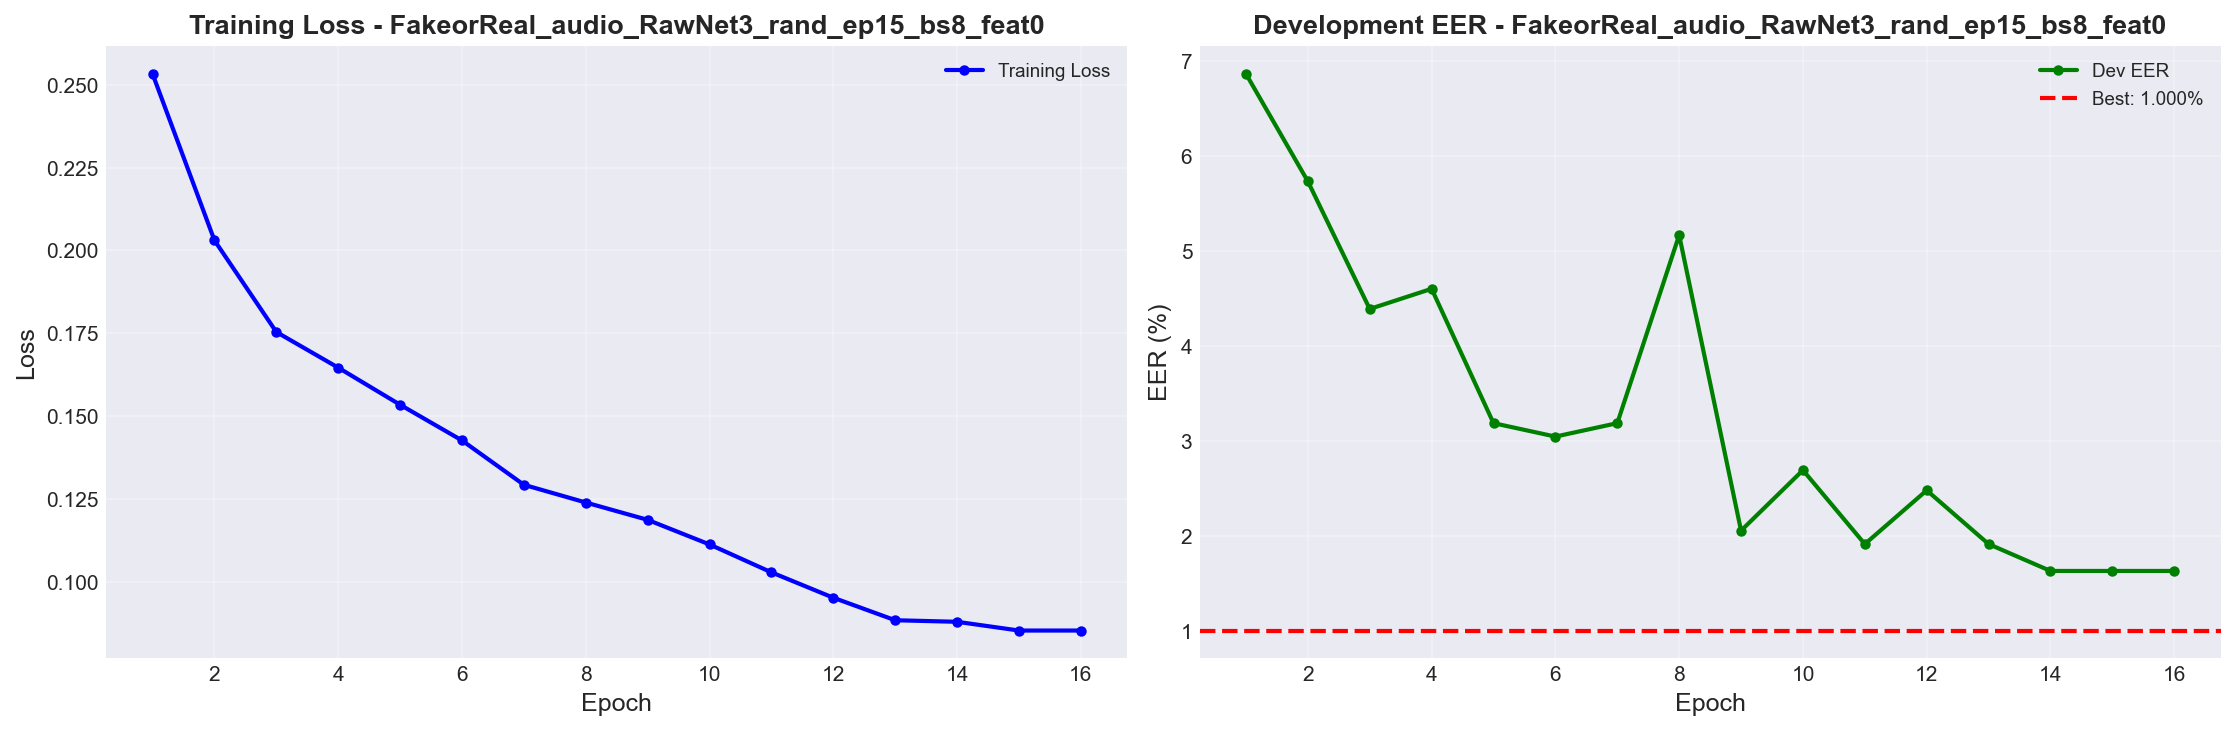

✓ Saved accuracy curves to comparison_plots\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\accuracy_curves.png


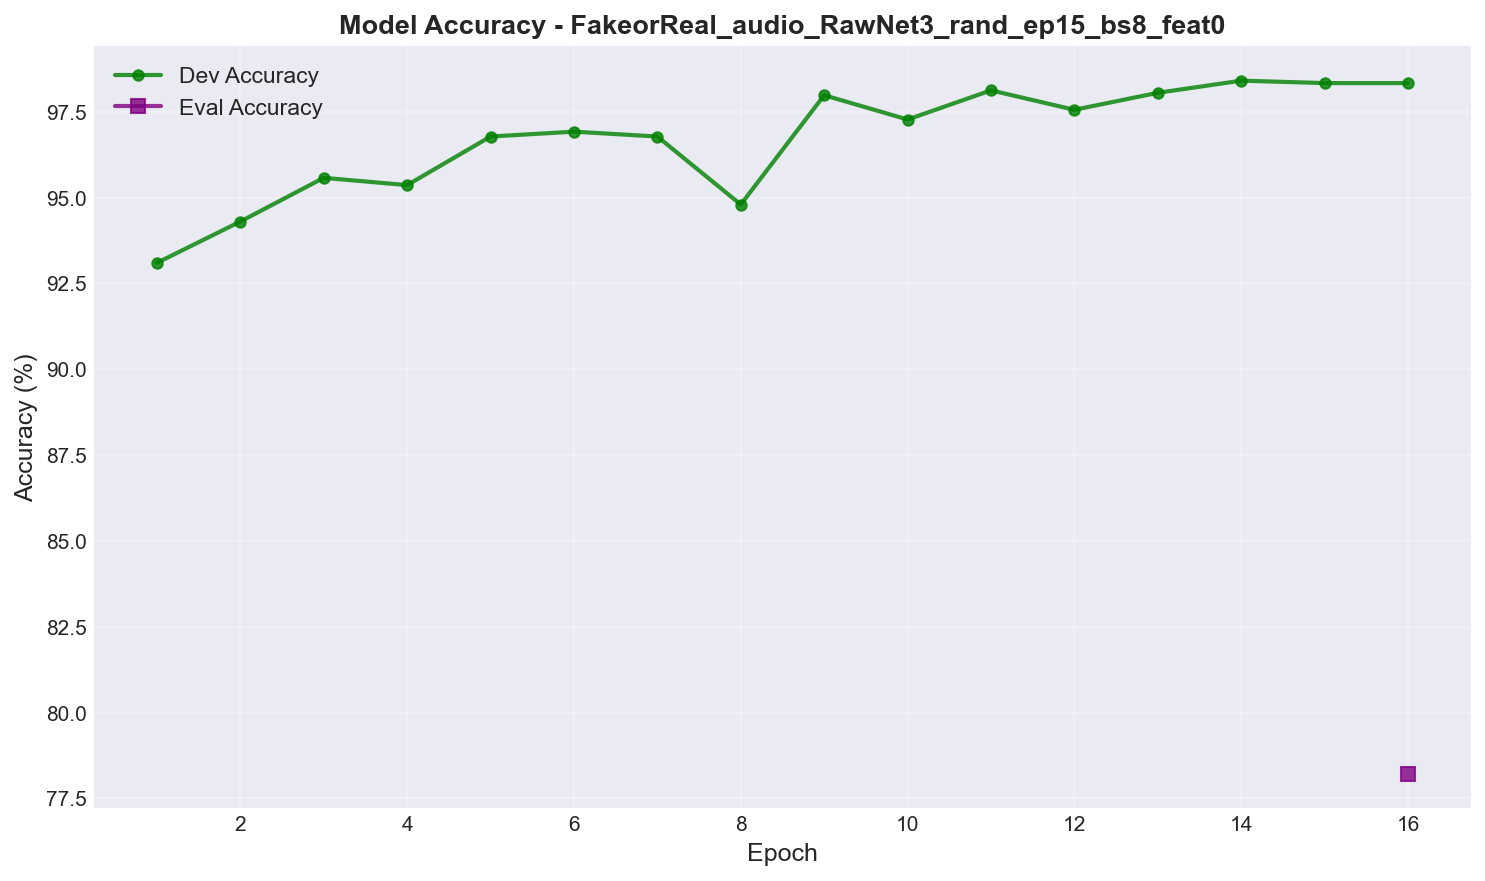

✓ Saved EER comparison to comparison_plots\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\eer_comparison.png


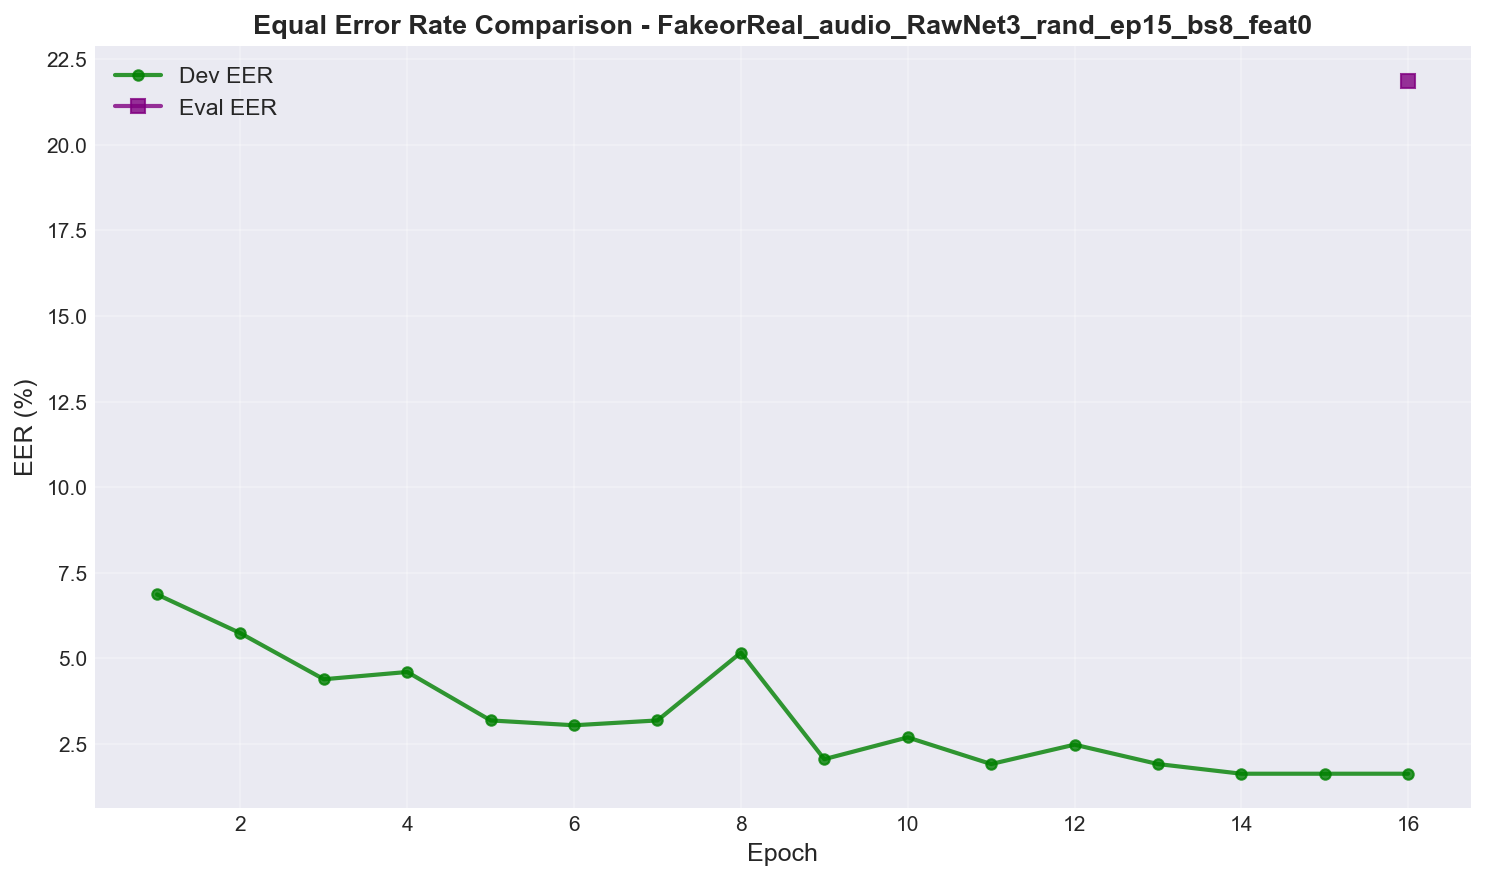

✓ Saved comprehensive metrics to comparison_plots\FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0\all_metrics.png


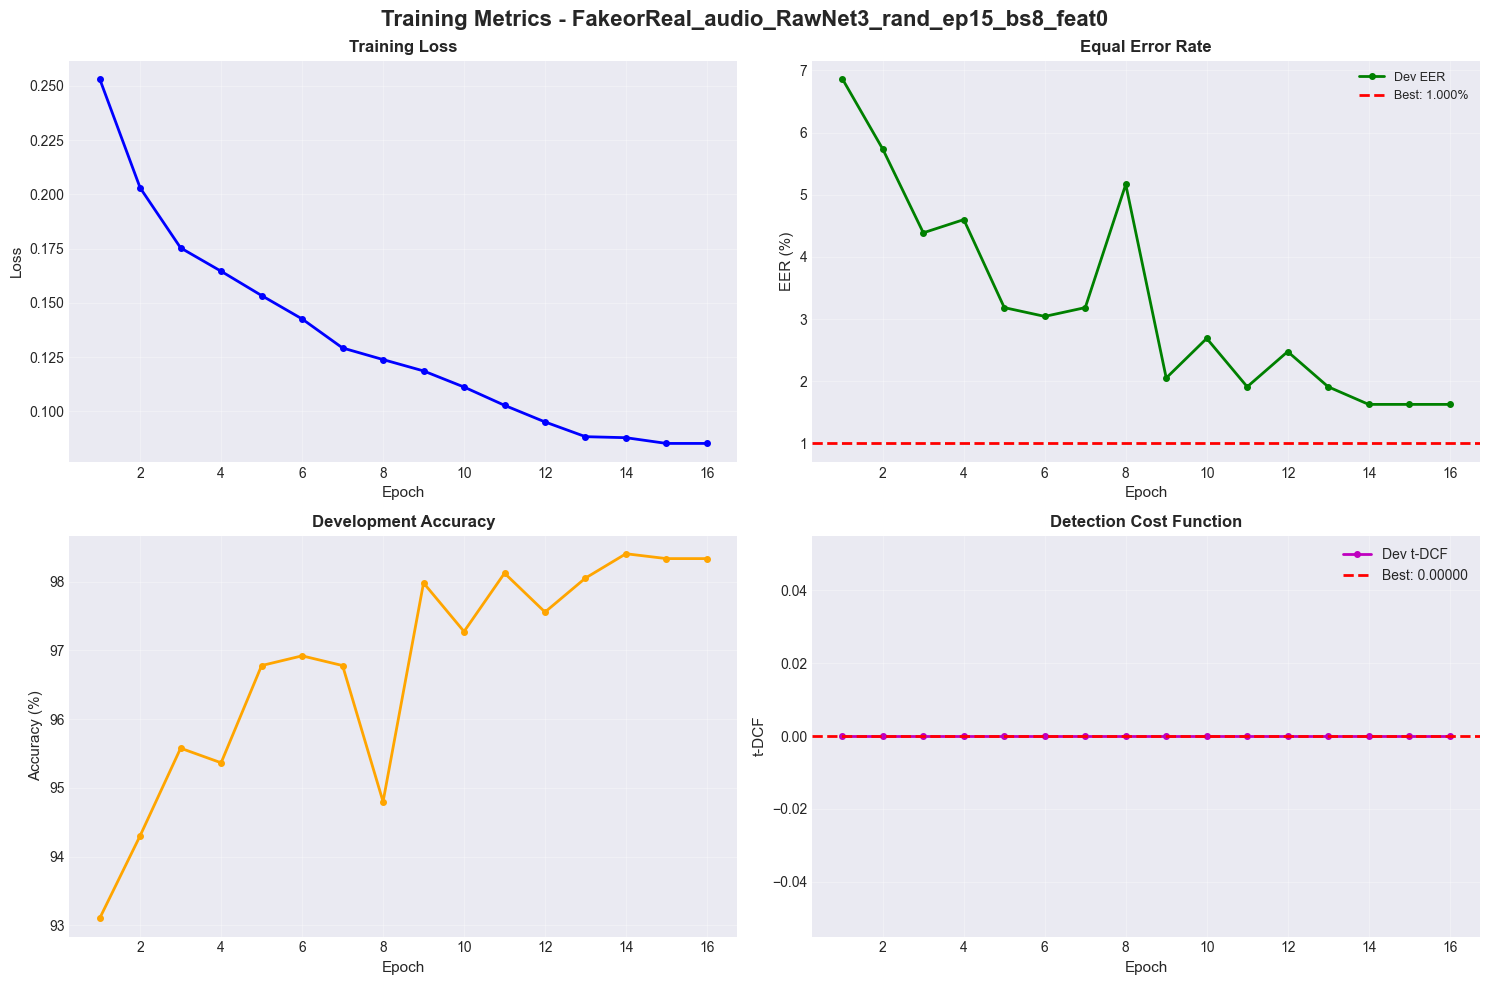


📊 FakeorReal_audio_RawNet3_rand_ep15_bs8_feat0 Summary
Total Epochs: 16

Training Loss:
  Initial: 0.25328
  Final:   0.08528
  Min:     0.08528

Development EER:
  Best:    1.6277%
  Final:   1.6277%

Development Accuracy:
  Best:    98.41%
  Final:   98.34%


📈 Generating visualizations for: FakeorReal_audio_SEResNet_rand_ep15_bs32_feat1


In [ ]:
# Compare all trained models
%run visualize_results.py --path "exp_result/*/metrics" --compare --show-summary --output ./comparison_plots

### Display Comparison Plots


In [ ]:
from IPython.display import Image, display
from pathlib import Path

# Display comparison plot if it exists
comparison_plot = Path("./comparison_plots/model_comparison.png")
if comparison_plot.exists():
    display(Image(filename=str(comparison_plot)))
else:
    print("Run the comparison command above first to generate plots.")


DATASET: Fake-or-Real (Type 2, Version 3)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: 1 (MEL_SPECTROGRAM)
Generating feature analysis visualization...
Using sample: file1657.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: Tesla T4 (Compute Capability: 7.5)
BF16 Native Support: False
  → Using FP16 mixed precision (BF16 requires Ampere+ GPU)
TF32 Enabled: True
CuDNN Benchmark: Enabled
no. params (model[0] LCNN): 444835
no. params (model[1] SEResNet): 22159555
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 179MB/s]


no. params (model[2] EfficientNetB2): 10865581
Ensemble created with 3 models, total params: 36719635
Memory Format: contiguous (channels_last disabled for GPU compatibility)

TRAINING CONFIGURATION SUMMARY
  Model:            Ensemble([0]LCNN, [1]SEResNet, [2]EfficientNetB2)
  Dataset:          Fake-or-Real (Type 2)
  Feature:          mel_spectrogram (Type 1)
  Augmentation:     ✅ ENABLED
  Weight Avg (SWA): ✅ ENABLED
  Epochs:           20
  Batch Size:       32


Dataset loaded from: fake_or_real/for-2sec/for-2seconds
Training samples: 13956 (Real: 6978, Fake: 6978)
Validation samples: 2826 (Real: 1413, Fake: 1413)
Testing samples: 1088 (Real: 544, Fake: 544)


Start training epoch 1/20


Training: 100%|██████████| 436/436 [06:57<00:00,  1.04batch/s, loss=0.23621]



Validating on development set...


...

Evaluation: 100%|██████████| 34/34 [00:11<00:00,  2.87batch/s]


Scores saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/eval_scores_using_best_dev_model.txt
epoch020, 
Saving epoch 20 for SWA (weight averaging - best model)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 18 model snapshots


Evaluation: 100%|██████████| 34/34 [00:11<00:00,  2.85batch/s]


Scores saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/eval_scores_using_best_dev_model.txt
[OK] SWA weights saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/weights/swa.pth (n_snapshots=18)

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/metrics/metrics.json
[OK] Metrics CSV saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/metrics/metrics.csv
[OK] Training metrics plot saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/metrics/training_metrics.png
[OK] Final metrics plot saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/metrics/final_metrics.png
[OK] Metrics summary saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/metrics/metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZATIONS

[INFO] Collecting predictions for visualization...

[INFO] Development Set:


[INFO] Dev EER threshold: -1.4270

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/metrics/confusion_matrix_dev.png


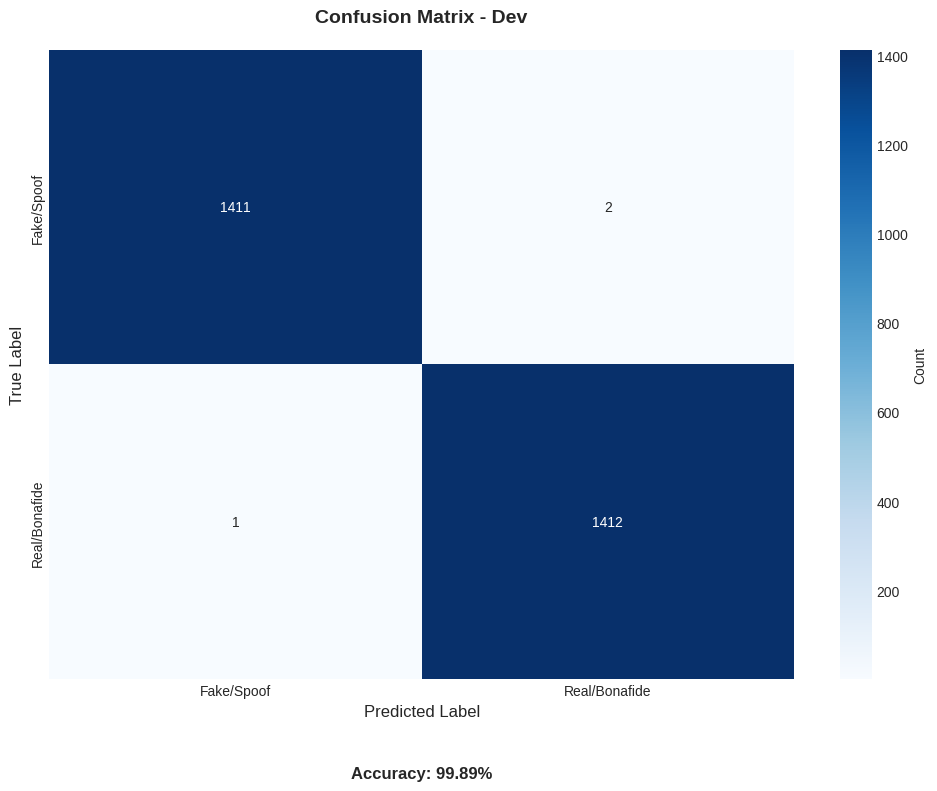

✓ ROC curve saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/metrics/roc_curve_dev.png


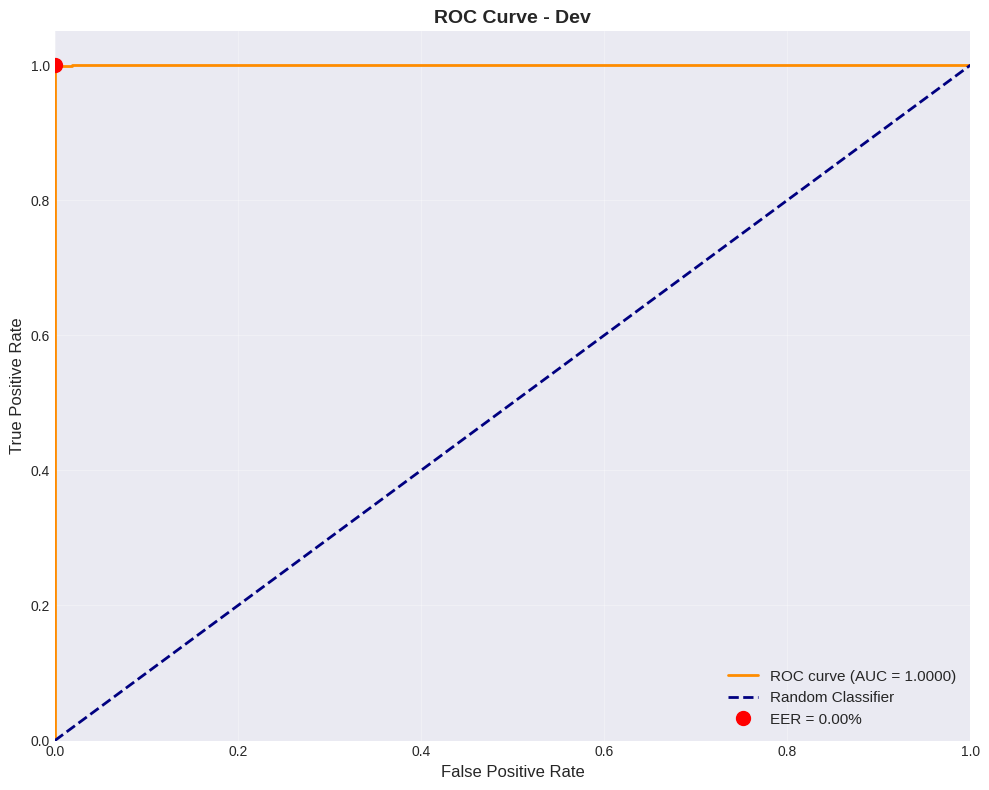


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9993    0.9986    0.9989      1413
Real/Bonafide     0.9986    0.9993    0.9989      1413

     accuracy                         0.9989      2826
    macro avg     0.9989    0.9989    0.9989      2826
 weighted avg     0.9989    0.9989    0.9989      2826

✓ Classification report saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/metrics/classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 99.89%  |  ROC AUC: 1.0000  |  EER: 0.00%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1411            2
    Actual Real/Bonafide            1         1412

---------------------------------------------------

[INFO] Eval EER threshold: 3.3161

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/metrics/confusion_matrix_eval.png


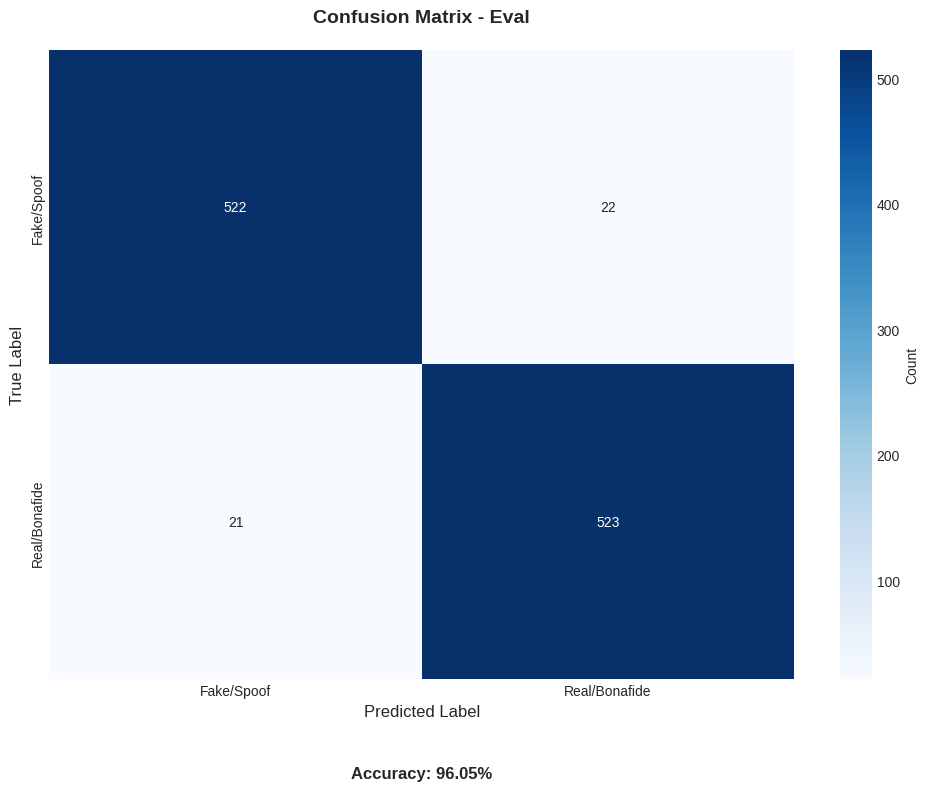

✓ ROC curve saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/metrics/roc_curve_eval.png


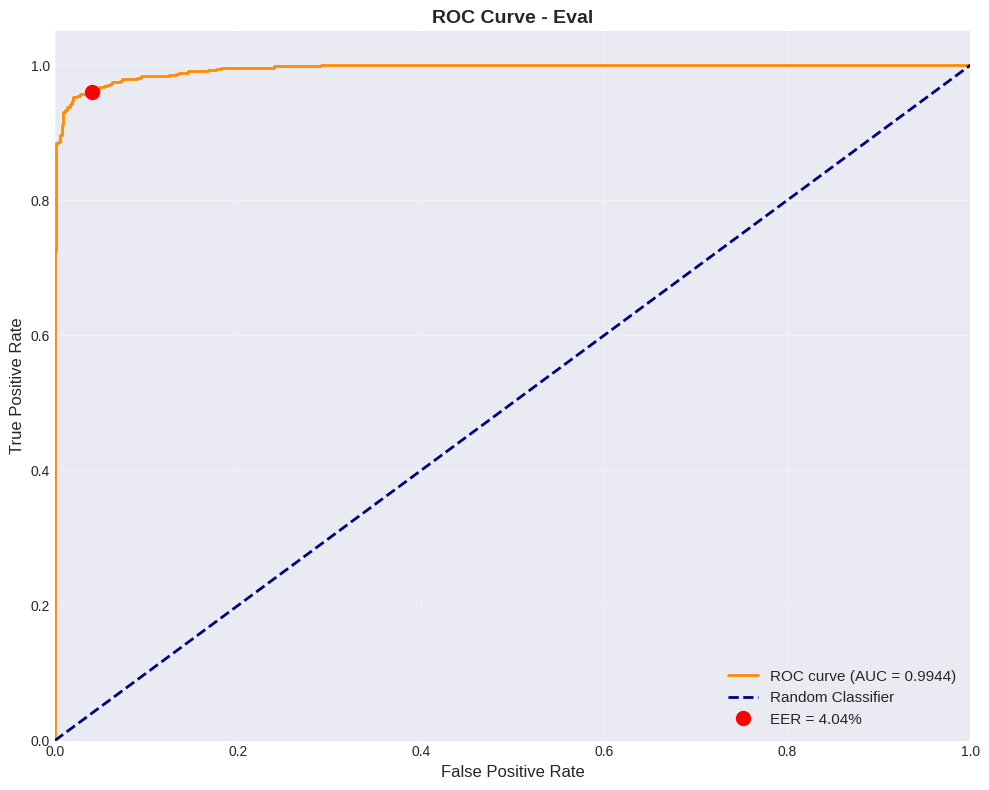


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9613    0.9596    0.9604       544
Real/Bonafide     0.9596    0.9614    0.9605       544

     accuracy                         0.9605      1088
    macro avg     0.9605    0.9605    0.9605      1088
 weighted avg     0.9605    0.9605    0.9605      1088

✓ Classification report saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/metrics/classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 96.05%  |  ROC AUC: 0.9944  |  EER: 4.04%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          522           22
    Actual Real/Bonafide           21          523

-------------------------------------------------

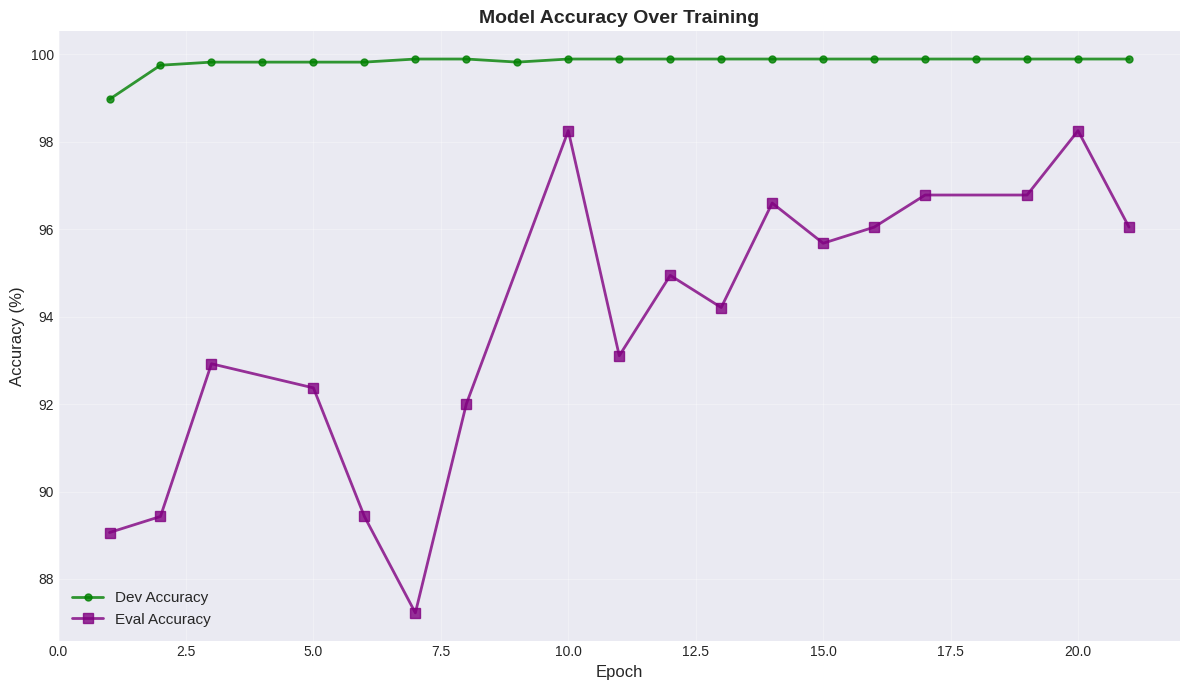


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.23621
  Final Loss:   0.01369
  Min Loss:     0.01369

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     0.0708%
  Best Dev Accuracy: 99.89%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       4.0441%
  ROC AUC:   0.9944
  Accuracy:  96.05%


[OK] Final summary saved to exp_result/FakeorReal_V3_audio_ensemble_rand_ep20_bs32_feat1/metrics/final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 1.838, Accuracy: 96.05%


<Figure size 640x480 with 0 Axes>

In [4]:
%run    main.py --config config/ensemble.conf --feature_type 1 --dataset 2 --epochs 20 --random_noise --weight_avg --eval_best  --dataset_version  3


DATASET: Fake-or-Real (Type 2, Version 3)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: [1, 2, 4] (MULTIMODAL_1,2,4)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
CuDNN Benchmark: Enabled
no. model params:10865581
ℹ️  Multimodal feature_type detected ([1, 2, 4]) → using 3 modalities; applying fusion wrapper
  Modalities: 1=mel_spectrogram, 2=lfcc, 4=cqt
Memory Format: channels_last (optimized for CNNs)

TRAINING CONFIGURATION SUMMARY
  Model:            EfficientNetB2
  Dataset:          Fake-or-Real (Type 2)
  Feature:          multimodal_1,2,4 (Type 1,

Training: 100%|█████████████| 581/581 [15:45<00:00,  1.63s/batch, loss=0.39901]



Validating on development set...


Evaluation: 100%|█████████████████████████| 118/118 [03:03<00:00,  1.56s/batch]


Scores saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\metrics\dev_score.txt
DONE.
Loss:0.39901, dev_eer: 1.982, dev_acc: 97.98%
best model find at epoch 1


...

Evaluation: 100%|██████████████████████████████████████████████| 46/46 [00:35<00:00,  1.28batch/s]


Scores saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\eval_scores_using_best_dev_model.txt
epoch020, 
Saving epoch 20 for SWA (weight averaging - best model)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 19 model snapshots


Evaluation: 100%|██████████████████████████████████████████████| 46/46 [00:35<00:00,  1.28batch/s]


Scores saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\eval_scores_using_best_dev_model.txt
[OK] SWA weights saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\weights\swa.pth (n_snapshots=19)

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\metrics\metrics

[INFO] Dev EER threshold: -0.6891

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\metrics\confusion_matrix_dev.png


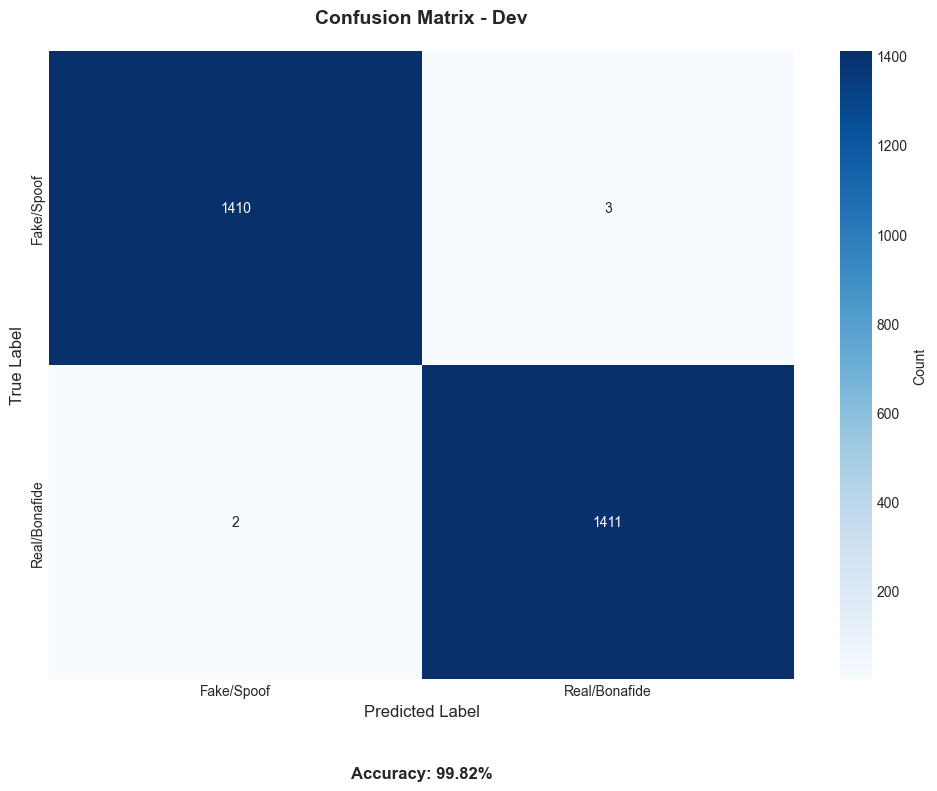

✓ ROC curve saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\metrics\roc_curve_dev.png


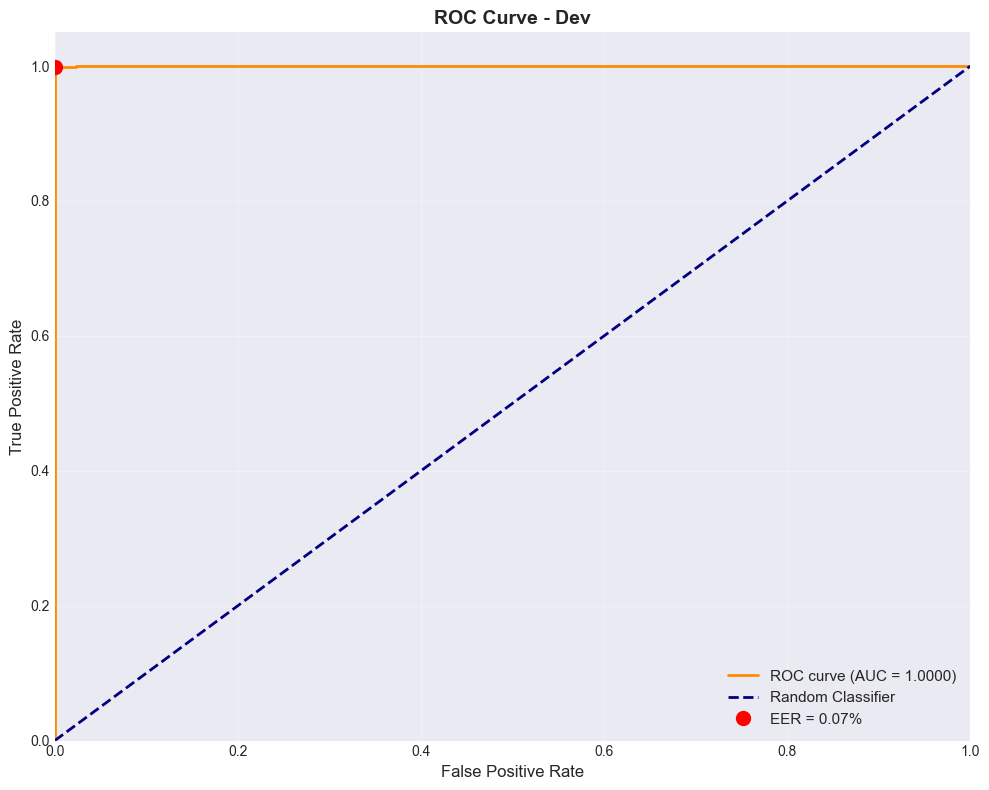


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9986    0.9979    0.9982      1413
Real/Bonafide     0.9979    0.9986    0.9982      1413

     accuracy                         0.9982      2826
    macro avg     0.9982    0.9982    0.9982      2826
 weighted avg     0.9982    0.9982    0.9982      2826

✓ Classification report saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 99.82%  |  ROC AUC: 1.0000  |  EER: 0.07%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1410            3
    Actual Real/Bonafide            2         1411

---------------------------

[INFO] Eval EER threshold: 4.1287

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\metrics\confusion_matrix_eval.png


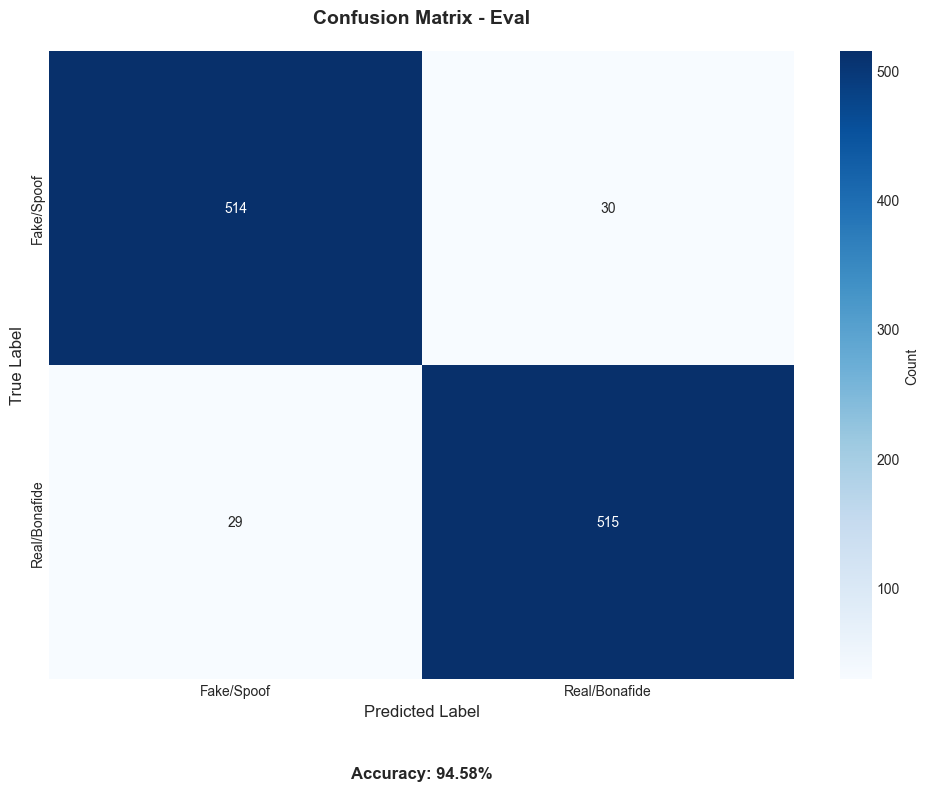

✓ ROC curve saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\metrics\roc_curve_eval.png


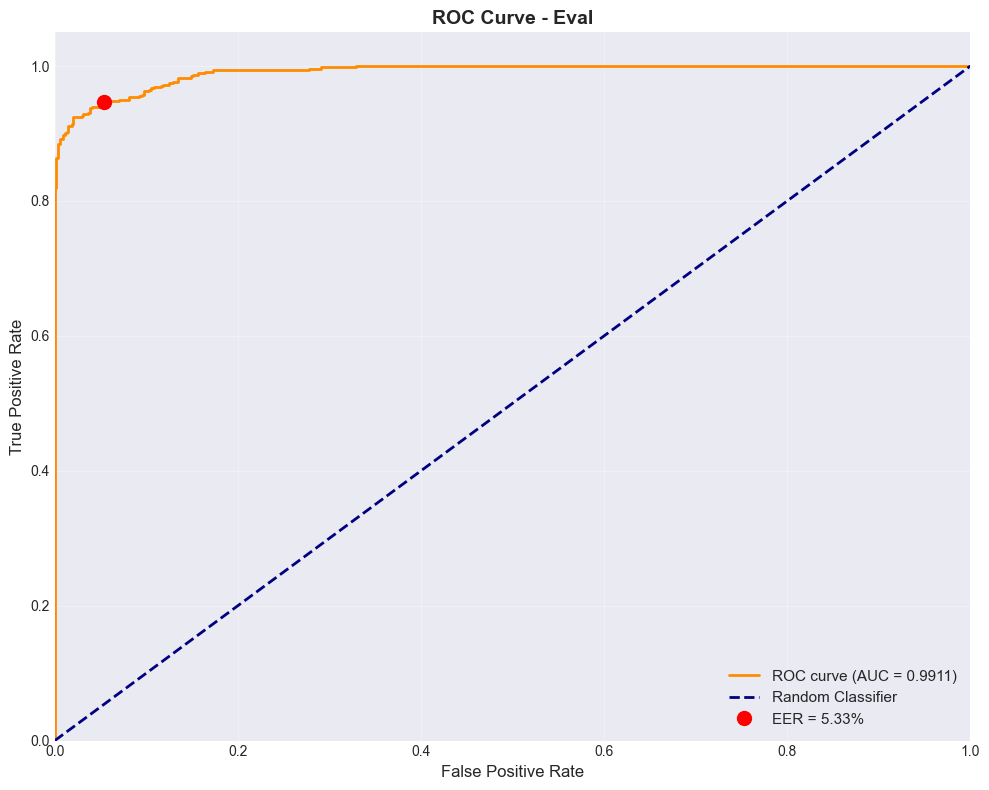


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9466    0.9449    0.9457       544
Real/Bonafide     0.9450    0.9467    0.9458       544

     accuracy                         0.9458      1088
    macro avg     0.9458    0.9458    0.9458      1088
 weighted avg     0.9458    0.9458    0.9458      1088

✓ Classification report saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 94.58%  |  ROC AUC: 0.9911  |  EER: 5.33%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          514           30
    Actual Real/Bonafide           29          515

-------------------------

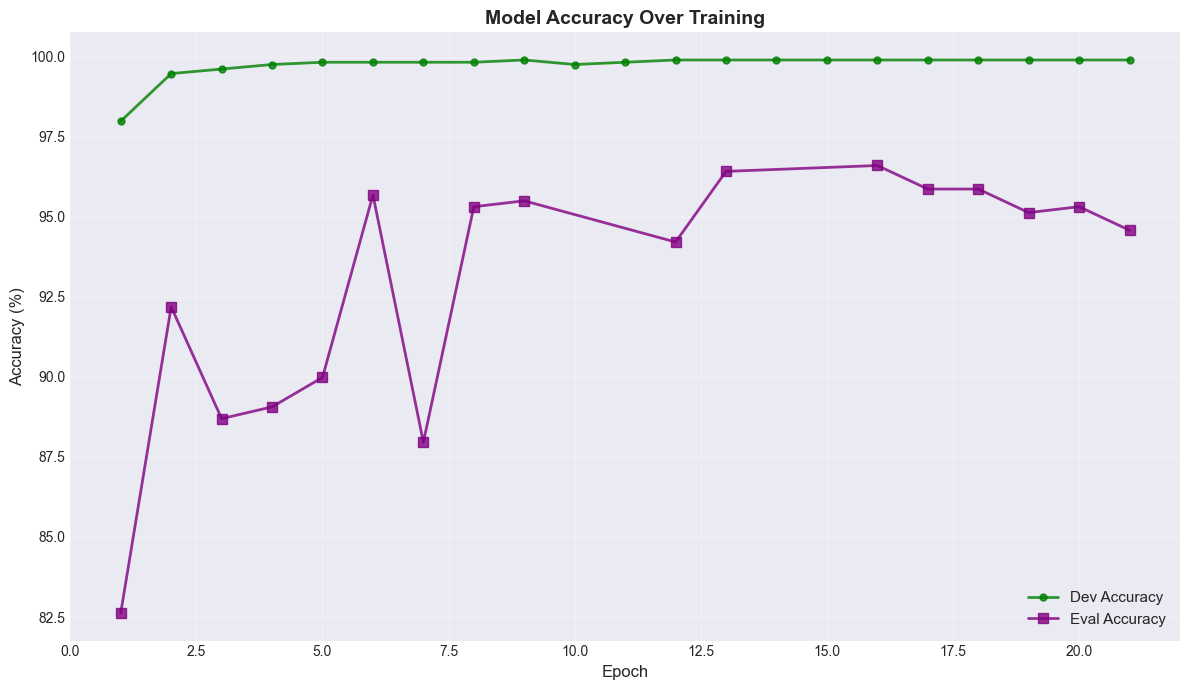


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.39901
  Final Loss:   0.02598
  Min Loss:     0.02547

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     0.0708%
  Best Dev Accuracy: 99.89%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       5.3309%
  ROC AUC:   0.9911
  Accuracy:  94.58%


[OK] Final summary saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_Attention_rand_ep20_bs24_feat[1, 2, 4]\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 3.309, Accuracy: 94.58%


<Figure size 640x480 with 0 Axes>

In [5]:
%run  main.py --config config/EfficientNetB2_Attention.conf --feature_type 1,2,4 --dataset 2 --epochs 20 --random_noise --weight_avg --eval_best  --dataset_version 3  


DATASET: Fake-or-Real (Type 2, Version 3)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: [1, 2, 4] (MULTIMODAL_1,2,4)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
CuDNN Benchmark: Enabled
no. model params:8555204
ℹ️  Multimodal feature_type detected ([1, 2, 4]) → using 3 modalities; applying fusion wrapper
  Modalities: 1=mel_spectrogram, 2=lfcc, 4=cqt
Memory Format: channels_last (optimized for CNNs)

TRAINING CONFIGURATION SUMMARY
  Model:            EfficientNetB2
  Dataset:          Fake-or-Real (Type 2)
  Feature:          multimodal_1,2,4 (Type 1,2

Training: 100%|████████████████████████████████| 436/436 [08:21<00:00,  1.15s/batch, loss=0.32146]



Validating on development set...


Evaluation: 100%|██████████████████████████████████████████████| 89/89 [01:31<00:00,  1.03s/batch]


Scores saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\metrics\dev_score.txt
DONE.
Loss:0.32146, dev_eer: 4.883, dev_acc: 95.15%
best model find at epoch 1


...

Evaluation: 100%|██████████████████████████████████████████████| 34/34 [00:27<00:00,  1.26batch/s]


Scores saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\eval_scores_using_best_dev_model.txt
epoch020, best eer, 4.7794%
Saving epoch 20 for SWA (weight averaging - best model)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 17 model snapshots


Evaluation: 100%|██████████████████████████████████████████████| 34/34 [00:27<00:00,  1.26batch/s]


Scores saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\eval_scores_using_best_dev_model.txt
[OK] SWA weights saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\weights\swa.pth (n_snapshots=17)

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\metrics\metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZAT

[INFO] Dev EER threshold: -0.3572

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\metrics\confusion_matrix_dev.png


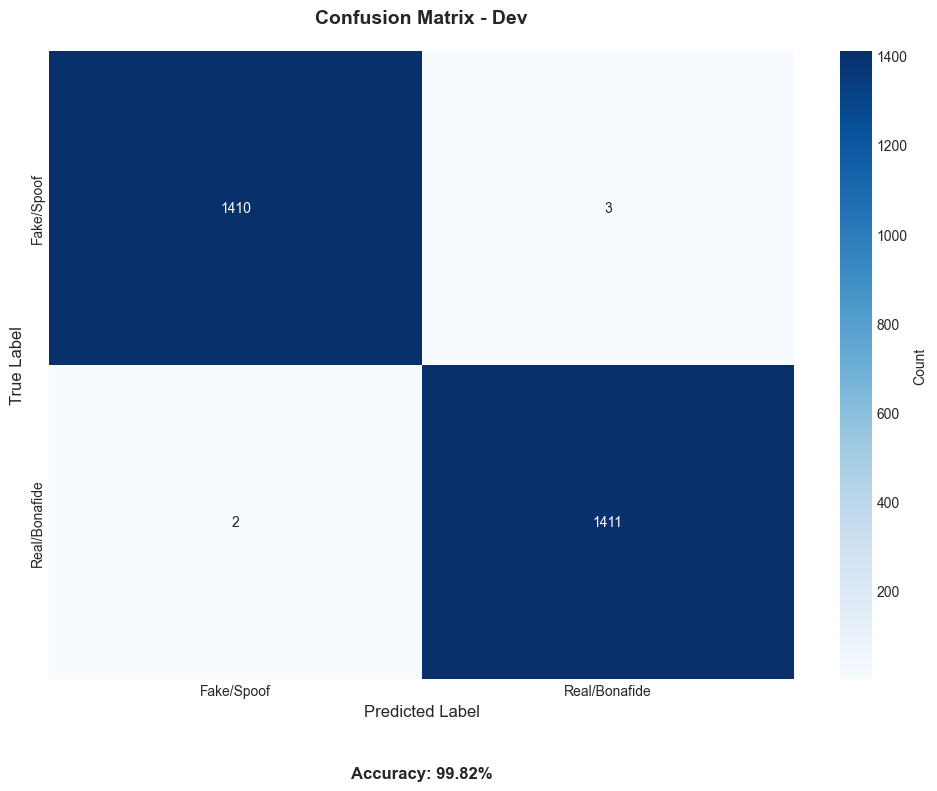

✓ ROC curve saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\metrics\roc_curve_dev.png


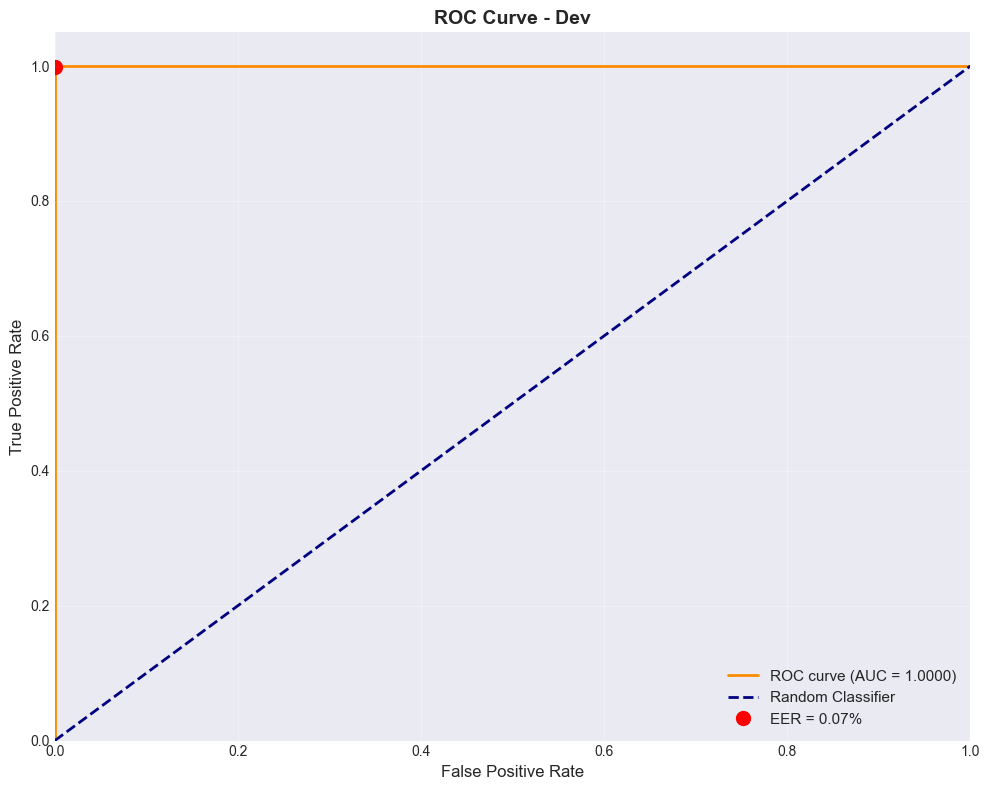


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9986    0.9979    0.9982      1413
Real/Bonafide     0.9979    0.9986    0.9982      1413

     accuracy                         0.9982      2826
    macro avg     0.9982    0.9982    0.9982      2826
 weighted avg     0.9982    0.9982    0.9982      2826

✓ Classification report saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 99.82%  |  ROC AUC: 1.0000  |  EER: 0.07%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1410            3
    Actual Real/Bonafide            2         1411

-------------------------------------

[INFO] Eval EER threshold: 2.8499

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\metrics\confusion_matrix_eval.png


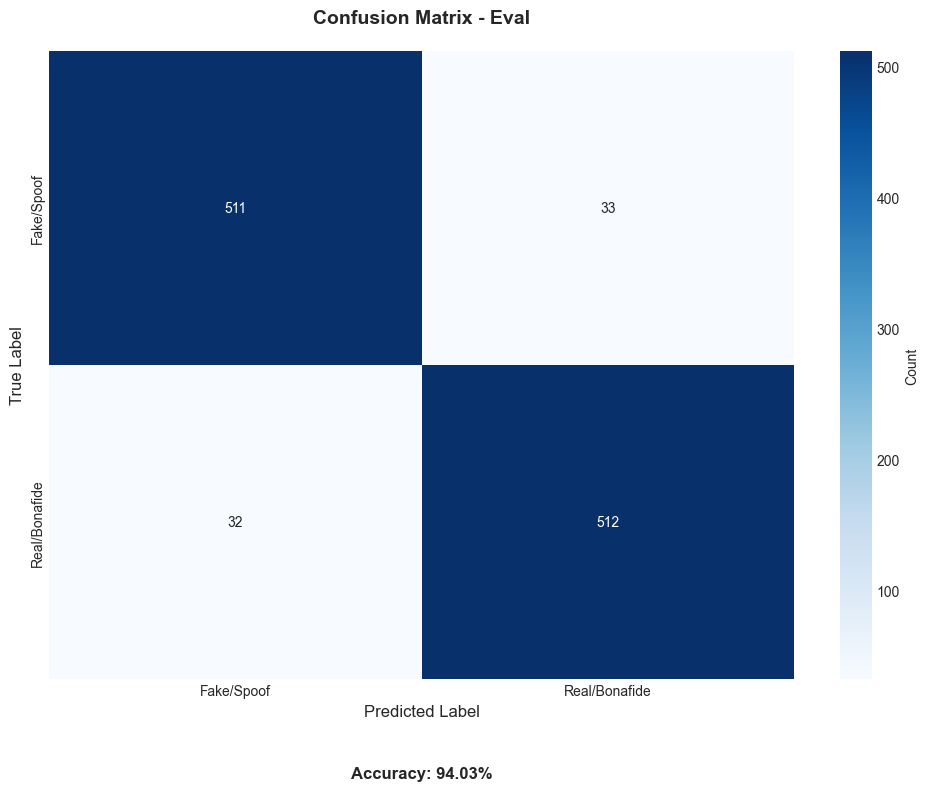

✓ ROC curve saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\metrics\roc_curve_eval.png


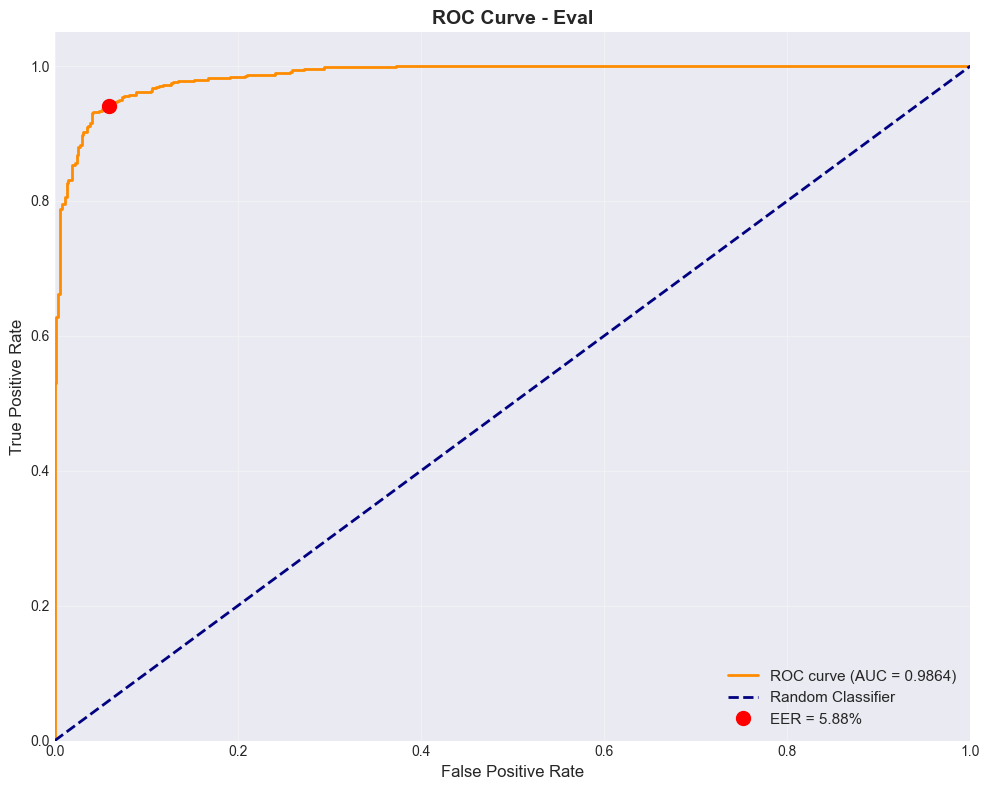


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9411    0.9393    0.9402       544
Real/Bonafide     0.9394    0.9412    0.9403       544

     accuracy                         0.9403      1088
    macro avg     0.9403    0.9403    0.9403      1088
 weighted avg     0.9403    0.9403    0.9403      1088

✓ Classification report saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 94.03%  |  ROC AUC: 0.9864  |  EER: 5.88%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          511           33
    Actual Real/Bonafide           32          512

-----------------------------------

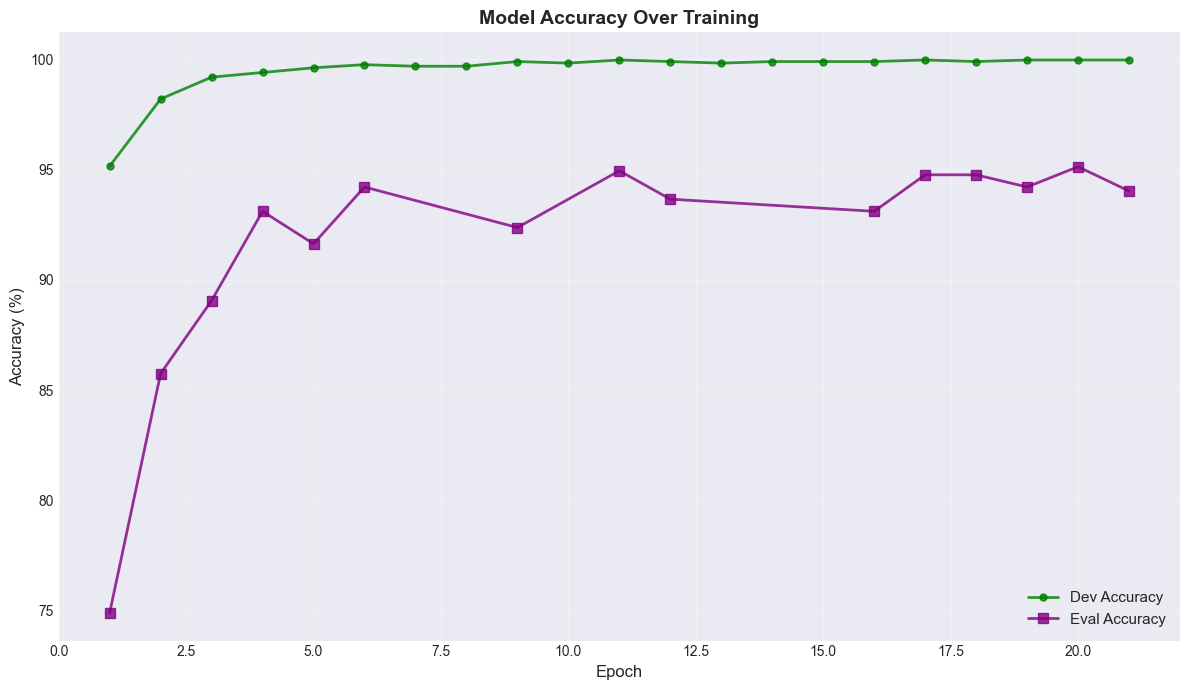


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.32146
  Final Loss:   0.02934
  Min Loss:     0.02934

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     0.0708%
  Best Dev Accuracy: 99.96%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       5.8824%
  ROC AUC:   0.9864
  Accuracy:  94.03%


[OK] Final summary saved to exp_result\FakeorReal_V3_audio_EfficientNetB2_rand_ep20_bs32_feat[1, 2, 4]\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 4.779, Accuracy: 94.03%


<Figure size 640x480 with 0 Axes>

In [6]:
%run  main.py --config config/EfficientNetB2.conf --feature_type 1,2,4 --dataset 2 --epochs 20 --random_noise --weight_avg --eval_best  --dataset_version 3  


DATASET: Fake-or-Real (Type 2, Version 3)
✅ Eval on best: ENABLED (will evaluate on test set when best model found)
✅ Random augmentation: ENABLED (RIR, MUSAN-style noise, pitch shift, time stretch, SpecAugment)
✅ Weight averaging (SWA): ENABLED

Feature Type: [1, 2, 4] (MULTIMODAL_1,2,4)
Generating feature analysis visualization...
Using sample: file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
ℹ️  Feature analysis skipped (use --feature_analysis to enable)
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (Compute Capability: 8.9)
BF16 Native Support: True
TF32 Enabled: True
CuDNN Benchmark: Enabled
no. model params:11981251
ℹ️  Multimodal feature_type detected ([1, 2, 4]) → using 3 modalities; applying fusion wrapper
  Modalities: 1=mel_spectrogram, 2=lfcc, 4=cqt
Memory Format: channels_last (optimized for CNNs)

TRAINING CONFIGURATION SUMMARY
  Model:            SEResNet
  Dataset:          Fake-or-Real (Type 2)
  Feature:          multimodal_1,2,4 (Type 1,2,4)
 

Training: 100%|████████████████████████████████| 436/436 [06:12<00:00,  1.17batch/s, loss=0.29360]



Validating on development set...


Evaluation: 100%|██████████████████████████████████████████████| 89/89 [01:11<00:00,  1.24batch/s]


Scores saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\metrics\dev_score.txt
DONE.
Loss:0.29360, dev_eer: 5.874, dev_acc: 94.16%
best model find at epoch 1


...

Evaluation: 100%|██████████████████████████████████████████████| 34/34 [00:35<00:00,  1.04s/batch]


Scores saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\eval_scores_using_best_dev_model.txt
epoch020, 
Saving epoch 20 for SWA (weight averaging - best model)
Start final evaluation
Applying Stochastic Weight Averaging (SWA) - averaging 15 model snapshots


Evaluation: 100%|██████████████████████████████████████████████| 34/34 [00:36<00:00,  1.07s/batch]


Scores saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\eval_scores_using_best_dev_model.txt
[OK] SWA weights saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\weights\swa.pth (n_snapshots=15)

SAVING METRICS AND VISUALIZATIONS
[OK] Metrics saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\metrics\metrics.json
[OK] Metrics CSV saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\metrics\metrics.csv
[OK] Training metrics plot saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\metrics\training_metrics.png
[OK] Final metrics plot saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\metrics\final_metrics.png
[OK] Metrics summary saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\metrics\metrics_summary.txt


                    GENERATING COMPREHENSIVE VISUALIZATIONS

[INFO] Collecting predictions for vi

[INFO] Dev EER threshold: -0.1685

📊 Generating dev visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\metrics\confusion_matrix_dev.png


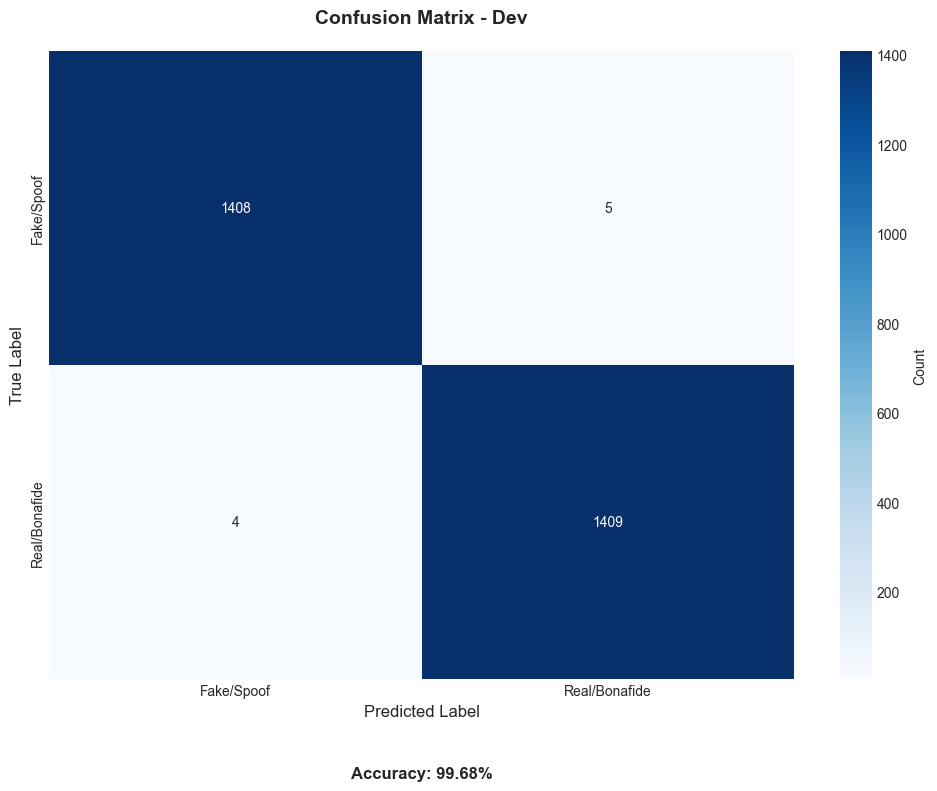

✓ ROC curve saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\metrics\roc_curve_dev.png


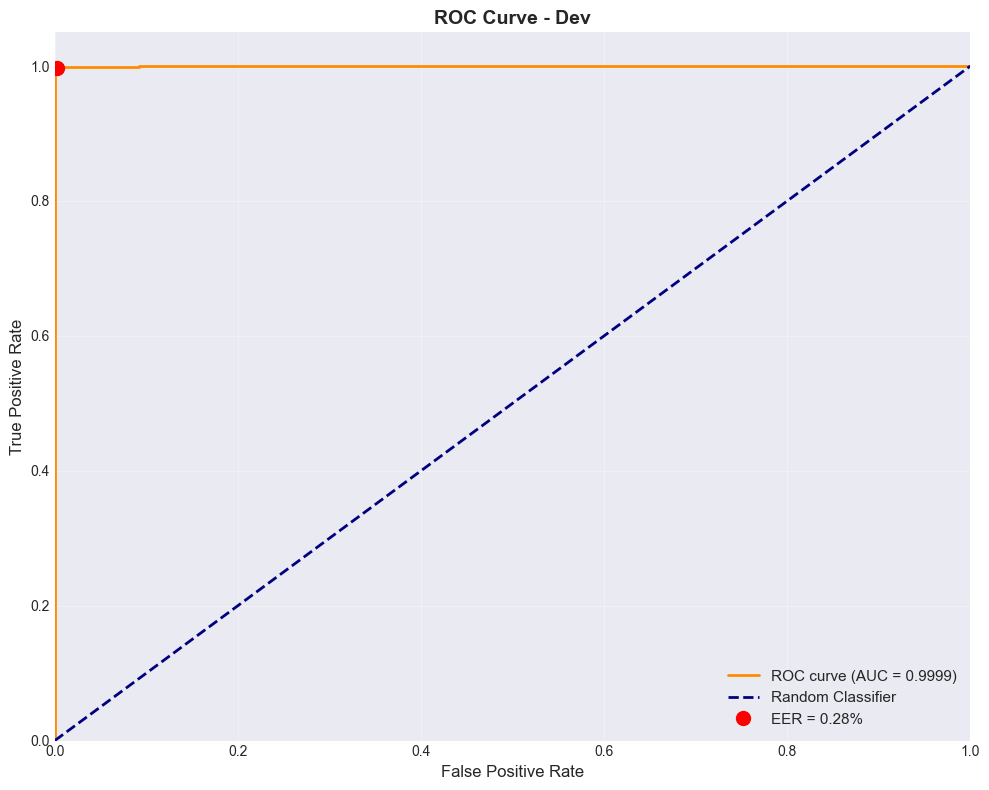


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9972    0.9965    0.9968      1413
Real/Bonafide     0.9965    0.9972    0.9968      1413

     accuracy                         0.9968      2826
    macro avg     0.9968    0.9968    0.9968      2826
 weighted avg     0.9968    0.9968    0.9968      2826

✓ Classification report saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\metrics\classification_report_dev.txt

  DEV SET - CLASSIFICATION METRICS

  Accuracy: 99.68%  |  ROC AUC: 0.9999  |  EER: 0.28%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof         1408            5
    Actual Real/Bonafide            4         1409

-------------------------------------------

[INFO] Eval EER threshold: 2.3115

📊 Generating eval visualizations...
✓ Confusion matrix saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\metrics\confusion_matrix_eval.png


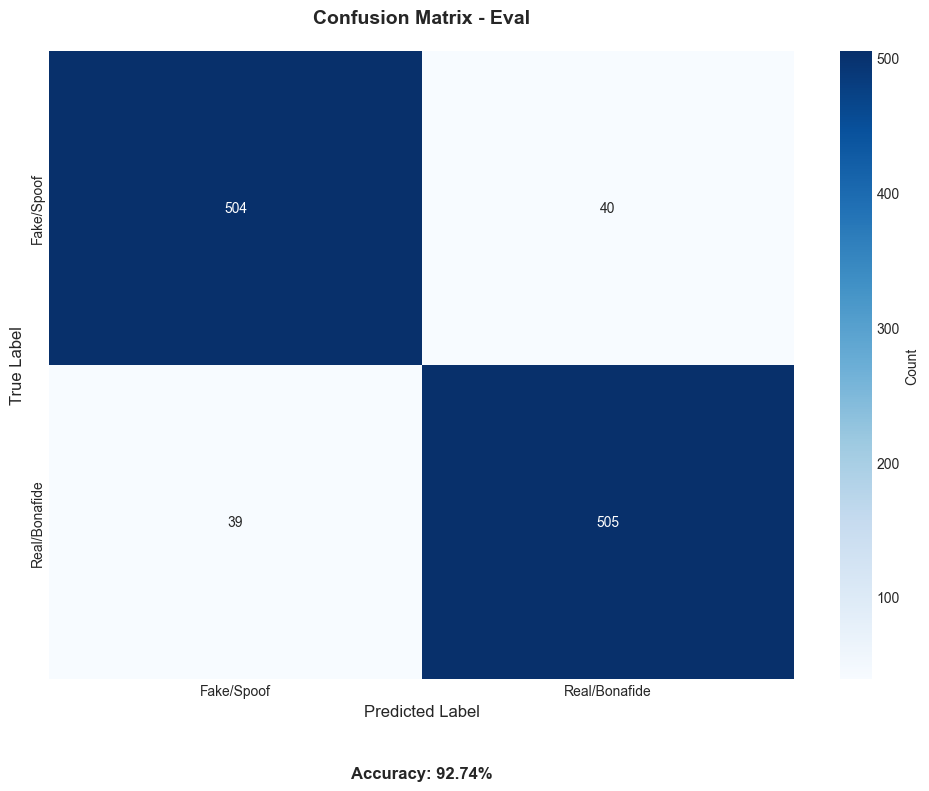

✓ ROC curve saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\metrics\roc_curve_eval.png


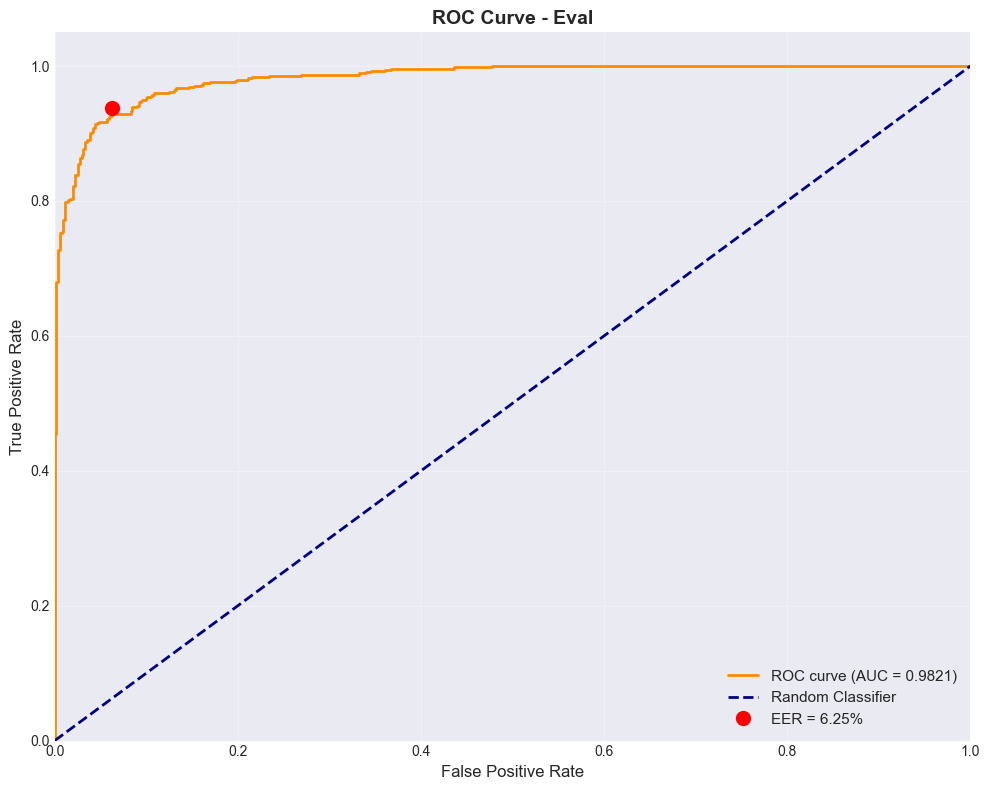


CLASSIFICATION REPORT

               precision    recall  f1-score   support

   Fake/Spoof     0.9282    0.9265    0.9273       544
Real/Bonafide     0.9266    0.9283    0.9275       544

     accuracy                         0.9274      1088
    macro avg     0.9274    0.9274    0.9274      1088
 weighted avg     0.9274    0.9274    0.9274      1088

✓ Classification report saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\metrics\classification_report_eval.txt

  EVAL SET - CLASSIFICATION METRICS

  Accuracy: 92.74%  |  ROC AUC: 0.9821  |  EER: 6.25%

----------------------------------------------------------------------
  CONFUSION MATRIX
----------------------------------------------------------------------

                                 Predicted        
                           Fake/Spoof Real/Bonafide
       Actual Fake/Spoof          504           40
    Actual Real/Bonafide           39          505

-----------------------------------------

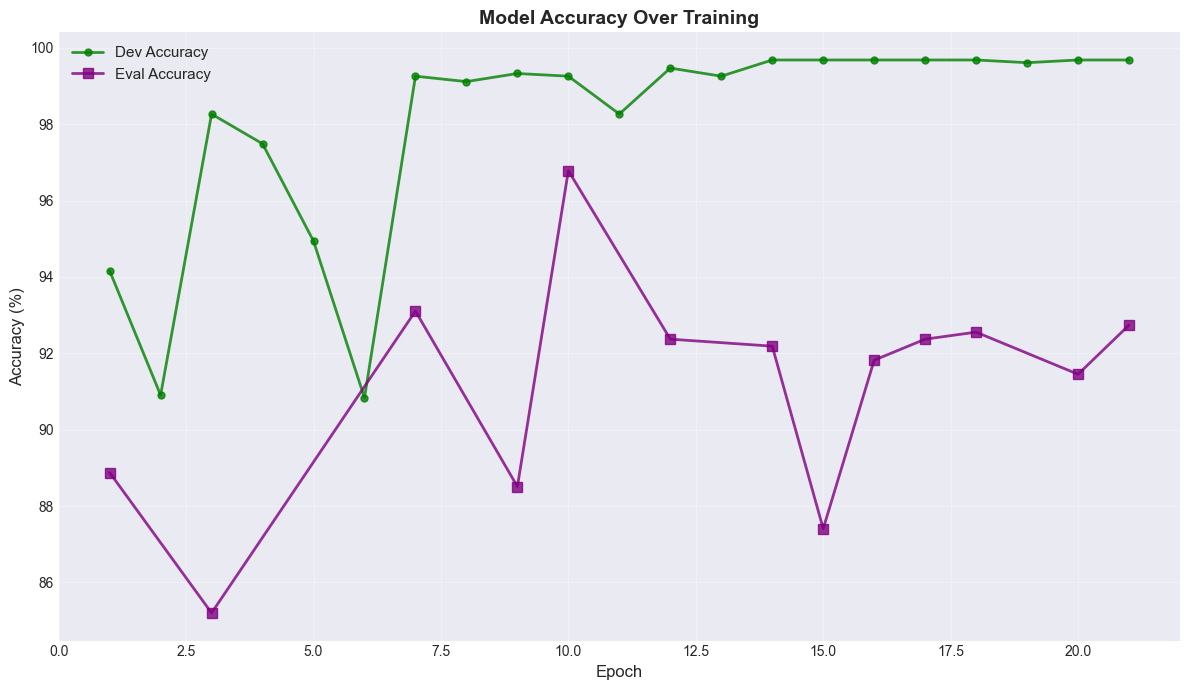


                         FINAL TRAINING SUMMARY

[TRAINING] TRAINING METRICS
--------------------------------------------------------------------------------
  Initial Loss: 0.29360
  Final Loss:   0.03421
  Min Loss:     0.03421

[DEV] DEVELOPMENT SET METRICS
--------------------------------------------------------------------------------
  Best Dev EER:     0.2831%
  Best Dev Accuracy: 99.68%

[EVAL] EVALUATION SET METRICS
--------------------------------------------------------------------------------
  EER:       6.2500%
  ROC AUC:   0.9821
  Accuracy:  92.74%


[OK] Final summary saved to exp_result\FakeorReal_V3_audio_SEResNet_rand_ep20_bs32_feat[1, 2, 4]\metrics\final_summary.txt

[OK] All visualizations generated successfully!

Exp FIN. EER: 3.309, Accuracy: 92.74%


<Figure size 640x480 with 0 Axes>

In [7]:
%run  main.py --config config/SEResNet.conf --feature_type 1,2,4 --dataset 2 --epochs 20 --random_noise --weight_avg --eval_best  --dataset_version 3  

In [6]:
%run explain.py --config config/EfficientNetB2.conf --model_path "exp_result/FakeorReal_audio_EfficientNetB2_ep5_bs32_feat8/weights/swa.pth"  --audio_file "./fake_or_real/for-2sec/for-2seconds/testing/fake/file2.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav" --feature_type 1 --cpu --output_dir explained_outputs

Using device: cpu
Loading weights from: exp_result/FakeorReal_audio_EfficientNetB2_ep5_bs32_feat8/weights/swa.pth

Running XAI Analysis on: file2.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec
Methods: attention, saliency, smoothgrad, integrated_gradients, occlusion, gradcam
Output directory: explained_outputs

[1/6] Running Attention Extraction...
  ⚠ No attention layers found - skipping

[2/6] Running Gradient Saliency...
  ✓ Saved: explained_outputs\file2.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec_saliency.png

[3/6] Running SmoothGrad (this may take a moment)...
  ✓ Saved: explained_outputs\file2.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec_smoothgrad.png

[4/6] Running Integrated Gradients...
  ✓ Saved: explained_outputs\file2.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec_integrated_gradients.png

[5/6] Running Occlusion Sensitivity (this will take a while)...
  Window: (8, 8), Stride: 4
  ✓ Saved: explained_outputs\file2.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec_occlu

E:\workstation\ai-voice-detector\venv\Lib\site-packages\torch\nn\modules\module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


  ✓ Saved: explained_outputs\file2.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec_gradcam.png

✓ XAI Analysis Complete!
Results saved to: explained_outputs



In [ ]:
!streamlit run app.py -- --config ./exp_result/FakeorReal_audio_EfficientNetB2_ep5_bs32_feat8/config.conf --eval_model_weights ./exp_result/FakeorReal_audio_EfficientNetB2_ep5_bs32_feat8/weights/swa.pth

---

## 📊 Experiment Summary Table

After completing all experiments, fill in the results:

| Experiment | Model           | Feature      | Epochs | Best EER (%) | Best Accuracy (%) |
| ---------- | --------------- | ------------ | ------ | ------------ | ----------------- |
| Baseline 1 | LCNN            | Mel-spec (1) | 20     | -            | -                 |
| Baseline 2 | EfficientNet-B2 | Mel-spec (1) | 20     | -            | -                 |
| Baseline 3 | RawNet3         | Raw (0)      | 15     | -            | -                 |
| Exp 1      | LCNN            | CQT (4)      | 20     | -            | -                 |
| Exp 2      | LCNN            | LFCC (2)     | 20     | -            | -                 |
| Exp 3      | EfficientNet-B2 | CQT (4)      | 20     | -            | -                 |
| Exp 4      | SEResNet        | MFCC (3)     | 15     | -            | -                 |
| Exp 6      | SimpleCNN       | Mel-spec (1) | 25     | -            | -                 |
| Exp 7      | LCNN Large      | LFCC (2)     | 20     | -            | -                 |

**Notes:**

- Lower EER is better (0% = perfect)
- Higher Accuracy is better (100% = perfect)
- CQT and LFCC features often work well for spoofing detection
- Raw waveform models (RawNet3, AASIST) learn features automatically
